In [4]:
from pathlib import Path
import pandas as pd

root = Path("data/raw/building59")
ele_path = next(root.rglob("ele.csv"))

df = pd.read_csv(ele_path)

df.head()

,date,mels_S,lig_S,mels_N,hvac_N,hvac_S,Unnamed: 6
0,2018/1/1 1:00,1.2,0.2,7.5,37.400002,19.500000,NaN
1,2018/1/1 1:15,1.3,0.2,6.8,37.500000,19.889999,NaN
2,2018/1/1 1:30,1.1,0.2,7.4,38.000000,19.299999,NaN
3,2018/1/1 1:45,1.2,0.2,7.7,37.200001,18.889999,NaN
4,2018/1/1 2:00,1.1,0.2,7.3,37.400002,24.700001,NaN


In [5]:
df["total_power"] = (
    df["mels_S"]
    + df["lig_S"]
    + df["mels_N"]
    + df["hvac_N"]
    + df["hvac_S"]
)

df[["date", "total_power"]].head()

,date,total_power
0,2018/1/1 1:00,65.800002
1,2018/1/1 1:15,65.690000
2,2018/1/1 1:30,65.999999
3,2018/1/1 1:45,65.190000
4,2018/1/1 2:00,70.700003


Matplotlib is building the font cache; this may take a moment.


<Axes: title={'center': 'Building 59 - İlk Gün Toplam Elektrik Gücü'}, xlabel='date'>

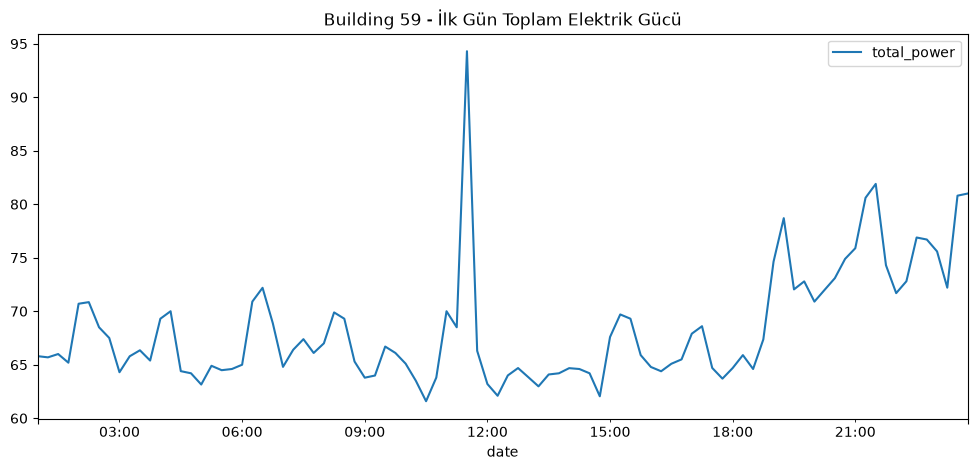

In [6]:
df["date"] = pd.to_datetime(df["date"])

first_day = df[df["date"].dt.date == df["date"].dt.date.iloc[0]]

first_day.plot(
    x="date",
    y="total_power",
    figsize=(12, 5),
    title="Building 59 - İlk Gün Toplam Elektrik Gücü"
)

In [7]:
peak = first_day.loc[
    first_day["total_power"].idxmax(),
    ["date", "mels_S", "lig_S", "mels_N", "hvac_N", "hvac_S", "total_power"]
]

peak

date           2018-01-01 11:30:00
mels_S                         1.1
lig_S                          0.2
mels_N                         6.6
hvac_N                   66.400002
hvac_S                        20.0
total_power              94.300001
Name: 42, dtype: object

In [8]:
first_day.loc[
    (first_day["date"] >= "2018-01-01 10:30") &
    (first_day["date"] <= "2018-01-01 12:30"),
    ["date", "hvac_N", "hvac_S", "total_power"]
]

,date,hvac_N,hvac_S,total_power
38,2018-01-01 10:30:00,35.790001,17.700001,61.590002
39,2018-01-01 10:45:00,36.600000,18.600000,63.800000
40,2018-01-01 11:00:00,37.000000,24.700001,70.000001
41,2018-01-01 11:15:00,36.700001,23.700001,68.500002
42,2018-01-01 11:30:00,66.400002,20.000000,94.300001
43,2018-01-01 11:45:00,37.900002,20.100000,66.300002
44,2018-01-01 12:00:00,36.400000,17.800000,63.200000
45,2018-01-01 12:15:00,35.700001,18.299999,62.100000
46,2018-01-01 12:30:00,37.000000,18.200001,64.000001


In [9]:
df[
    (df["date"].dt.hour == 11) &
    (df["date"].dt.minute == 30)
][["date", "hvac_N", "total_power"]].head(7)

,date,hvac_N,total_power
42,2018-01-01 11:30:00,66.400002,94.300001
138,2018-01-02 11:30:00,38.290000,69.790000
234,2018-01-03 11:30:00,36.700001,65.900001
330,2018-01-04 11:30:00,38.100000,66.900000
426,2018-01-05 11:30:00,36.500000,63.084444
522,2018-01-06 11:30:00,36.400000,57.942459
618,2018-01-07 11:30:00,36.700000,62.054545


In [10]:
occ_path = next(root.rglob("occ.csv"))
occ = pd.read_csv(occ_path)

occ.head()

,date,occ_third_south,occ_fourth_south
0,2018-05-22 07:00:00,0.0,0.0
1,2018-05-22 07:01:00,0.0,1.0
2,2018-05-22 07:02:00,0.0,0.0
3,2018-05-22 07:03:00,0.0,1.0
4,2018-05-22 07:04:00,0.0,0.0


In [11]:
occ["date"] = pd.to_datetime(occ["date"])

occ_15min = (
    occ.set_index("date")
       .resample("15min")
       .mean()
       .reset_index()
)

occ_15min.head()

,date,occ_third_south,occ_fourth_south
0,2018-05-22 07:00:00,0.0,0.400000
1,2018-05-22 07:15:00,0.0,1.000000
2,2018-05-22 07:30:00,0.0,0.466667
3,2018-05-22 07:45:00,0.0,0.000000
4,2018-05-22 08:00:00,0.0,0.000000


In [12]:
occ["date"] = pd.to_datetime(occ["date"])

occ_15min = (
    occ.set_index("date")
       .resample("15min")
       .mean()
       .reset_index()
)

occ_15min.head()

,date,occ_third_south,occ_fourth_south
0,2018-05-22 07:00:00,0.0,0.400000
1,2018-05-22 07:15:00,0.0,1.000000
2,2018-05-22 07:30:00,0.0,0.466667
3,2018-05-22 07:45:00,0.0,0.000000
4,2018-05-22 08:00:00,0.0,0.000000


In [13]:
energy_occ = pd.merge(
    df,
    occ_15min,
    on="date",
    how="inner"
)

energy_occ[
    ["date", "total_power", "occ_third_south", "occ_fourth_south"]
].head()

,date,total_power,occ_third_south,occ_fourth_south
0,2018-05-22 07:00:00,61.89,0.0,0.400000
1,2018-05-22 07:15:00,45.20,0.0,1.000000
2,2018-05-22 07:30:00,28.80,0.0,0.466667
3,2018-05-22 07:45:00,44.59,0.0,0.000000
4,2018-05-22 08:00:00,44.49,0.0,0.000000


In [14]:
co2_path = next(root.rglob("zone_co2.csv"))
co2 = pd.read_csv(co2_path)

co2.head()

,date,zone_022_co2,zone_028_co2,zone_033_co2,zone_040_co2,zone_044_co2,zone_045_co2,zone_052_co2,zone_058_co2,zone_062_co2,zone_068_co2,zone_072_co2
0,2019/8/19 01:33,410.0,416.0,428.0,410.0,397.0,423.0,415.0,405.0,415.0,419.0,408.0
1,2019/8/19 01:34,410.0,418.0,421.0,411.0,406.0,420.0,408.0,405.0,417.0,412.0,412.0
2,2019/8/19 01:35,408.0,429.0,424.0,418.0,409.0,424.0,431.0,414.0,415.0,410.0,416.0
3,2019/8/19 01:36,413.0,414.0,426.0,416.0,407.0,418.0,436.0,414.0,423.0,409.0,417.0
4,2019/8/19 01:37,418.0,404.0,437.0,407.0,412.0,416.0,424.0,409.0,419.0,410.0,408.0


In [15]:
files = [
    "ele.csv",
    "occ.csv",
    "wifi.csv",
    "zone_co2.csv",
    "zone_temp_interior.csv",
    "site_weather.csv"
]

for name in files:
    path = next(root.rglob(name))
    temp = pd.read_csv(path, usecols=["date"])
    temp["date"] = pd.to_datetime(temp["date"])

    print(
        name,
        "→",
        temp["date"].min(),
        "ile",
        temp["date"].max()
    )

ele.csv → 2018-01-01 01:00:00 ile 2021-01-01 00:00:00
occ.csv → 2018-05-22 07:00:00 ile 2019-02-21 10:12:00
wifi.csv → 2018-05-22 00:00:00 ile 2020-12-31 23:55:00
zone_co2.csv → 2019-08-19 01:33:00 ile 2021-01-01 00:00:00
zone_temp_interior.csv → 2018-02-22 00:30:00 ile 2021-01-01 00:00:00
site_weather.csv → 2018-01-01 00:00:00 ile 2021-01-01 00:00:00


In [16]:
wifi_path = next(root.rglob("wifi.csv"))
wifi = pd.read_csv(wifi_path)

wifi["date"] = pd.to_datetime(wifi["date"])

wifi_15min = (
    wifi.set_index("date")
        .resample("15min")
        .mean()
        .reset_index()
)

wifi_15min.head()

,date,wifi_first_south,wifi_second_south,wifi_third_south,wifi_fourth_south
0,2018-05-22 00:00:00,NaN,NaN,37.5,26.0
1,2018-05-22 00:15:00,NaN,NaN,37.0,28.0
2,2018-05-22 00:30:00,NaN,NaN,36.0,27.5
3,2018-05-22 00:45:00,NaN,NaN,36.0,28.0
4,2018-05-22 01:00:00,NaN,NaN,36.0,26.0


In [17]:
occ_wifi = pd.merge(
    occ_15min,
    wifi_15min,
    on="date",
    how="inner"
)

occ_wifi[
    [
        "date",
        "occ_third_south",
        "wifi_third_south",
        "occ_fourth_south",
        "wifi_fourth_south"
    ]
].head()

,date,occ_third_south,wifi_third_south,occ_fourth_south,wifi_fourth_south
0,2018-05-22 07:00:00,0.0,51.0,0.400000,24.0
1,2018-05-22 07:15:00,0.0,50.0,1.000000,22.0
2,2018-05-22 07:30:00,0.0,51.5,0.466667,25.0
3,2018-05-22 07:45:00,0.0,52.0,0.000000,27.0
4,2018-05-22 08:00:00,0.0,61.5,0.000000,27.5


In [18]:
correlation = occ_wifi[
    [
        "occ_third_south",
        "wifi_third_south",
        "occ_fourth_south",
        "wifi_fourth_south"
    ]
].corr()

correlation

,occ_third_south,wifi_third_south,occ_fourth_south,wifi_fourth_south
occ_third_south,1.000000,-0.057474,0.785415,0.035802
wifi_third_south,-0.057474,1.000000,-0.034606,0.857864
occ_fourth_south,0.785415,-0.034606,1.000000,0.077402
wifi_fourth_south,0.035802,0.857864,0.077402,1.000000


In [19]:
occ[
    ["occ_third_south", "occ_fourth_south"]
].describe()

,occ_third_south,occ_fourth_south
count,396193.000000,396193.000000
mean,6.585828,4.850228
std,11.029108,8.305851
min,0.000000,0.000000
25%,0.000000,0.000000
50%,1.000000,1.000000
75%,8.000000,5.000000
max,74.000000,60.000000


In [20]:
energy_occ["total_occupancy"] = (
    energy_occ["occ_third_south"]
    + energy_occ["occ_fourth_south"]
)

energy_occ[
    ["total_power", "total_occupancy"]
].corr()

,total_power,total_occupancy
total_power,1.000000,0.495596
total_occupancy,0.495596,1.000000


In [21]:
energy_occ[
    [
        "total_occupancy",
        "mels_S",
        "lig_S",
        "hvac_S",
        "mels_N",
        "hvac_N",
        "total_power"
    ]
].corr()["total_occupancy"].sort_values(ascending=False)

total_occupancy    1.000000
mels_S             0.815600
mels_N             0.669687
lig_S              0.666809
total_power        0.495596
hvac_N             0.234446
hvac_S             0.182428
Name: total_occupancy, dtype: float64

In [22]:
temp_path = next(root.rglob("zone_temp_interior.csv"))
temp = pd.read_csv(temp_path)

temp.head()

,date,cerc_templogger_1,cerc_templogger_10,cerc_templogger_11,cerc_templogger_12,cerc_templogger_13,cerc_templogger_14,cerc_templogger_15,cerc_templogger_16,cerc_templogger_2,cerc_templogger_3,cerc_templogger_4,cerc_templogger_5,cerc_templogger_6,cerc_templogger_7,cerc_templogger_8,cerc_templogger_9
0,2018-02-22 00:30:00,22.875,22.062,23.312,21.250,21.812,22.687,23.500,22.062,23.375,24.062,23.500,23.125,23.562,22.312,22.375,22.625
1,2018-02-22 00:40:00,22.937,22.750,23.375,21.937,21.812,22.687,23.500,21.937,23.125,24.000,23.562,22.875,23.750,22.500,22.500,22.687
2,2018-02-22 00:50:00,22.937,22.875,23.312,22.312,21.875,22.812,23.562,21.937,23.125,24.250,23.500,23.000,23.625,22.375,22.500,22.687
3,2018-02-22 01:00:00,22.937,23.000,23.375,22.375,21.812,22.812,23.125,21.750,23.375,24.187,23.500,23.062,24.000,22.437,22.375,22.875
4,2018-02-22 01:10:00,23.000,23.000,23.312,22.437,21.812,22.937,23.187,21.937,23.875,24.187,23.500,23.125,24.062,22.437,22.687,22.875


In [23]:
temp["date"] = pd.to_datetime(temp["date"])

temp_columns = [
    col for col in temp.columns
    if col != "date"
]

temp["indoor_temp_avg"] = temp[temp_columns].mean(axis=1)

temp_15min = (
    temp.set_index("date")[["indoor_temp_avg"]]
        .resample("15min")
        .mean()
        .reset_index()
)

temp_15min.head()

,date,indoor_temp_avg
0,2018-02-22 00:30:00,22.825937
1,2018-02-22 00:45:00,22.917750
2,2018-02-22 01:00:00,22.980219
3,2018-02-22 01:15:00,22.988000
4,2018-02-22 01:30:00,22.995844


In [25]:
weather_path = next(root.rglob("site_weather.csv"))
weather = pd.read_csv(weather_path)

weather.head()

,date,air_temp_set_1,air_temp_set_2,dew_point_temperature_set_1d,relative_humidity_set_1,solar_radiation_set_1
0,2018-01-01 00:00:00,11.64,11.51,8.10,79.07,86.70
1,2018-01-01 00:15:00,11.49,11.42,8.14,80.10,45.88
2,2018-01-01 00:30:00,11.59,11.51,8.21,79.92,51.62
3,2018-01-01 00:45:00,11.44,11.41,8.11,80.20,21.43
4,2018-01-01 01:00:00,11.12,11.15,8.04,81.50,6.45


In [26]:
weather["date"] = pd.to_datetime(weather["date"])

weather["outdoor_temp_avg"] = (
    weather["air_temp_set_1"] +
    weather["air_temp_set_2"]
) / 2

weather_clean = weather[
    [
        "date",
        "outdoor_temp_avg",
        "relative_humidity_set_1",
        "solar_radiation_set_1",
        "dew_point_temperature_set_1d"
    ]
].copy()

weather_clean.head()

,date,outdoor_temp_avg,relative_humidity_set_1,solar_radiation_set_1,dew_point_temperature_set_1d
0,2018-01-01 00:00:00,11.575,79.07,86.70,8.10
1,2018-01-01 00:15:00,11.455,80.10,45.88,8.14
2,2018-01-01 00:30:00,11.550,79.92,51.62,8.21
3,2018-01-01 00:45:00,11.425,80.20,21.43,8.11
4,2018-01-01 01:00:00,11.135,81.50,6.45,8.04


In [27]:
co2_path = next(root.rglob("zone_co2.csv"))
co2 = pd.read_csv(co2_path)

co2["date"] = pd.to_datetime(co2["date"])

co2_columns = [
    col for col in co2.columns
    if col != "date"
]

co2["co2_avg"] = co2[co2_columns].mean(axis=1)

co2_15min = (
    co2.set_index("date")[["co2_avg"]]
       .resample("15min")
       .mean()
       .reset_index()
)

co2_15min.head()

,date,co2_avg
0,2019-08-19 01:30:00,414.136364
1,2019-08-19 01:45:00,413.127273
2,2019-08-19 02:00:00,411.733333
3,2019-08-19 02:15:00,414.630303
4,2019-08-19 02:30:00,415.339394


In [28]:
wifi_path = next(root.rglob("wifi.csv"))
wifi = pd.read_csv(wifi_path)

wifi["date"] = pd.to_datetime(wifi["date"])

wifi_columns = [
    col for col in wifi.columns
    if col.startswith("wifi_")
]

wifi["wifi_activity_avg"] = wifi[wifi_columns].mean(axis=1)

wifi_15min = (
    wifi.set_index("date")[["wifi_activity_avg"]]
        .resample("15min")
        .mean()
        .reset_index()
)

wifi_15min.head()wifi["wifi_activity"] = (
    wifi["wifi_third_south"] +
    wifi["wifi_fourth_south"]
)

wifi_15min = (
    wifi.set_index("date")[["wifi_activity"]]
        .resample("15min")
        .mean()
        .reset_index()
)

wifi_15min.head()

,date,wifi_activity_avg
0,2018-05-22 00:00:00,31.75
1,2018-05-22 00:15:00,32.50
2,2018-05-22 00:30:00,31.75
3,2018-05-22 00:45:00,32.00
4,2018-05-22 01:00:00,31.00


In [29]:
wifi["wifi_activity"] = (
    wifi["wifi_third_south"] +
    wifi["wifi_fourth_south"]
)

wifi_15min = (
    wifi.set_index("date")[["wifi_activity"]]
        .resample("15min")
        .mean()
        .reset_index()
)

wifi_15min.head()

,date,wifi_activity
0,2018-05-22 00:00:00,63.5
1,2018-05-22 00:15:00,65.0
2,2018-05-22 00:30:00,63.5
3,2018-05-22 00:45:00,64.0
4,2018-05-22 01:00:00,62.0


In [30]:
ecotwin = df[
    [
        "date",
        "total_power",
        "mels_S",
        "lig_S",
        "mels_N",
        "hvac_N",
        "hvac_S"
    ]
].copy()

ecotwin = ecotwin.merge(
    temp_15min,
    on="date",
    how="inner"
)

ecotwin = ecotwin.merge(
    weather_clean,
    on="date",
    how="inner"
)

ecotwin = ecotwin.merge(
    co2_15min,
    on="date",
    how="inner"
)

ecotwin = ecotwin.merge(
    wifi_15min,
    on="date",
    how="inner"
)

print("Satır sayısı:", len(ecotwin))
print("Başlangıç:", ecotwin["date"].min())
print("Bitiş:", ecotwin["date"].max())

ecotwin.head()

Satır sayısı: 47055
Başlangıç: 2019-08-19 01:30:00
Bitiş: 2020-12-31 23:45:00


,date,total_power,mels_S,lig_S,mels_N,hvac_N,hvac_S,indoor_temp_avg,outdoor_temp_avg,relative_humidity_set_1,solar_radiation_set_1,dew_point_temperature_set_1d,co2_avg,wifi_activity
0,2019-08-19 01:30:00,39.071765,1.800,0.22,9.5000,18.834118,8.717647,23.566433,14.905,78.7,116.60,11.84,414.136364,NaN
1,2019-08-19 01:45:00,40.322074,2.100,0.10,8.9000,20.587368,8.634706,23.520600,14.675,80.3,85.50,11.84,413.127273,NaN
2,2019-08-19 02:00:00,41.019147,1.925,0.10,9.1975,20.427647,9.369000,23.508033,14.685,81.0,81.60,11.92,411.733333,NaN
3,2019-08-19 02:15:00,31.618399,1.750,0.14,9.4950,19.261176,0.972222,23.495667,14.570,81.2,45.04,11.84,414.630303,NaN
4,2019-08-19 02:30:00,39.878889,2.000,0.28,10.5000,20.010556,7.088333,23.487233,14.285,81.6,22.77,11.63,415.339394,NaN


In [31]:
print("Satır:", len(ecotwin))
print("Tekrarlanan zaman:", ecotwin["date"].duplicated().sum())
print("Eksik değer toplamı:", ecotwin.isna().sum().sum())

print("\nSütun bazında eksikler:")
print(ecotwin.isna().sum())

expected_dates = pd.date_range(
    start=ecotwin["date"].min(),
    end=ecotwin["date"].max(),
    freq="15min"
)

print("\nOlması gereken zaman sayısı:", len(expected_dates))
print("Gerçekte olan:", len(ecotwin))
print("Eksik zaman noktası:", len(expected_dates) - len(ecotwin))

Satır: 47055
Tekrarlanan zaman: 0
Eksik değer toplamı: 29638

Sütun bazında eksikler:
date                                0
total_power                       882
mels_S                              2
lig_S                              13
mels_N                              3
hvac_N                            869
hvac_S                            869
indoor_temp_avg                     1
outdoor_temp_avg                    0
relative_humidity_set_1             0
solar_radiation_set_1               0
dew_point_temperature_set_1d        0
co2_avg                         11175
wifi_activity                   15824
dtype: int64

Olması gereken zaman sayısı: 48090
Gerçekte olan: 47055
Eksik zaman noktası: 1035


In [32]:
core_columns = [
    "date",
    "total_power",
    "indoor_temp_avg",
    "outdoor_temp_avg",
    "relative_humidity_set_1",
    "solar_radiation_set_1",
    "dew_point_temperature_set_1d"
]

core = (
    ecotwin[core_columns]
    .dropna()
    .sort_values("date")
    .reset_index(drop=True)
)

print("Core satır sayısı:", len(core))
print("Başlangıç:", core["date"].min())
print("Bitiş:", core["date"].max())

core.isna().sum()core_columns = [
    "date",
    "total_power",
    "indoor_temp_avg",
    "outdoor_temp_avg",
    "relative_humidity_set_1",
    "solar_radiation_set_1",
    "dew_point_temperature_set_1d"
]

core = (
    ecotwin[core_columns]
    .dropna()
    .sort_values("date")
    .reset_index(drop=True)
)

print("Core satır sayısı:", len(core))
print("Başlangıç:", core["date"].min())
print("Bitiş:", core["date"].max())

core.isna().sum()

Core satır sayısı: 46173
Başlangıç: 2019-08-19 01:30:00
Bitiş: 2020-12-31 23:45:00


date                            0
total_power                     0
indoor_temp_avg                 0
outdoor_temp_avg                0
relative_humidity_set_1         0
solar_radiation_set_1           0
dew_point_temperature_set_1d    0
dtype: int64

In [33]:
core_columns = [
    "date",
    "total_power",
    "indoor_temp_avg",
    "outdoor_temp_avg",
    "relative_humidity_set_1",
    "solar_radiation_set_1",
    "dew_point_temperature_set_1d"
]

core = (
    ecotwin[core_columns]
    .dropna()
    .sort_values("date")
    .reset_index(drop=True)
)

print("Core satır sayısı:", len(core))
print("Başlangıç:", core["date"].min())
print("Bitiş:", core["date"].max())

core.isna().sum()

Core satır sayısı: 46173
Başlangıç: 2019-08-19 01:30:00
Bitiş: 2020-12-31 23:45:00


date                            0
total_power                     0
indoor_temp_avg                 0
outdoor_temp_avg                0
relative_humidity_set_1         0
solar_radiation_set_1           0
dew_point_temperature_set_1d    0
dtype: int64

In [34]:
power_by_time = core.set_index("date")["total_power"]

core["target_30m"] = (
    core["date"] + pd.Timedelta(minutes=30)
).map(power_by_time)

core["target_60m"] = (
    core["date"] + pd.Timedelta(minutes=60)
).map(power_by_time)

print("30 dk hedefi eksik:", core["target_30m"].isna().sum())
print("60 dk hedefi eksik:", core["target_60m"].isna().sum())

core[
    ["date", "total_power", "target_30m", "target_60m"]
].head(10)

30 dk hedefi eksik: 12
60 dk hedefi eksik: 24


,date,total_power,target_30m,target_60m
0,2019-08-19 01:30:00,39.071765,41.019147,39.878889
1,2019-08-19 01:45:00,40.322074,31.618399,39.913492
2,2019-08-19 02:00:00,41.019147,39.878889,42.843824
3,2019-08-19 02:15:00,31.618399,39.913492,47.987632
4,2019-08-19 02:30:00,39.878889,42.843824,54.702857
5,2019-08-19 02:45:00,39.913492,47.987632,47.069202
6,2019-08-19 03:00:00,42.843824,54.702857,25.417222
7,2019-08-19 03:15:00,47.987632,47.069202,29.179771
8,2019-08-19 03:30:00,54.702857,25.417222,35.197778
9,2019-08-19 03:45:00,47.069202,29.179771,46.649118


In [35]:
model_data = core.dropna(
    subset=["target_30m", "target_60m"]
).copy()

model_data["hour"] = model_data["date"].dt.hour
model_data["minute"] = model_data["date"].dt.minute
model_data["day_of_week"] = model_data["date"].dt.dayofweek
model_data["month"] = model_data["date"].dt.month
model_data["is_weekend"] = (
    model_data["day_of_week"] >= 5
).astype(int)

print("Model için hazır kayıt:", len(model_data))

model_data[
    [
        "date",
        "total_power",
        "hour",
        "minute",
        "day_of_week",
        "month",
        "is_weekend",
        "target_30m",
        "target_60m"
    ]
].head()

Model için hazır kayıt: 46149


,date,total_power,hour,minute,day_of_week,month,is_weekend,target_30m,target_60m
0,2019-08-19 01:30:00,39.071765,1,30,0,8,0,41.019147,39.878889
1,2019-08-19 01:45:00,40.322074,1,45,0,8,0,31.618399,39.913492
2,2019-08-19 02:00:00,41.019147,2,0,0,8,0,39.878889,42.843824
3,2019-08-19 02:15:00,31.618399,2,15,0,8,0,39.913492,47.987632
4,2019-08-19 02:30:00,39.878889,2,30,0,8,0,42.843824,54.702857


In [37]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Zaman sırasını koruyarak %80 eğitim, %20 test
split_index = int(len(model_data) * 0.80)

train = model_data.iloc[:split_index]
test = model_data.iloc[split_index:]

# Baseline: gelecekteki enerji = şu anki enerji
baseline_30m = test["total_power"]
baseline_60m = test["total_power"]

mae_30 = mean_absolute_error(test["target_30m"], baseline_30m)
rmse_30 = np.sqrt(mean_squared_error(test["target_30m"], baseline_30m))

mae_60 = mean_absolute_error(test["target_60m"], baseline_60m)
rmse_60 = np.sqrt(mean_squared_error(test["target_60m"], baseline_60m))

print("=== BASELINE ===")
print(f"30 dakika → MAE: {mae_30:.2f} kW | RMSE: {rmse_30:.2f} kW")
print(f"60 dakika → MAE: {mae_60:.2f} kW | RMSE: {rmse_60:.2f} kW")

print("\nTrain:", len(train))
print("Test:", len(test))
print("Test başlangıcı:", test["date"].min())
print("Test bitişi:", test["date"].max())

=== BASELINE ===
30 dakika → MAE: 2.58 kW | RMSE: 4.33 kW
60 dakika → MAE: 3.26 kW | RMSE: 5.60 kW

Train: 36919
Test: 9230
Test başlangıcı: 2020-09-26 19:30:00
Test bitişi: 2020-12-31 22:45:00


In [38]:
power_by_time = model_data.set_index("date")["total_power"]

model_data["power_lag_15m"] = (
    model_data["date"] - pd.Timedelta(minutes=15)
).map(power_by_time)

model_data["power_lag_30m"] = (
    model_data["date"] - pd.Timedelta(minutes=30)
).map(power_by_time)

model_data["power_lag_60m"] = (
    model_data["date"] - pd.Timedelta(minutes=60)
).map(power_by_time)

print(
    model_data[
        [
            "date",
            "power_lag_60m",
            "power_lag_30m",
            "power_lag_15m",
            "total_power",
            "target_30m",
            "target_60m"
        ]
    ].head(10)
)

print("\nEksikler:")
print(
    model_data[
        ["power_lag_15m", "power_lag_30m", "power_lag_60m"]
    ].isna().sum()
)

                 date  power_lag_60m  power_lag_30m  power_lag_15m  \
0 2019-08-19 01:30:00            NaN            NaN            NaN   
1 2019-08-19 01:45:00            NaN            NaN      39.071765   
2 2019-08-19 02:00:00            NaN      39.071765      40.322074   
3 2019-08-19 02:15:00            NaN      40.322074      41.019147   
4 2019-08-19 02:30:00      39.071765      41.019147      31.618399   
5 2019-08-19 02:45:00      40.322074      31.618399      39.878889   
6 2019-08-19 03:00:00      41.019147      39.878889      39.913492   
7 2019-08-19 03:15:00      31.618399      39.913492      42.843824   
8 2019-08-19 03:30:00      39.878889      42.843824      47.987632   
9 2019-08-19 03:45:00      39.913492      47.987632      54.702857   

   total_power  target_30m  target_60m  
0    39.071765   41.019147   39.878889  
1    40.322074   31.618399   39.913492  
2    41.019147   39.878889   42.843824  
3    31.618399   39.913492   47.987632  
4    39.878889   42.8438

In [39]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

features = [
    "total_power",
    "power_lag_15m",
    "power_lag_30m",
    "power_lag_60m",
    "indoor_temp_avg",
    "outdoor_temp_avg",
    "relative_humidity_set_1",
    "solar_radiation_set_1",
    "dew_point_temperature_set_1d",
    "hour",
    "minute",
    "day_of_week",
    "month",
    "is_weekend"
]

ml_data = model_data.dropna(
    subset=features + ["target_30m", "target_60m"]
).copy()

split_index = int(len(ml_data) * 0.80)

train_ml = ml_data.iloc[:split_index]
test_ml = ml_data.iloc[split_index:]

X_train = train_ml[features]
X_test = test_ml[features]

# 30 dakika modeli
model_30 = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    random_state=42
)

model_30.fit(X_train, train_ml["target_30m"])
pred_30 = model_30.predict(X_test)

# 60 dakika modeli
model_60 = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    random_state=42
)

model_60.fit(X_train, train_ml["target_60m"])
pred_60 = model_60.predict(X_test)

# ML skorları
ml_mae_30 = mean_absolute_error(test_ml["target_30m"], pred_30)
ml_rmse_30 = np.sqrt(
    mean_squared_error(test_ml["target_30m"], pred_30)
)

ml_mae_60 = mean_absolute_error(test_ml["target_60m"], pred_60)
ml_rmse_60 = np.sqrt(
    mean_squared_error(test_ml["target_60m"], pred_60)
)

# Aynı test setinde baseline
base_mae_30 = mean_absolute_error(
    test_ml["target_30m"],
    test_ml["total_power"]
)

base_mae_60 = mean_absolute_error(
    test_ml["target_60m"],
    test_ml["total_power"]
)

print("=== 30 DAKİKA ===")
print(f"Baseline MAE: {base_mae_30:.2f} kW")
print(f"ML MAE:       {ml_mae_30:.2f} kW")
print(f"ML RMSE:      {ml_rmse_30:.2f} kW")

print("\n=== 60 DAKİKA ===")
print(f"Baseline MAE: {base_mae_60:.2f} kW")
print(f"ML MAE:       {ml_mae_60:.2f} kW")
print(f"ML RMSE:      {ml_rmse_60:.2f} kW")

print("\nTrain:", len(train_ml))
print("Test:", len(test_ml))

=== 30 DAKİKA ===
Baseline MAE: 2.58 kW
ML MAE:       3.38 kW
ML RMSE:      5.10 kW

=== 60 DAKİKA ===
Baseline MAE: 3.26 kW
ML MAE:       4.76 kW
ML RMSE:      7.14 kW

Train: 36900
Test: 9225


In [40]:
power_by_time = model_data.set_index("date")["total_power"]

model_data["power_lag_24h"] = (
    model_data["date"] - pd.Timedelta(hours=24)
).map(power_by_time)

model_data["power_lag_7d"] = (
    model_data["date"] - pd.Timedelta(days=7)
).map(power_by_time)

model_data[
    [
        "date",
        "total_power",
        "power_lag_24h",
        "power_lag_7d"
    ]
].head(10)

,date,total_power,power_lag_24h,power_lag_7d
0,2019-08-19 01:30:00,39.071765,NaN,NaN
1,2019-08-19 01:45:00,40.322074,NaN,NaN
2,2019-08-19 02:00:00,41.019147,NaN,NaN
3,2019-08-19 02:15:00,31.618399,NaN,NaN
4,2019-08-19 02:30:00,39.878889,NaN,NaN
5,2019-08-19 02:45:00,39.913492,NaN,NaN
6,2019-08-19 03:00:00,42.843824,NaN,NaN
7,2019-08-19 03:15:00,47.987632,NaN,NaN
8,2019-08-19 03:30:00,54.702857,NaN,NaN
9,2019-08-19 03:45:00,47.069202,NaN,NaN


In [41]:
print("24 saatlik lag eksik:", model_data["power_lag_24h"].isna().sum())
print("7 günlük lag eksik:", model_data["power_lag_7d"].isna().sum())

model_data.loc[
    model_data["power_lag_7d"].notna(),
    [
        "date",
        "total_power",
        "power_lag_24h",
        "power_lag_7d",
        "target_30m",
        "target_60m"
    ]
].head()

24 saatlik lag eksik: 569
7 günlük lag eksik: 1959


,date,total_power,power_lag_24h,power_lag_7d,target_30m,target_60m
1045,2019-09-08 00:00:00,22.663455,96.737857,85.484385,19.381857,20.482857
1046,2019-09-08 00:15:00,13.831111,90.328333,83.616250,22.604444,30.698810
1047,2019-09-08 00:30:00,19.381857,86.104524,80.274487,20.482857,40.077222
1048,2019-09-08 00:45:00,22.604444,89.187980,83.387955,30.698810,30.040000
1049,2019-09-08 01:00:00,20.482857,79.219773,78.823333,40.077222,33.323333


In [42]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

features_v2 = [
    "total_power",
    "power_lag_15m",
    "power_lag_30m",
    "power_lag_60m",
    "power_lag_24h",
    "power_lag_7d",
    "indoor_temp_avg",
    "outdoor_temp_avg",
    "relative_humidity_set_1",
    "solar_radiation_set_1",
    "dew_point_temperature_set_1d",
    "hour",
    "minute",
    "day_of_week",
    "month",
    "is_weekend"
]

ml_v2 = model_data.dropna(
    subset=features_v2 + ["target_30m", "target_60m"]
).copy()

split_index = int(len(ml_v2) * 0.80)

train_v2 = ml_v2.iloc[:split_index]
test_v2 = ml_v2.iloc[split_index:]

X_train_v2 = train_v2[features_v2]
X_test_v2 = test_v2[features_v2]

# 30 dakika
model_30_v2 = HistGradientBoostingRegressor(
    max_iter=400,
    learning_rate=0.05,
    max_leaf_nodes=31,
    random_state=42
)

model_30_v2.fit(X_train_v2, train_v2["target_30m"])
pred_30_v2 = model_30_v2.predict(X_test_v2)

# 60 dakika
model_60_v2 = HistGradientBoostingRegressor(
    max_iter=400,
    learning_rate=0.05,
    max_leaf_nodes=31,
    random_state=42
)

model_60_v2.fit(X_train_v2, train_v2["target_60m"])
pred_60_v2 = model_60_v2.predict(X_test_v2)

# ML skorları
mae_30_v2 = mean_absolute_error(test_v2["target_30m"], pred_30_v2)
rmse_30_v2 = np.sqrt(
    mean_squared_error(test_v2["target_30m"], pred_30_v2)
)

mae_60_v2 = mean_absolute_error(test_v2["target_60m"], pred_60_v2)
rmse_60_v2 = np.sqrt(
    mean_squared_error(test_v2["target_60m"], pred_60_v2)
)

# Aynı test setindeki baseline
base_30_v2 = mean_absolute_error(
    test_v2["target_30m"],
    test_v2["total_power"]
)

base_60_v2 = mean_absolute_error(
    test_v2["target_60m"],
    test_v2["total_power"]
)

print("=== MODEL V2 ===")

print("\n30 DAKİKA")
print(f"Baseline MAE: {base_30_v2:.2f} kW")
print(f"Model V2 MAE: {mae_30_v2:.2f} kW")
print(f"Model V2 RMSE: {rmse_30_v2:.2f} kW")

print("\n60 DAKİKA")
print(f"Baseline MAE: {base_60_v2:.2f} kW")
print(f"Model V2 MAE: {mae_60_v2:.2f} kW")
print(f"Model V2 RMSE: {rmse_60_v2:.2f} kW")

=== MODEL V2 ===

30 DAKİKA
Baseline MAE: 2.55 kW
Model V2 MAE: 3.67 kW
Model V2 RMSE: 5.32 kW

60 DAKİKA
Baseline MAE: 3.21 kW
Model V2 MAE: 4.96 kW
Model V2 RMSE: 7.41 kW


In [43]:
# Gelecekteki değişimi hedef yapıyoruz
ml_data["delta_30m"] = (
    ml_data["target_30m"] - ml_data["total_power"]
)

ml_data["delta_60m"] = (
    ml_data["target_60m"] - ml_data["total_power"]
)

features_delta = [
    "total_power",
    "power_lag_15m",
    "power_lag_30m",
    "power_lag_60m",
    "indoor_temp_avg",
    "outdoor_temp_avg",
    "relative_humidity_set_1",
    "solar_radiation_set_1",
    "dew_point_temperature_set_1d",
    "hour",
    "minute",
    "day_of_week",
    "month",
    "is_weekend"
]

delta_data = ml_data.dropna(
    subset=features_delta + ["delta_30m", "delta_60m"]
).copy()

split_index = int(len(delta_data) * 0.80)

train_delta = delta_data.iloc[:split_index]
test_delta = delta_data.iloc[split_index:]

X_train = train_delta[features_delta]
X_test = test_delta[features_delta]

# 30 dakika değişim modeli
delta_model_30 = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.04,
    max_leaf_nodes=20,
    l2_regularization=1.0,
    random_state=42
)

delta_model_30.fit(X_train, train_delta["delta_30m"])

pred_delta_30 = delta_model_30.predict(X_test)

pred_30_final = (
    test_delta["total_power"].values + pred_delta_30
)

# 60 dakika değişim modeli
delta_model_60 = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.04,
    max_leaf_nodes=20,
    l2_regularization=1.0,
    random_state=42
)

delta_model_60.fit(X_train, train_delta["delta_60m"])

pred_delta_60 = delta_model_60.predict(X_test)

pred_60_final = (
    test_delta["total_power"].values + pred_delta_60
)

# Sonuçlar
delta_mae_30 = mean_absolute_error(
    test_delta["target_30m"],
    pred_30_final
)

delta_rmse_30 = np.sqrt(
    mean_squared_error(
        test_delta["target_30m"],
        pred_30_final
    )
)

delta_mae_60 = mean_absolute_error(
    test_delta["target_60m"],
    pred_60_final
)

delta_rmse_60 = np.sqrt(
    mean_squared_error(
        test_delta["target_60m"],
        pred_60_final
    )
)

# Aynı test setindeki baseline
baseline_delta_30 = mean_absolute_error(
    test_delta["target_30m"],
    test_delta["total_power"]
)

baseline_delta_60 = mean_absolute_error(
    test_delta["target_60m"],
    test_delta["total_power"]
)

print("=== DELTA MODEL ===")

print("\n30 DAKİKA")
print(f"Baseline MAE: {baseline_delta_30:.2f} kW")
print(f"Delta Model MAE: {delta_mae_30:.2f} kW")
print(f"Delta Model RMSE: {delta_rmse_30:.2f} kW")

print("\n60 DAKİKA")
print(f"Baseline MAE: {baseline_delta_60:.2f} kW")
print(f"Delta Model MAE: {delta_mae_60:.2f} kW")
print(f"Delta Model RMSE: {delta_rmse_60:.2f} kW")

=== DELTA MODEL ===

30 DAKİKA
Baseline MAE: 2.58 kW
Delta Model MAE: 3.22 kW
Delta Model RMSE: 4.86 kW

60 DAKİKA
Baseline MAE: 3.26 kW
Delta Model MAE: 4.58 kW
Delta Model RMSE: 6.96 kW


In [44]:
power_by_time = model_data.set_index("date")["total_power"]

benchmark = model_data.copy()

# 30 dakika sonrası için seasonal naive tahminleri
benchmark["daily_naive_30m"] = (
    benchmark["date"]
    + pd.Timedelta(minutes=30)
    - pd.Timedelta(days=1)
).map(power_by_time)

benchmark["weekly_naive_30m"] = (
    benchmark["date"]
    + pd.Timedelta(minutes=30)
    - pd.Timedelta(days=7)
).map(power_by_time)

# 60 dakika sonrası için seasonal naive tahminleri
benchmark["daily_naive_60m"] = (
    benchmark["date"]
    + pd.Timedelta(minutes=60)
    - pd.Timedelta(days=1)
).map(power_by_time)

benchmark["weekly_naive_60m"] = (
    benchmark["date"]
    + pd.Timedelta(minutes=60)
    - pd.Timedelta(days=7)
).map(power_by_time)

benchmark = benchmark.dropna(
    subset=[
        "target_30m",
        "target_60m",
        "daily_naive_30m",
        "weekly_naive_30m",
        "daily_naive_60m",
        "weekly_naive_60m"
    ]
).copy()

split = int(len(benchmark) * 0.80)
benchmark_test = benchmark.iloc[split:]

def mae(real, predicted):
    return mean_absolute_error(real, predicted)

print("=== 30 DAKİKA BENCHMARK ===")
print(
    "Persistence:",
    round(mae(
        benchmark_test["target_30m"],
        benchmark_test["total_power"]
    ), 3),
    "kW"
)

print(
    "Daily Naive:",
    round(mae(
        benchmark_test["target_30m"],
        benchmark_test["daily_naive_30m"]
    ), 3),
    "kW"
)

print(
    "Weekly Naive:",
    round(mae(
        benchmark_test["target_30m"],
        benchmark_test["weekly_naive_30m"]
    ), 3),
    "kW"
)

print("\n=== 60 DAKİKA BENCHMARK ===")
print(
    "Persistence:",
    round(mae(
        benchmark_test["target_60m"],
        benchmark_test["total_power"]
    ), 3),
    "kW"
)

print(
    "Daily Naive:",
    round(mae(
        benchmark_test["target_60m"],
        benchmark_test["daily_naive_60m"]
    ), 3),
    "kW"
)

print(
    "Weekly Naive:",
    round(mae(
        benchmark_test["target_60m"],
        benchmark_test["weekly_naive_60m"]
    ), 3),
    "kW"
)

print("\nTest kayıt sayısı:", len(benchmark_test))

=== 30 DAKİKA BENCHMARK ===
Persistence: 2.547 kW
Daily Naive: 8.394 kW
Weekly Naive: 16.751 kW

=== 60 DAKİKA BENCHMARK ===
Persistence: 3.213 kW
Daily Naive: 8.389 kW
Weekly Naive: 16.746 kW

Test kayıt sayısı: 8788


In [45]:
power_by_time = model_data.set_index("date")["total_power"]

lag_minutes = [15, 30, 45, 60, 75, 90, 105, 120]

for minute in lag_minutes:
    model_data[f"power_lag_{minute}m"] = (
        model_data["date"] - pd.Timedelta(minutes=minute)
    ).map(power_by_time)

lag_columns = [
    f"power_lag_{minute}m"
    for minute in lag_minutes
]

# Son 2 saatin enerji davranışı
model_data["power_recent_mean"] = model_data[lag_columns].mean(axis=1)
model_data["power_recent_std"] = model_data[lag_columns].std(axis=1)
model_data["power_recent_min"] = model_data[lag_columns].min(axis=1)
model_data["power_recent_max"] = model_data[lag_columns].max(axis=1)

# Son 1 saatteki yön/değişim
model_data["power_trend_60m"] = (
    model_data["total_power"]
    - model_data["power_lag_60m"]
)

model_data[
    [
        "date",
        "total_power",
        "power_recent_mean",
        "power_recent_std",
        "power_trend_60m"
    ]
].head(10)

,date,total_power,power_recent_mean,power_recent_std,power_trend_60m
0,2019-08-19 01:30:00,39.071765,NaN,NaN,NaN
1,2019-08-19 01:45:00,40.322074,39.071765,NaN,NaN
2,2019-08-19 02:00:00,41.019147,39.696920,0.884102,NaN
3,2019-08-19 02:15:00,31.618399,40.137662,0.986702,NaN
4,2019-08-19 02:30:00,39.878889,38.007846,4.335149,0.807124
5,2019-08-19 02:45:00,39.913492,38.382055,3.846465,-0.408582
6,2019-08-19 03:00:00,42.843824,38.637294,3.496730,1.824676
7,2019-08-19 03:15:00,47.987632,39.238227,3.566106,16.369233
8,2019-08-19 03:30:00,54.702857,40.331903,4.524311,14.823968
9,2019-08-19 03:45:00,47.069202,42.285789,6.736688,7.155710


In [46]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

features_v3 = [
    "total_power",

    # Son 2 saat
    "power_lag_15m",
    "power_lag_30m",
    "power_lag_45m",
    "power_lag_60m",
    "power_lag_75m",
    "power_lag_90m",
    "power_lag_105m",
    "power_lag_120m",

    # Son dönem davranışı
    "power_recent_mean",
    "power_recent_std",
    "power_recent_min",
    "power_recent_max",
    "power_trend_60m",

    # İç/dış ortam
    "indoor_temp_avg",
    "outdoor_temp_avg",
    "relative_humidity_set_1",
    "solar_radiation_set_1",
    "dew_point_temperature_set_1d",

    # Zaman
    "hour",
    "minute",
    "day_of_week",
    "month",
    "is_weekend"
]

v3_data = model_data.dropna(
    subset=features_v3 + ["target_30m", "target_60m"]
).copy()

split = int(len(v3_data) * 0.80)

train_v3 = v3_data.iloc[:split]
test_v3 = v3_data.iloc[split:]

X_train = train_v3[features_v3]
X_test = test_v3[features_v3]

# 30 dakika
model_30_v3 = HistGradientBoostingRegressor(
    max_iter=500,
    learning_rate=0.03,
    max_leaf_nodes=20,
    l2_regularization=2.0,
    random_state=42
)

model_30_v3.fit(X_train, train_v3["target_30m"])
pred_30_v3 = model_30_v3.predict(X_test)

# 60 dakika
model_60_v3 = HistGradientBoostingRegressor(
    max_iter=500,
    learning_rate=0.03,
    max_leaf_nodes=20,
    l2_regularization=2.0,
    random_state=42
)

model_60_v3.fit(X_train, train_v3["target_60m"])
pred_60_v3 = model_60_v3.predict(X_test)

# V3 skorları
mae_30_v3 = mean_absolute_error(
    test_v3["target_30m"], pred_30_v3
)

rmse_30_v3 = np.sqrt(
    mean_squared_error(
        test_v3["target_30m"], pred_30_v3
    )
)

mae_60_v3 = mean_absolute_error(
    test_v3["target_60m"], pred_60_v3
)

rmse_60_v3 = np.sqrt(
    mean_squared_error(
        test_v3["target_60m"], pred_60_v3
    )
)

# Aynı test setindeki persistence
base_30_v3 = mean_absolute_error(
    test_v3["target_30m"],
    test_v3["total_power"]
)

base_60_v3 = mean_absolute_error(
    test_v3["target_60m"],
    test_v3["total_power"]
)

print("=== MODEL V3 ===")

print("\n30 DAKİKA")
print(f"Persistence MAE: {base_30_v3:.3f} kW")
print(f"V3 MAE:          {mae_30_v3:.3f} kW")
print(f"V3 RMSE:         {rmse_30_v3:.3f} kW")

print("\n60 DAKİKA")
print(f"Persistence MAE: {base_60_v3:.3f} kW")
print(f"V3 MAE:          {mae_60_v3:.3f} kW")
print(f"V3 RMSE:         {rmse_60_v3:.3f} kW")

print("\nTrain:", len(train_v3))
print("Test:", len(test_v3))

=== MODEL V3 ===

30 DAKİKA
Persistence MAE: 2.581 kW
V3 MAE:          3.023 kW
V3 RMSE:         4.722 kW

60 DAKİKA
Persistence MAE: 3.263 kW
V3 MAE:          4.225 kW
V3 RMSE:         6.584 kW

Train: 36880
Test: 9221


In [48]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
import pandas as pd

validation_data = model_data.dropna(
    subset=features_v3 + ["target_30m", "target_60m"]
).copy().reset_index(drop=True)

tscv = TimeSeriesSplit(n_splits=5)

results = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(validation_data), start=1):

    train_fold = validation_data.iloc[train_idx]
    test_fold = validation_data.iloc[test_idx]

    X_train = train_fold[features_v3]
    X_test = test_fold[features_v3]

    # 30 dakika modeli
    model_30_cv = HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.03,
        max_leaf_nodes=20,
        l2_regularization=2.0,
        random_state=42
    )

    model_30_cv.fit(
        X_train,
        train_fold["target_30m"]
    )

    pred_30 = model_30_cv.predict(X_test)

    # 60 dakika modeli
    model_60_cv = HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.03,
        max_leaf_nodes=20,
        l2_regularization=2.0,
        random_state=42
    )

    model_60_cv.fit(
        X_train,
        train_fold["target_60m"]
    )

    pred_60 = model_60_cv.predict(X_test)

    # Persistence
    base_30 = mean_absolute_error(
        test_fold["target_30m"],
        test_fold["total_power"]
    )

    base_60 = mean_absolute_error(
        test_fold["target_60m"],
        test_fold["total_power"]
    )

    # ML
    ml_30 = mean_absolute_error(
        test_fold["target_30m"],
        pred_30
    )

    ml_60 = mean_absolute_error(
        test_fold["target_60m"],
        pred_60
    )

    results.append({
        "fold": fold,
        "start": test_fold["date"].min(),
        "end": test_fold["date"].max(),
        "persistence_30m": base_30,
        "v3_30m": ml_30,
        "persistence_60m": base_60,
        "v3_60m": ml_60
    })

cv_results = pd.DataFrame(results)

cv_results

,fold,start,end,persistence_30m,v3_30m,persistence_60m,v3_60m
0,1,2019-11-26 11:45:00,2020-02-15 19:45:00,4.221754,4.782640,5.261954,6.076133
1,2,2020-02-15 20:00:00,2020-05-05 20:30:00,2.553462,2.921075,3.261180,3.925379
2,3,2020-05-05 20:45:00,2020-07-24 21:15:00,2.228407,2.377652,2.844133,3.188228
3,4,2020-07-24 21:30:00,2020-10-12 22:00:00,2.949992,3.192982,3.531256,4.062133
4,5,2020-10-12 22:15:00,2020-12-31 22:45:00,2.583969,2.962630,3.270148,4.043450


In [49]:
try:
    import tensorflow as tf
    print("TensorFlow sürümü:", tf.__version__)
    print("TensorFlow hazır ✅")
except ImportError:
    print("TensorFlow kurulu değil")

TensorFlow kurulu değil


In [50]:
import sys
import platform

print("Python:", sys.version)
print("Python yolu:", sys.executable)
print("İşlemci:", platform.machine())

Python: 3.13.13 | packaged by Anaconda, Inc. | (main, Apr 14 2026, 06:14:06) [Clang 20.1.8 ]
Python yolu: /Users/muhammedmusaalver/Documents/EcoTwinAI/.venv/bin/python
İşlemci: arm64


In [51]:
%pip install tensorflow==2.21.0

  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached protobuf-7.35.1-cp310-abi3-macosx_10_9_universal2.whl.metadata (595 bytes)
  Using cached ml_dtypes-0.5.4-cp313-cp313-macosx_10_13_universal2.whl.metadata (8.9 kB)
  Using cached wheel-0.47.0-py3-none-any.whl.metadata (2.3 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached markdown_it_py-4.2.0-py3-none-any.whl.metadata (7.4 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.8/223.8 MB 13.7 MB/s  0:00:16m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 24.6 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 32.1 MB/s  0:00:00
Using cached ml_dtypes-0.5.4-cp313-cp313-macosx_10_13_universal2.whl (676 kB)
Using cached protobuf-7.35.1-cp310-abi3-macosx_10_9_universal2.whl (433 kB)
Using cached wheel-0.47.0-py3-none-any.whl (32 kB)
Using cached flatbuffers-25.12.1

In [1]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("Hazır ✅")

TensorFlow: 2.21.0
Hazır ✅


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

root = Path("data/raw/building59")

print("Veri yolu:", root)
print("Hazırlık tamam ✅")

Veri yolu: data/raw/building59
Hazırlık tamam ✅


In [3]:
# 1) ENERJİ
ele_path = next(root.rglob("ele.csv"))
energy = pd.read_csv(ele_path)

energy["date"] = pd.to_datetime(energy["date"])

energy["total_power"] = (
    energy["mels_S"]
    + energy["lig_S"]
    + energy["mels_N"]
    + energy["hvac_N"]
    + energy["hvac_S"]
)

energy = energy[
    ["date", "total_power"]
].copy()


# 2) İÇ SICAKLIK
temp_path = next(root.rglob("zone_temp_interior.csv"))
temp = pd.read_csv(temp_path)

temp["date"] = pd.to_datetime(temp["date"])

temp_cols = [
    col for col in temp.columns
    if col != "date"
]

temp["indoor_temp_avg"] = temp[temp_cols].mean(axis=1)

temp_15min = (
    temp.set_index("date")[["indoor_temp_avg"]]
        .resample("15min")
        .mean()
        .reset_index()
)


# 3) DIŞ HAVA
weather_path = next(root.rglob("site_weather.csv"))
weather = pd.read_csv(weather_path)

weather["date"] = pd.to_datetime(weather["date"])

weather["outdoor_temp_avg"] = (
    weather["air_temp_set_1"]
    + weather["air_temp_set_2"]
) / 2

weather_clean = weather[
    [
        "date",
        "outdoor_temp_avg",
        "relative_humidity_set_1",
        "solar_radiation_set_1",
        "dew_point_temperature_set_1d"
    ]
].copy()


# 4) HEPSİNİ BİRLEŞTİR
lstm_data = (
    energy
    .merge(temp_15min, on="date", how="inner")
    .merge(weather_clean, on="date", how="inner")
    .dropna()
    .sort_values("date")
    .reset_index(drop=True)
)

print("LSTM veri sayısı:", len(lstm_data))
print("Başlangıç:", lstm_data["date"].min())
print("Bitiş:", lstm_data["date"].max())

lstm_data.head()

LSTM veri sayısı: 94943
Başlangıç: 2018-02-22 00:30:00
Bitiş: 2021-01-01 00:00:00


,date,total_power,indoor_temp_avg,outdoor_temp_avg,relative_humidity_set_1,solar_radiation_set_1,dew_point_temperature_set_1d
0,2018-02-22 00:30:00,86.335648,22.825937,10.250,31.28,245.60,-5.98
1,2018-02-22 00:45:00,85.714932,22.917750,9.890,33.80,201.00,-5.30
2,2018-02-22 01:00:00,85.094216,22.980219,9.635,37.27,157.90,-4.26
3,2018-02-22 01:15:00,84.473500,22.988000,9.230,39.82,115.00,-3.76
4,2018-02-22 01:30:00,83.852784,22.995844,8.905,43.72,67.74,-2.81


In [4]:
lstm_data = lstm_data.sort_values("date").reset_index(drop=True)

lstm_data["time_diff"] = lstm_data["date"].diff()

print("Toplam kayıt:", len(lstm_data))
print(
    "15 dakikadan farklı geçiş sayısı:",
    (lstm_data["time_diff"].dropna() != pd.Timedelta(minutes=15)).sum()
)

print("\nEn sık zaman farkları:")
print(
    lstm_data["time_diff"]
    .value_counts()
    .head(10)
)

Toplam kayıt: 94943
15 dakikadan farklı geçiş sayısı: 16

En sık zaman farkları:
time_diff
0 days 00:15:00     94926
2 days 04:00:00         1
7 days 00:15:00         1
1 days 10:00:00         1
1 days 20:45:00         1
4 days 22:45:00         1
1 days 00:30:00         1
0 days 00:45:00         1
11 days 07:00:00        1
3 days 04:00:00         1
Name: count, dtype: int64


In [6]:
from sklearn.preprocessing import StandardScaler

# LSTM'in her 15 dakikada göreceği bilgiler
lstm_features = [
    "total_power",
    "indoor_temp_avg",
    "outdoor_temp_avg",
    "relative_humidity_set_1",
    "solar_radiation_set_1",
    "dew_point_temperature_set_1d"
]

sequence_length = 8   # son 8 kayıt ≈ son 2 saat

data = lstm_data.copy()
data = data.sort_values("date").reset_index(drop=True)

X = []
y = []
sequence_dates = []

# Hızlı tarih -> satır eşlemesi
date_to_index = {
    date: i
    for i, date in enumerate(data["date"])
}

for i in range(sequence_length - 1, len(data)):

    start_i = i - sequence_length + 1
    window = data.iloc[start_i:i + 1]

    # Pencere gerçekten kesintisiz 15 dakikalık mı?
    diffs = window["date"].diff().dropna()

    if not (diffs == pd.Timedelta(minutes=15)).all():
        continue

    current_date = data.loc[i, "date"]

    target_30_date = current_date + pd.Timedelta(minutes=30)
    target_60_date = current_date + pd.Timedelta(minutes=60)

    # Gelecekte gerçek 30 ve 60 dk kayıtları var mı?
    if (
        target_30_date not in date_to_index
        or target_60_date not in date_to_index
    ):
        continue

    idx_30 = date_to_index[target_30_date]
    idx_60 = date_to_index[target_60_date]

    X.append(
        window[lstm_features].values
    )

    y.append([
        data.loc[idx_30, "total_power"],
        data.loc[idx_60, "total_power"]
    ])

    sequence_dates.append(current_date)

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)
sequence_dates = np.array(sequence_dates)

print("X şekli:", X.shape)
print("y şekli:", y.shape)

print("\nBir LSTM girdisi:")
print(X[0].shape)

print("\nİlk hedef:")
print("30 dk:", y[0, 0])
print("60 dk:", y[0, 1])

X şekli: (94766, 8, 6)
y şekli: (94766, 2)

Bir LSTM girdisi:
(8, 6)

İlk hedef:
30 dk: 80.74921
60 dk: 79.507774


In [7]:
from sklearn.preprocessing import StandardScaler

# Kronolojik bölme
n = len(X)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train_raw = X[:train_end]
X_val_raw = X[train_end:val_end]
X_test_raw = X[val_end:]

y_train_raw = y[:train_end]
y_val_raw = y[train_end:val_end]
y_test_raw = y[val_end:]

dates_train = sequence_dates[:train_end]
dates_val = sequence_dates[train_end:val_end]
dates_test = sequence_dates[val_end:]

# -------------------------
# X ölçekleme
# -------------------------

x_scaler = StandardScaler()

x_scaler.fit(
    X_train_raw.reshape(-1, X.shape[2])
)

def scale_X(array):
    original_shape = array.shape

    scaled = x_scaler.transform(
        array.reshape(-1, original_shape[2])
    )

    return scaled.reshape(original_shape).astype(np.float32)

X_train = scale_X(X_train_raw)
X_val = scale_X(X_val_raw)
X_test = scale_X(X_test_raw)

# -------------------------
# y ölçekleme
# -------------------------

y_scaler = StandardScaler()

y_scaler.fit(y_train_raw)

y_train = y_scaler.transform(y_train_raw).astype(np.float32)
y_val = y_scaler.transform(y_val_raw).astype(np.float32)
y_test = y_scaler.transform(y_test_raw).astype(np.float32)

print("TRAIN:", X_train.shape, y_train.shape)
print("VAL:  ", X_val.shape, y_val.shape)
print("TEST: ", X_test.shape, y_test.shape)

print("\nTrain dönemi:")
print(dates_train[0], "→", dates_train[-1])

print("\nValidation dönemi:")
print(dates_val[0], "→", dates_val[-1])

print("\nTest dönemi:")
print(dates_test[0], "→", dates_test[-1])

TRAIN: (66336, 8, 6) (66336, 2)
VAL:   (14215, 8, 6) (14215, 2)
TEST:  (14215, 8, 6) (14215, 2)

Train dönemi:
2018-02-22 02:15:00 → 2020-03-10 19:30:00

Validation dönemi:
2020-03-10 19:45:00 → 2020-08-05 21:15:00

Test dönemi:
2020-08-05 21:30:00 → 2020-12-31 23:00:00


In [8]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

tf.random.set_seed(42)
np.random.seed(42)

model_lstm = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),

    LSTM(
        64,
        return_sequences=True
    ),

    Dropout(0.20),

    LSTM(
        32,
        return_sequences=False
    ),

    Dropout(0.20),

    Dense(
        32,
        activation="relu"
    ),

    Dense(2)
])

model_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss=tf.keras.losses.Huber(),
    metrics=["mae"]
)

model_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 8, 64)          │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,714 (123.88 KB)

 Trainable params: 31,714 (123.88 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-5,
    verbose=1
)

history = model_lstm.fit(
    X_train,
    y_train,

    validation_data=(X_val, y_val),

    epochs=40,
    batch_size=256,

    shuffle=False,

    callbacks=[
        early_stop,
        reduce_lr
    ],

    verbose=1
)

Epoch 1/40
260/260 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1340 - mae: 0.3906 - val_loss: 0.0384 - val_mae: 0.2124 - learning_rate: 0.0010
Epoch 2/40
260/260 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0892 - mae: 0.3133 - val_loss: 0.0325 - val_mae: 0.2016 - learning_rate: 0.0010
Epoch 3/40
260/260 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0816 - mae: 0.2976 - val_loss: 0.0267 - val_mae: 0.1825 - learning_rate: 0.0010
Epoch 4/40
260/260 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0785 - mae: 0.2908 - val_loss: 0.0267 - val_mae: 0.1823 - learning_rate: 0.0010
Epoch 5/40
260/260 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0780 - mae: 0.2891 - val_loss: 0.0269 - val_mae: 0.1844 - learning_rate: 0.0010
Epoch 6/40
260/260 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0770 - mae: 0.2872 - val_loss: 0.0259 - val_mae: 0.1798 - learning_rate: 0.0010
Epoch 7/40
260/260 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0767 - mae: 0.2862 - val_loss: 0.0245 - val_mae: 0.1727 - learning_rate: 0.0010
Epoch 

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# LSTM tahminleri (ölçeklenmiş)
pred_scaled = model_lstm.predict(
    X_test,
    batch_size=256,
    verbose=0
)

# Tekrar gerçek kW değerlerine dönüştür
pred_kw = y_scaler.inverse_transform(pred_scaled)

# Gerçek değerler zaten ham halde elimizde
true_kw = y_test_raw

# -------------------------
# LSTM sonuçları
# -------------------------

lstm_mae_30 = mean_absolute_error(
    true_kw[:, 0],
    pred_kw[:, 0]
)

lstm_rmse_30 = np.sqrt(
    mean_squared_error(
        true_kw[:, 0],
        pred_kw[:, 0]
    )
)

lstm_mae_60 = mean_absolute_error(
    true_kw[:, 1],
    pred_kw[:, 1]
)

lstm_rmse_60 = np.sqrt(
    mean_squared_error(
        true_kw[:, 1],
        pred_kw[:, 1]
    )
)

# -------------------------
# Persistence baseline
# -------------------------

# Her sequence'in son satırındaki mevcut enerji
current_power = X_test_raw[:, -1, 0]

base_mae_30 = mean_absolute_error(
    true_kw[:, 0],
    current_power
)

base_rmse_30 = np.sqrt(
    mean_squared_error(
        true_kw[:, 0],
        current_power
    )
)

base_mae_60 = mean_absolute_error(
    true_kw[:, 1],
    current_power
)

base_rmse_60 = np.sqrt(
    mean_squared_error(
        true_kw[:, 1],
        current_power
    )
)

# -------------------------
# Sonuç
# -------------------------

print("=== 30 DAKİKA ===")
print(f"Persistence MAE : {base_mae_30:.3f} kW")
print(f"Persistence RMSE: {base_rmse_30:.3f} kW")
print(f"LSTM MAE        : {lstm_mae_30:.3f} kW")
print(f"LSTM RMSE       : {lstm_rmse_30:.3f} kW")

print("\n=== 60 DAKİKA ===")
print(f"Persistence MAE : {base_mae_60:.3f} kW")
print(f"Persistence RMSE: {base_rmse_60:.3f} kW")
print(f"LSTM MAE        : {lstm_mae_60:.3f} kW")
print(f"LSTM RMSE       : {lstm_rmse_60:.3f} kW")

=== 30 DAKİKA ===
Persistence MAE : 2.820 kW
Persistence RMSE: 4.561 kW
LSTM MAE        : 3.795 kW
LSTM RMSE       : 5.386 kW

=== 60 DAKİKA ===
Persistence MAE : 3.469 kW
Persistence RMSE: 5.702 kW
LSTM MAE        : 4.331 kW
LSTM RMSE       : 6.306 kW


In [11]:
forecast_results = pd.DataFrame({
    "Horizon": ["30 dakika", "60 dakika"],
    "Persistence_MAE": [2.820, 3.469],
    "Persistence_RMSE": [4.561, 5.702],
    "LSTM_MAE": [3.795, 4.331],
    "LSTM_RMSE": [5.386, 6.306]
})

forecast_results.to_csv(
    "reports/forecast_results.csv",
    index=False
)

forecast_results

,Horizon,Persistence_MAE,Persistence_RMSE,LSTM_MAE,LSTM_RMSE
0,30 dakika,2.820,4.561,3.795,5.386
1,60 dakika,3.469,5.702,4.331,6.306


In [12]:
from pathlib import Path
import joblib
import json

Path("models").mkdir(exist_ok=True)

# Eğitilmiş LSTM
model_lstm.save(
    "models/lstm_forecast.keras"
)

# Ölçekleyiciler
joblib.dump(
    x_scaler,
    "models/x_scaler.pkl"
)

joblib.dump(
    y_scaler,
    "models/y_scaler.pkl"
)

# Modelde kullandığımız özellikler
with open(
    "models/lstm_features.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        lstm_features,
        f,
        ensure_ascii=False,
        indent=2
    )

print("LSTM modeli kaydedildi ✅")
print("X scaler kaydedildi ✅")
print("Y scaler kaydedildi ✅")
print("Feature listesi kaydedildi ✅")

LSTM modeli kaydedildi ✅
X scaler kaydedildi ✅
Y scaler kaydedildi ✅
Feature listesi kaydedildi ✅


In [13]:
# ==========================================
# ECOTWIN - ANOMALY ENGINE DATASET
# ==========================================

# Elektrik verisini tekrar bileşenleriyle oku
ele_anomaly = pd.read_csv(ele_path)

ele_anomaly["date"] = pd.to_datetime(
    ele_anomaly["date"]
)

energy_components = [
    "mels_S",
    "lig_S",
    "mels_N",
    "hvac_N",
    "hvac_S"
]

# Toplam bina gücü
ele_anomaly["total_power"] = (
    ele_anomaly[energy_components]
    .sum(axis=1)
)

ele_anomaly = ele_anomaly[
    [
        "date",
        "total_power",
        "mels_S",
        "lig_S",
        "mels_N",
        "hvac_N",
        "hvac_S"
    ]
].copy()


# ==========================================
# İç sıcaklık + dış hava ile birleştir
# ==========================================

anomaly_data = (
    ele_anomaly
    .merge(
        temp_15min,
        on="date",
        how="inner"
    )
    .merge(
        weather_clean,
        on="date",
        how="inner"
    )
    .sort_values("date")
    .reset_index(drop=True)
)


# ==========================================
# HVAC toplamını da ekle
# ==========================================

anomaly_data["hvac_total"] = (
    anomaly_data["hvac_N"]
    + anomaly_data["hvac_S"]
)


# ==========================================
# İlk kontrol
# ==========================================

print("=== ECOTWIN ANOMALY DATA ===")
print("Satır sayısı:", len(anomaly_data))
print("Başlangıç:", anomaly_data["date"].min())
print("Bitiş:", anomaly_data["date"].max())

print("\nEksik değerler:")
print(
    anomaly_data.isna()
    .sum()
    .sort_values(ascending=False)
)

print("\nİlk 5 kayıt:")
display(
    anomaly_data[
        [
            "date",
            "total_power",
            "hvac_N",
            "hvac_S",
            "hvac_total",
            "mels_N",
            "mels_S",
            "lig_S",
            "indoor_temp_avg",
            "outdoor_temp_avg"
        ]
    ].head()
)

=== ECOTWIN ANOMALY DATA ===
Satır sayısı: 96533
Başlangıç: 2018-02-22 00:30:00
Bitiş: 2021-01-01 00:00:00

Eksik değerler:
hvac_N                          1542
hvac_S                          1542
hvac_total                      1542
mels_S                            38
lig_S                             34
mels_N                            24
indoor_temp_avg                    1
date                               0
total_power                        0
outdoor_temp_avg                   0
relative_humidity_set_1            0
solar_radiation_set_1              0
dew_point_temperature_set_1d       0
dtype: int64

İlk 5 kayıt:


,date,total_power,hvac_N,hvac_S,hvac_total,mels_N,mels_S,lig_S,indoor_temp_avg,outdoor_temp_avg
0,2018-02-22 00:30:00,86.335648,47.816667,18.033333,65.850000,14.955555,3.642373,1.887719,22.825937,10.250
1,2018-02-22 00:45:00,85.714932,47.523889,18.077778,65.601667,14.707407,3.583051,1.822807,22.917750,9.890
2,2018-02-22 01:00:00,85.094216,47.231111,18.122222,65.353333,14.459259,3.523729,1.757895,22.980219,9.635
3,2018-02-22 01:15:00,84.473500,46.938333,18.166667,65.105000,14.211111,3.464407,1.692982,22.988000,9.230
4,2018-02-22 01:30:00,83.852784,46.645556,18.211111,64.856667,13.962963,3.405085,1.628070,22.995844,8.905


In [14]:
required_anomaly_cols = [
    "total_power",
    "mels_S",
    "lig_S",
    "mels_N",
    "hvac_N",
    "hvac_S",
    "hvac_total",
    "indoor_temp_avg",
    "outdoor_temp_avg",
    "relative_humidity_set_1",
    "solar_radiation_set_1",
    "dew_point_temperature_set_1d"
]

anomaly_clean = (
    anomaly_data
    .dropna(subset=required_anomaly_cols)
    .copy()
    .sort_values("date")
    .reset_index(drop=True)
)

# Total power'ı eksiksiz bileşenlerden yeniden hesapla
anomaly_clean["total_power"] = (
    anomaly_clean[
        ["mels_S", "lig_S", "mels_N", "hvac_N", "hvac_S"]
    ].sum(axis=1)
)

anomaly_clean["hvac_total"] = (
    anomaly_clean["hvac_N"]
    + anomaly_clean["hvac_S"]
)

print("Ham anomaly satırı:", len(anomaly_data))
print("Temiz anomaly satırı:", len(anomaly_clean))

print("\nEksik değer toplamı:")
print(anomaly_clean[required_anomaly_cols].isna().sum().sum())

anomaly_clean[
    [
        "date",
        "total_power",
        "hvac_N",
        "hvac_S",
        "hvac_total",
        "mels_N",
        "mels_S",
        "lig_S",
        "indoor_temp_avg",
        "outdoor_temp_avg"
    ]
].head()

Ham anomaly satırı: 96533
Temiz anomaly satırı: 94943

Eksik değer toplamı:
0


,date,total_power,hvac_N,hvac_S,hvac_total,mels_N,mels_S,lig_S,indoor_temp_avg,outdoor_temp_avg
0,2018-02-22 00:30:00,86.335648,47.816667,18.033333,65.850000,14.955555,3.642373,1.887719,22.825937,10.250
1,2018-02-22 00:45:00,85.714932,47.523889,18.077778,65.601667,14.707407,3.583051,1.822807,22.917750,9.890
2,2018-02-22 01:00:00,85.094216,47.231111,18.122222,65.353333,14.459259,3.523729,1.757895,22.980219,9.635
3,2018-02-22 01:15:00,84.473500,46.938333,18.166667,65.105000,14.211111,3.464407,1.692982,22.988000,9.230
4,2018-02-22 01:30:00,83.852784,46.645556,18.211111,64.856667,13.962963,3.405085,1.628070,22.995844,8.905


In [15]:
# ==========================================
# ECOTWIN - CONTEXT FEATURES
# ==========================================

anomaly_clean["hour"] = anomaly_clean["date"].dt.hour
anomaly_clean["minute"] = anomaly_clean["date"].dt.minute
anomaly_clean["day_of_week"] = anomaly_clean["date"].dt.dayofweek
anomaly_clean["month"] = anomaly_clean["date"].dt.month

anomaly_clean["is_weekend"] = (
    anomaly_clean["day_of_week"] >= 5
).astype(int)

# Saat bilgisini döngüsel hale getiriyoruz
minutes_of_day = (
    anomaly_clean["hour"] * 60
    + anomaly_clean["minute"]
)

anomaly_clean["time_sin"] = np.sin(
    2 * np.pi * minutes_of_day / 1440
)

anomaly_clean["time_cos"] = np.cos(
    2 * np.pi * minutes_of_day / 1440
)

# Haftanın gününü de döngüsel göster
anomaly_clean["dow_sin"] = np.sin(
    2 * np.pi * anomaly_clean["day_of_week"] / 7
)

anomaly_clean["dow_cos"] = np.cos(
    2 * np.pi * anomaly_clean["day_of_week"] / 7
)

context_features = [
    "indoor_temp_avg",
    "outdoor_temp_avg",
    "relative_humidity_set_1",
    "solar_radiation_set_1",
    "dew_point_temperature_set_1d",
    "time_sin",
    "time_cos",
    "dow_sin",
    "dow_cos",
    "month",
    "is_weekend"
]

print("Context feature sayısı:", len(context_features))

anomaly_clean[
    [
        "date",
        "total_power",
        "hour",
        "day_of_week",
        "is_weekend",
        "indoor_temp_avg",
        "outdoor_temp_avg",
        "time_sin",
        "time_cos"
    ]
].head()

Context feature sayısı: 11


,date,total_power,hour,day_of_week,is_weekend,indoor_temp_avg,outdoor_temp_avg,time_sin,time_cos
0,2018-02-22 00:30:00,86.335648,0,3,0,22.825937,10.250,0.130526,0.991445
1,2018-02-22 00:45:00,85.714932,0,3,0,22.917750,9.890,0.195090,0.980785
2,2018-02-22 01:00:00,85.094216,1,3,0,22.980219,9.635,0.258819,0.965926
3,2018-02-22 01:15:00,84.473500,1,3,0,22.988000,9.230,0.321439,0.946930
4,2018-02-22 01:30:00,83.852784,1,3,0,22.995844,8.905,0.382683,0.923880


In [16]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np

# ==========================================
# 1. KRONOLOJİK TRAIN / VAL / TEST
# ==========================================

anomaly_model_data = (
    anomaly_clean
    .dropna(subset=context_features + ["total_power"])
    .sort_values("date")
    .reset_index(drop=True)
    .copy()
)

n = len(anomaly_model_data)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_anom = anomaly_model_data.iloc[:train_end].copy()
val_anom = anomaly_model_data.iloc[train_end:val_end].copy()
test_anom = anomaly_model_data.iloc[val_end:].copy()

X_train_anom = train_anom[context_features]
X_val_anom = val_anom[context_features]
X_test_anom = test_anom[context_features]

y_train_anom = train_anom["total_power"]
y_val_anom = val_anom["total_power"]
y_test_anom = test_anom["total_power"]


# ==========================================
# 2. BEKLENEN TÜKETİM - MEDYAN
# ==========================================

expected_model = HistGradientBoostingRegressor(
    loss="quantile",
    quantile=0.50,
    max_iter=400,
    learning_rate=0.05,
    max_leaf_nodes=31,
    l2_regularization=2.0,
    random_state=42
)

expected_model.fit(
    X_train_anom,
    y_train_anom
)


# ==========================================
# 3. ALT NORMAL SINIR
# ==========================================

lower_model = HistGradientBoostingRegressor(
    loss="quantile",
    quantile=0.05,
    max_iter=400,
    learning_rate=0.05,
    max_leaf_nodes=31,
    l2_regularization=2.0,
    random_state=42
)

lower_model.fit(
    X_train_anom,
    y_train_anom
)


# ==========================================
# 4. ÜST NORMAL SINIR
# ==========================================

upper_model = HistGradientBoostingRegressor(
    loss="quantile",
    quantile=0.95,
    max_iter=400,
    learning_rate=0.05,
    max_leaf_nodes=31,
    l2_regularization=2.0,
    random_state=42
)

upper_model.fit(
    X_train_anom,
    y_train_anom
)


# ==========================================
# 5. VALIDATION KONTROLÜ
# ==========================================

val_expected = expected_model.predict(X_val_anom)
val_lower = lower_model.predict(X_val_anom)
val_upper = upper_model.predict(X_val_anom)

val_mae = mean_absolute_error(
    y_val_anom,
    val_expected
)

inside_interval = (
    (y_val_anom.values >= val_lower)
    &
    (y_val_anom.values <= val_upper)
)

coverage = inside_interval.mean() * 100

print("=== EXPECTED POWER MODEL ===")

print("Train:", len(train_anom))
print("Validation:", len(val_anom))
print("Test:", len(test_anom))

print()
print(f"Validation MAE: {val_mae:.3f} kW")
print(f"Normal aralık kapsaması: %{coverage:.2f}")

print()
print(
    "Train dönemi:",
    train_anom["date"].min(),
    "→",
    train_anom["date"].max()
)

print(
    "Validation dönemi:",
    val_anom["date"].min(),
    "→",
    val_anom["date"].max()
)

print(
    "Test dönemi:",
    test_anom["date"].min(),
    "→",
    test_anom["date"].max()
)

=== EXPECTED POWER MODEL ===
Train: 66460
Validation: 14241
Test: 14242

Validation MAE: 24.273 kW
Normal aralık kapsaması: %53.90

Train dönemi: 2018-02-22 00:30:00 → 2020-03-10 07:15:00
Validation dönemi: 2020-03-10 07:30:00 → 2020-08-05 15:30:00
Test dönemi: 2020-08-05 15:45:00 → 2021-01-01 00:00:00


In [17]:
# ==========================================
# FORECAST ACCURACY - TOLERANCE BASED
# ==========================================

def tolerance_accuracy(y_true, y_pred, tolerance):
    error = np.abs(y_true - y_pred)

    return (
        error <= tolerance
    ).mean() * 100


# -------------------------
# ±5 kW accuracy
# -------------------------

persistence_acc_30_5kw = tolerance_accuracy(
    true_kw[:, 0],
    current_power,
    5
)

lstm_acc_30_5kw = tolerance_accuracy(
    true_kw[:, 0],
    pred_kw[:, 0],
    5
)

persistence_acc_60_5kw = tolerance_accuracy(
    true_kw[:, 1],
    current_power,
    5
)

lstm_acc_60_5kw = tolerance_accuracy(
    true_kw[:, 1],
    pred_kw[:, 1],
    5
)


# -------------------------
# ±10 kW accuracy
# -------------------------

persistence_acc_30_10kw = tolerance_accuracy(
    true_kw[:, 0],
    current_power,
    10
)

lstm_acc_30_10kw = tolerance_accuracy(
    true_kw[:, 0],
    pred_kw[:, 0],
    10
)

persistence_acc_60_10kw = tolerance_accuracy(
    true_kw[:, 1],
    current_power,
    10
)

lstm_acc_60_10kw = tolerance_accuracy(
    true_kw[:, 1],
    pred_kw[:, 1],
    10
)


print("=== 30 DAKİKA ===")
print(
    f"Persistence ±5 kW accuracy: "
    f"%{persistence_acc_30_5kw:.2f}"
)
print(
    f"LSTM ±5 kW accuracy:        "
    f"%{lstm_acc_30_5kw:.2f}"
)

print(
    f"Persistence ±10 kW accuracy: "
    f"%{persistence_acc_30_10kw:.2f}"
)
print(
    f"LSTM ±10 kW accuracy:        "
    f"%{lstm_acc_30_10kw:.2f}"
)


print("\n=== 60 DAKİKA ===")
print(
    f"Persistence ±5 kW accuracy: "
    f"%{persistence_acc_60_5kw:.2f}"
)
print(
    f"LSTM ±5 kW accuracy:        "
    f"%{lstm_acc_60_5kw:.2f}"
)

print(
    f"Persistence ±10 kW accuracy: "
    f"%{persistence_acc_60_10kw:.2f}"
)
print(
    f"LSTM ±10 kW accuracy:        "
    f"%{lstm_acc_60_10kw:.2f}"
)

=== 30 DAKİKA ===
Persistence ±5 kW accuracy: %83.90
LSTM ±5 kW accuracy:        %74.63
Persistence ±10 kW accuracy: %95.27
LSTM ±10 kW accuracy:        %93.65

=== 60 DAKİKA ===
Persistence ±5 kW accuracy: %78.99
LSTM ±5 kW accuracy:        %70.47
Persistence ±10 kW accuracy: %92.06
LSTM ±10 kW accuracy:        %90.73


In [18]:
# ==========================================
# ECOTWIN FINAL FORECAST ENGINE
# Persistence + 90% Conformal Interval
# ==========================================

alpha = 0.10  # hedef kapsama: %90


# ------------------------------------------
# 1. Validation döneminde persistence tahmini
# ------------------------------------------

val_current_power = X_val_raw[:, -1, 0]

val_error_30 = np.abs(
    y_val_raw[:, 0] - val_current_power
)

val_error_60 = np.abs(
    y_val_raw[:, 1] - val_current_power
)


# ------------------------------------------
# 2. Finite-sample conformal quantile
# ------------------------------------------

def conformal_margin(errors, alpha=0.10):
    errors = np.asarray(errors)

    n = len(errors)

    q = np.ceil(
        (n + 1) * (1 - alpha)
    ) / n

    q = min(q, 1.0)

    return np.quantile(
        errors,
        q,
        method="higher"
    )


margin_30 = conformal_margin(
    val_error_30,
    alpha
)

margin_60 = conformal_margin(
    val_error_60,
    alpha
)


# ------------------------------------------
# 3. Test dönemindeki persistence tahmini
# ------------------------------------------

test_current_power = X_test_raw[:, -1, 0]

pred_30_final = test_current_power.copy()
pred_60_final = test_current_power.copy()


# ------------------------------------------
# 4. Tahmin aralıkları
# ------------------------------------------

lower_30 = pred_30_final - margin_30
upper_30 = pred_30_final + margin_30

lower_60 = pred_60_final - margin_60
upper_60 = pred_60_final + margin_60


# ------------------------------------------
# 5. Gerçek test coverage
# ------------------------------------------

coverage_30 = np.mean(
    (y_test_raw[:, 0] >= lower_30)
    &
    (y_test_raw[:, 0] <= upper_30)
) * 100

coverage_60 = np.mean(
    (y_test_raw[:, 1] >= lower_60)
    &
    (y_test_raw[:, 1] <= upper_60)
) * 100


# ------------------------------------------
# 6. Final forecast metrikleri
# ------------------------------------------

final_mae_30 = mean_absolute_error(
    y_test_raw[:, 0],
    pred_30_final
)

final_rmse_30 = np.sqrt(
    mean_squared_error(
        y_test_raw[:, 0],
        pred_30_final
    )
)

final_mae_60 = mean_absolute_error(
    y_test_raw[:, 1],
    pred_60_final
)

final_rmse_60 = np.sqrt(
    mean_squared_error(
        y_test_raw[:, 1],
        pred_60_final
    )
)


print("=== ECOTWIN FINAL FORECAST ENGINE ===")

print("\n30 DAKİKA")
print(f"MAE:              {final_mae_30:.3f} kW")
print(f"RMSE:             {final_rmse_30:.3f} kW")
print(f"%90 sapma payı:   ±{margin_30:.3f} kW")
print(f"Test coverage:    %{coverage_30:.2f}")

print("\n60 DAKİKA")
print(f"MAE:              {final_mae_60:.3f} kW")
print(f"RMSE:             {final_rmse_60:.3f} kW")
print(f"%90 sapma payı:   ±{margin_60:.3f} kW")
print(f"Test coverage:    %{coverage_60:.2f}")


# ------------------------------------------
# 7. Örnek dashboard çıktısı
# ------------------------------------------

i = 100

print("\n=== ÖRNEK DIGITAL TWIN ÇIKTISI ===")

print(f"Mevcut güç: {test_current_power[i]:.1f} kW")

print(
    f"30 dk beklenen aralık: "
    f"{lower_30[i]:.1f} – {upper_30[i]:.1f} kW"
)

print(
    f"60 dk beklenen aralık: "
    f"{lower_60[i]:.1f} – {upper_60[i]:.1f} kW"
)

print(
    f"30 dk gerçek: {y_test_raw[i,0]:.1f} kW"
)

print(
    f"60 dk gerçek: {y_test_raw[i,1]:.1f} kW"
)

=== ECOTWIN FINAL FORECAST ENGINE ===

30 DAKİKA
MAE:              2.820 kW
RMSE:             4.561 kW
%90 sapma payı:   ±5.408 kW
Test coverage:    %85.73

60 DAKİKA
MAE:              3.469 kW
RMSE:             5.702 kW
%90 sapma payı:   ±7.019 kW
Test coverage:    %86.23

=== ÖRNEK DIGITAL TWIN ÇIKTISI ===
Mevcut güç: 55.4 kW
30 dk beklenen aralık: 50.0 – 60.8 kW
60 dk beklenen aralık: 48.3 – 62.4 kW
30 dk gerçek: 53.7 kW
60 dk gerçek: 55.4 kW


In [19]:
# ============================================================
# ECOTWIN - ADAPTIVE / ROLLING CONFORMAL FORECAST
# Persistence Forecast + Dynamic 90% Prediction Interval
# ============================================================

from collections import deque
import numpy as np
import pandas as pd


TARGET_COVERAGE = 0.90
alpha = 1 - TARGET_COVERAGE

# 15 dakikalık veri:
# 96 kayıt/gün x 30 gün = yaklaşık 2880 kayıt
window_size = 96 * 30


# ------------------------------------------------------------
# 1. Conformal quantile fonksiyonu
# ------------------------------------------------------------

def conformal_quantile(errors, alpha=0.10):
    errors = np.asarray(errors, dtype=float)

    errors = errors[
        np.isfinite(errors)
    ]

    n = len(errors)

    if n == 0:
        raise ValueError("Calibration error listesi boş.")

    q_level = np.ceil(
        (n + 1) * (1 - alpha)
    ) / n

    q_level = min(q_level, 1.0)

    return np.quantile(
        errors,
        q_level,
        method="higher"
    )


# ------------------------------------------------------------
# 2. Validation dönemindeki persistence hataları
#    Bunlar başlangıç calibration verimiz.
# ------------------------------------------------------------

val_current_power = X_val_raw[:, -1, 0]

val_error_30 = np.abs(
    y_val_raw[:, 0] - val_current_power
)

val_error_60 = np.abs(
    y_val_raw[:, 1] - val_current_power
)


history_30 = deque(
    val_error_30[-window_size:],
    maxlen=window_size
)

history_60 = deque(
    val_error_60[-window_size:],
    maxlen=window_size
)


# ------------------------------------------------------------
# 3. Test merkez tahmini
# ------------------------------------------------------------

test_current_power = X_test_raw[:, -1, 0]

pred_30 = test_current_power.copy()
pred_60 = test_current_power.copy()


# Gerçekleşen hatalar
test_error_30 = np.abs(
    y_test_raw[:, 0] - pred_30
)

test_error_60 = np.abs(
    y_test_raw[:, 1] - pred_60
)


# ------------------------------------------------------------
# 4. Sonuç dizileri
# ------------------------------------------------------------

margin_30_adaptive = np.zeros(
    len(test_current_power)
)

margin_60_adaptive = np.zeros(
    len(test_current_power)
)

lower_30_adaptive = np.zeros(
    len(test_current_power)
)

upper_30_adaptive = np.zeros(
    len(test_current_power)
)

lower_60_adaptive = np.zeros(
    len(test_current_power)
)

upper_60_adaptive = np.zeros(
    len(test_current_power)
)


# ------------------------------------------------------------
# 5. Geçmiş tahminler olgunlaştıkça calibration'a ekle
# ------------------------------------------------------------

j30 = 0
j60 = 0


for i in range(len(test_current_power)):

    now = pd.Timestamp(
        dates_test[i]
    )

    # --------------------------------------------------------
    # 30 dakika önceki tahminlerin sonucu artık biliniyorsa
    # calibration history'ye ekle
    # --------------------------------------------------------

    while (
        j30 < i
        and
        pd.Timestamp(dates_test[j30])
        + pd.Timedelta(minutes=30)
        <= now
    ):

        history_30.append(
            float(test_error_30[j30])
        )

        j30 += 1


    # --------------------------------------------------------
    # 60 dakika önceki tahminlerin sonucu artık biliniyorsa
    # calibration history'ye ekle
    # --------------------------------------------------------

    while (
        j60 < i
        and
        pd.Timestamp(dates_test[j60])
        + pd.Timedelta(minutes=60)
        <= now
    ):

        history_60.append(
            float(test_error_60[j60])
        )

        j60 += 1


    # --------------------------------------------------------
    # O ANKİ dinamik sapma payı
    # --------------------------------------------------------

    m30 = conformal_quantile(
        history_30,
        alpha
    )

    m60 = conformal_quantile(
        history_60,
        alpha
    )


    margin_30_adaptive[i] = m30
    margin_60_adaptive[i] = m60


    lower_30_adaptive[i] = (
        pred_30[i] - m30
    )

    upper_30_adaptive[i] = (
        pred_30[i] + m30
    )

    lower_60_adaptive[i] = (
        pred_60[i] - m60
    )

    upper_60_adaptive[i] = (
        pred_60[i] + m60
    )


# ------------------------------------------------------------
# 6. Test coverage
# ------------------------------------------------------------

inside_30 = (
    (y_test_raw[:, 0] >= lower_30_adaptive)
    &
    (y_test_raw[:, 0] <= upper_30_adaptive)
)

inside_60 = (
    (y_test_raw[:, 1] >= lower_60_adaptive)
    &
    (y_test_raw[:, 1] <= upper_60_adaptive)
)


coverage_30_adaptive = (
    inside_30.mean() * 100
)

coverage_60_adaptive = (
    inside_60.mean() * 100
)


# ------------------------------------------------------------
# 7. Ortalama interval genişliği
# ------------------------------------------------------------

width_30 = (
    upper_30_adaptive
    - lower_30_adaptive
)

width_60 = (
    upper_60_adaptive
    - lower_60_adaptive
)


# ------------------------------------------------------------
# 8. Sonuç
# ------------------------------------------------------------

print(
    "=== ECOTWIN ADAPTIVE CONFORMAL FORECAST ==="
)

print("\n30 DAKİKA")

print(
    f"Hedef coverage:        "
    f"%{TARGET_COVERAGE * 100:.0f}"
)

print(
    f"Gerçek test coverage:  "
    f"%{coverage_30_adaptive:.2f}"
)

print(
    f"Ortalama sapma payı:   "
    f"±{margin_30_adaptive.mean():.2f} kW"
)

print(
    f"Medyan sapma payı:     "
    f"±{np.median(margin_30_adaptive):.2f} kW"
)

print(
    f"Ortalama aralık genişliği: "
    f"{width_30.mean():.2f} kW"
)


print("\n60 DAKİKA")

print(
    f"Hedef coverage:        "
    f"%{TARGET_COVERAGE * 100:.0f}"
)

print(
    f"Gerçek test coverage:  "
    f"%{coverage_60_adaptive:.2f}"
)

print(
    f"Ortalama sapma payı:   "
    f"±{margin_60_adaptive.mean():.2f} kW"
)

print(
    f"Medyan sapma payı:     "
    f"±{np.median(margin_60_adaptive):.2f} kW"
)

print(
    f"Ortalama aralık genişliği: "
    f"{width_60.mean():.2f} kW"
)


# ------------------------------------------------------------
# 9. Örnek dashboard çıktısı
# ------------------------------------------------------------

i = 100

print(
    "\n=== ÖRNEK ECOTWIN DIGITAL TWIN ==="
)

print(
    f"Mevcut tüketim: "
    f"{test_current_power[i]:.1f} kW"
)

print(
    f"30 dk tahmin aralığı: "
    f"{lower_30_adaptive[i]:.1f} – "
    f"{upper_30_adaptive[i]:.1f} kW"
)

print(
    f"30 dk gerçek: "
    f"{y_test_raw[i,0]:.1f} kW"
)

print(
    f"30 dk aralık içinde mi: "
    f"{'EVET ✅' if inside_30[i] else 'HAYIR ⚠️'}"
)

print()

print(
    f"60 dk tahmin aralığı: "
    f"{lower_60_adaptive[i]:.1f} – "
    f"{upper_60_adaptive[i]:.1f} kW"
)

print(
    f"60 dk gerçek: "
    f"{y_test_raw[i,1]:.1f} kW"
)

print(
    f"60 dk aralık içinde mi: "
    f"{'EVET ✅' if inside_60[i] else 'HAYIR ⚠️'}"
)

=== ECOTWIN ADAPTIVE CONFORMAL FORECAST ===

30 DAKİKA
Hedef coverage:        %90
Gerçek test coverage:  %89.44
Ortalama sapma payı:   ±6.67 kW
Medyan sapma payı:     ±6.91 kW
Ortalama aralık genişliği: 13.33 kW

60 DAKİKA
Hedef coverage:        %90
Gerçek test coverage:  %89.48
Ortalama sapma payı:   ±8.59 kW
Medyan sapma payı:     ±9.00 kW
Ortalama aralık genişliği: 17.18 kW

=== ÖRNEK ECOTWIN DIGITAL TWIN ===
Mevcut tüketim: 55.4 kW
30 dk tahmin aralığı: 50.2 – 60.5 kW
30 dk gerçek: 53.7 kW
30 dk aralık içinde mi: EVET ✅

60 dk tahmin aralığı: 49.3 – 61.5 kW
60 dk gerçek: 55.4 kW
60 dk aralık içinde mi: EVET ✅


In [20]:
# ============================================================
# ECOTWIN - ENHANCED RESIDUAL FORECAST DATASET
# Component-aware + historical context
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Ana veri
# ------------------------------------------------------------

enhanced = (
    anomaly_clean
    .copy()
    .sort_values("date")
    .reset_index(drop=True)
)

enhanced["date"] = pd.to_datetime(
    enhanced["date"]
)


# ------------------------------------------------------------
# 2. Zaman bağlamını yeniden garanti altına al
# ------------------------------------------------------------

minutes_of_day = (
    enhanced["date"].dt.hour * 60
    + enhanced["date"].dt.minute
)

enhanced["time_sin"] = np.sin(
    2 * np.pi * minutes_of_day / 1440
)

enhanced["time_cos"] = np.cos(
    2 * np.pi * minutes_of_day / 1440
)

dow = enhanced["date"].dt.dayofweek

enhanced["dow_sin"] = np.sin(
    2 * np.pi * dow / 7
)

enhanced["dow_cos"] = np.cos(
    2 * np.pi * dow / 7
)

enhanced["is_weekend"] = (
    dow >= 5
).astype(int)


# ------------------------------------------------------------
# 3. Tarih -> güç eşlemesi
# Shift kullanmıyoruz:
# veri boşluklarında yanlış lag oluşmasın.
# ------------------------------------------------------------

power_map = (
    enhanced
    .drop_duplicates("date", keep="last")
    .set_index("date")["total_power"]
)


# ------------------------------------------------------------
# 4. Gerçek tarih tabanlı geçmiş güçler
# ------------------------------------------------------------

enhanced["power_lag_15m"] = (
    enhanced["date"]
    - pd.Timedelta(minutes=15)
).map(power_map)

enhanced["power_lag_60m"] = (
    enhanced["date"]
    - pd.Timedelta(minutes=60)
).map(power_map)

enhanced["power_lag_24h"] = (
    enhanced["date"]
    - pd.Timedelta(hours=24)
).map(power_map)

enhanced["power_lag_7d"] = (
    enhanced["date"]
    - pd.Timedelta(days=7)
).map(power_map)


# ------------------------------------------------------------
# 5. Kısa dönem trend feature'ları
# ------------------------------------------------------------

enhanced["power_delta_15m"] = (
    enhanced["total_power"]
    - enhanced["power_lag_15m"]
)

enhanced["power_delta_60m"] = (
    enhanced["total_power"]
    - enhanced["power_lag_60m"]
)


# ------------------------------------------------------------
# 6. Gelecekteki GERÇEK güç
# ------------------------------------------------------------

enhanced["future_power_30m"] = (
    enhanced["date"]
    + pd.Timedelta(minutes=30)
).map(power_map)

enhanced["future_power_60m"] = (
    enhanced["date"]
    + pd.Timedelta(minutes=60)
).map(power_map)


# ------------------------------------------------------------
# 7. RESIDUAL hedefler
#
# Persistence:
# gelecekteki güç ≈ mevcut güç
#
# AI sadece gereken düzeltmeyi öğrenecek.
# ------------------------------------------------------------

enhanced["residual_30m"] = (
    enhanced["future_power_30m"]
    - enhanced["total_power"]
)

enhanced["residual_60m"] = (
    enhanced["future_power_60m"]
    - enhanced["total_power"]
)


# ------------------------------------------------------------
# 8. Final feature listesi
# ------------------------------------------------------------

enhanced_features = [

    # Ana enerji
    "total_power",

    # Enerji bileşenleri
    "hvac_N",
    "hvac_S",
    "hvac_total",
    "mels_N",
    "mels_S",
    "lig_S",

    # Bina / hava
    "indoor_temp_avg",
    "outdoor_temp_avg",
    "relative_humidity_set_1",
    "solar_radiation_set_1",
    "dew_point_temperature_set_1d",

    # Geçmiş enerji
    "power_lag_15m",
    "power_lag_60m",
    "power_lag_24h",
    "power_lag_7d",

    # Enerji trendi
    "power_delta_15m",
    "power_delta_60m",

    # Zaman bağlamı
    "time_sin",
    "time_cos",
    "dow_sin",
    "dow_cos",
    "is_weekend"
]


# ------------------------------------------------------------
# 9. Model için eksiksiz kayıtlar
# ------------------------------------------------------------

required_cols = (
    enhanced_features
    + [
        "residual_30m",
        "residual_60m"
    ]
)

enhanced_model_data = (
    enhanced
    .dropna(subset=required_cols)
    .sort_values("date")
    .reset_index(drop=True)
)


print(
    "Enhanced feature sayısı:",
    len(enhanced_features)
)

print(
    "Kullanılabilir satır:",
    len(enhanced_model_data)
)


# ------------------------------------------------------------
# 10. Maksimum sequence = 8 saat
#
# Daha sonra aynı veri üzerinde:
# 2 saat  = son 8 kayıt
# 4 saat  = son 16 kayıt
# 8 saat  = son 32 kayıt
#
# karşılaştıracağız.
# ------------------------------------------------------------

MAX_SEQUENCE = 32

dates_np = (
    enhanced_model_data["date"]
    .to_numpy(dtype="datetime64[ns]")
)

features_np = (
    enhanced_model_data[enhanced_features]
    .to_numpy(dtype=np.float32)
)

res30_np = (
    enhanced_model_data["residual_30m"]
    .to_numpy(dtype=np.float32)
)

res60_np = (
    enhanced_model_data["residual_60m"]
    .to_numpy(dtype=np.float32)
)

current_power_np = (
    enhanced_model_data["total_power"]
    .to_numpy(dtype=np.float32)
)


# ------------------------------------------------------------
# 11. 15 dakikalık süreklilik kontrolü
# ------------------------------------------------------------

expected_step = np.timedelta64(
    15,
    "m"
)

transition_bad = np.zeros(
    len(dates_np),
    dtype=np.int32
)

transition_bad[1:] = (
    np.diff(dates_np)
    != expected_step
).astype(np.int32)

bad_cumsum = np.cumsum(
    transition_bad
)


# ------------------------------------------------------------
# 12. Sequence oluştur
# ------------------------------------------------------------

X_enhanced = []

y_residual_30 = []
y_residual_60 = []

current_power_enhanced = []
sequence_dates_enhanced = []


for i in range(
    MAX_SEQUENCE - 1,
    len(enhanced_model_data)
):

    start = (
        i - MAX_SEQUENCE + 1
    )

    # Pencerenin içinde herhangi bir
    # zaman kopukluğu varsa kullanma.
    bad_count = (
        bad_cumsum[i]
        - bad_cumsum[start]
    )

    if bad_count != 0:
        continue


    X_enhanced.append(
        features_np[start:i + 1]
    )

    y_residual_30.append(
        res30_np[i]
    )

    y_residual_60.append(
        res60_np[i]
    )

    current_power_enhanced.append(
        current_power_np[i]
    )

    sequence_dates_enhanced.append(
        dates_np[i]
    )


# ------------------------------------------------------------
# 13. NumPy
# ------------------------------------------------------------

X_enhanced = np.asarray(
    X_enhanced,
    dtype=np.float32
)

y_residual_30 = np.asarray(
    y_residual_30,
    dtype=np.float32
)

y_residual_60 = np.asarray(
    y_residual_60,
    dtype=np.float32
)

current_power_enhanced = np.asarray(
    current_power_enhanced,
    dtype=np.float32
)

sequence_dates_enhanced = np.asarray(
    sequence_dates_enhanced
)


# ------------------------------------------------------------
# 14. Kronolojik TRAIN / VAL / TEST
# ------------------------------------------------------------

n = len(X_enhanced)

train_end_enh = int(
    n * 0.70
)

val_end_enh = int(
    n * 0.85
)


X_train_enh_raw = (
    X_enhanced[:train_end_enh]
)

X_val_enh_raw = (
    X_enhanced[
        train_end_enh:val_end_enh
    ]
)

X_test_enh_raw = (
    X_enhanced[val_end_enh:]
)


y30_train_raw = (
    y_residual_30[:train_end_enh]
)

y30_val_raw = (
    y_residual_30[
        train_end_enh:val_end_enh
    ]
)

y30_test_raw = (
    y_residual_30[val_end_enh:]
)


y60_train_raw = (
    y_residual_60[:train_end_enh]
)

y60_val_raw = (
    y_residual_60[
        train_end_enh:val_end_enh
    ]
)

y60_test_raw = (
    y_residual_60[val_end_enh:]
)


current_train_enh = (
    current_power_enhanced[:train_end_enh]
)

current_val_enh = (
    current_power_enhanced[
        train_end_enh:val_end_enh
    ]
)

current_test_enh = (
    current_power_enhanced[val_end_enh:]
)


dates_train_enh = (
    sequence_dates_enhanced[:train_end_enh]
)

dates_val_enh = (
    sequence_dates_enhanced[
        train_end_enh:val_end_enh
    ]
)

dates_test_enh = (
    sequence_dates_enhanced[val_end_enh:]
)


# ------------------------------------------------------------
# 15. Kontrol
# ------------------------------------------------------------

print("\n=== ENHANCED RESIDUAL DATASET ===")

print(
    "X:",
    X_enhanced.shape
)

print(
    "30 dk residual:",
    y_residual_30.shape
)

print(
    "60 dk residual:",
    y_residual_60.shape
)

print("\nTRAIN:", len(X_train_enh_raw))
print("VAL:  ", len(X_val_enh_raw))
print("TEST: ", len(X_test_enh_raw))

print(
    "\nTrain:",
    dates_train_enh[0],
    "→",
    dates_train_enh[-1]
)

print(
    "Validation:",
    dates_val_enh[0],
    "→",
    dates_val_enh[-1]
)

print(
    "Test:",
    dates_test_enh[0],
    "→",
    dates_test_enh[-1]
)

print(
    "\n30 dk residual ortalama:",
    round(
        float(
            np.mean(y30_train_raw)
        ),
        3
    ),
    "kW"
)

print(
    "60 dk residual ortalama:",
    round(
        float(
            np.mean(y60_train_raw)
        ),
        3
    ),
    "kW"
)

Enhanced feature sayısı: 23
Kullanılabilir satır: 88957

=== ENHANCED RESIDUAL DATASET ===
X: (88149, 32, 23)
30 dk residual: (88149,)
60 dk residual: (88149,)

TRAIN: 61704
VAL:   13222
TEST:  13223

Train: 2018-03-02T07:45:00.000000000 → 2020-03-31T11:45:00.000000000
Validation: 2020-03-31T12:00:00.000000000 → 2020-08-16T05:15:00.000000000
Test: 2020-08-16T05:30:00.000000000 → 2020-12-31T23:00:00.000000000

30 dk residual ortalama: 0.013 kW
60 dk residual ortalama: 0.025 kW


In [21]:
# ============================================================
# ECOTWIN - STAGE 1
# RESIDUAL FORECAST WINDOW TOURNAMENT
# 2h vs 4h vs 8h
#
# TEST SETİNE DOKUNMUYORUZ.
# Seçim sadece VALIDATION sonucuna göre yapılacak.
# ============================================================

import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    LSTM,
    Dense,
    Dropout
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)


# ------------------------------------------------------------
# 1. REPRODUCIBILITY
# ------------------------------------------------------------

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)


# ------------------------------------------------------------
# 2. X SCALER
#
# Sadece TRAIN verisini görür.
# ------------------------------------------------------------

n_features_enh = X_train_enh_raw.shape[2]

enh_x_scaler = StandardScaler()

enh_x_scaler.fit(
    X_train_enh_raw.reshape(
        -1,
        n_features_enh
    )
)


def scale_sequence_data(X):

    original_shape = X.shape

    X_scaled = enh_x_scaler.transform(
        X.reshape(
            -1,
            original_shape[2]
        )
    )

    return X_scaled.reshape(
        original_shape
    ).astype(np.float32)


X_train_enh_scaled = scale_sequence_data(
    X_train_enh_raw
)

X_val_enh_scaled = scale_sequence_data(
    X_val_enh_raw
)


# ------------------------------------------------------------
# 3. RESIDUAL TARGET SCALER
#
# 30 ve 60 dakika AYRI scaler.
# ------------------------------------------------------------

y30_scaler = StandardScaler()

y30_scaler.fit(
    y30_train_raw.reshape(-1, 1)
)

y60_scaler = StandardScaler()

y60_scaler.fit(
    y60_train_raw.reshape(-1, 1)
)


y30_train_scaled = (
    y30_scaler
    .transform(
        y30_train_raw.reshape(-1, 1)
    )
    .ravel()
    .astype(np.float32)
)

y30_val_scaled = (
    y30_scaler
    .transform(
        y30_val_raw.reshape(-1, 1)
    )
    .ravel()
    .astype(np.float32)
)


y60_train_scaled = (
    y60_scaler
    .transform(
        y60_train_raw.reshape(-1, 1)
    )
    .ravel()
    .astype(np.float32)
)

y60_val_scaled = (
    y60_scaler
    .transform(
        y60_val_raw.reshape(-1, 1)
    )
    .ravel()
    .astype(np.float32)
)


# ------------------------------------------------------------
# 4. PERSISTENCE VALIDATION BASELINE
#
# Residual tahmin = 0
# ------------------------------------------------------------

persistence_val_mae_30 = (
    np.mean(
        np.abs(y30_val_raw)
    )
)

persistence_val_rmse_30 = np.sqrt(
    np.mean(
        y30_val_raw ** 2
    )
)

persistence_val_mae_60 = (
    np.mean(
        np.abs(y60_val_raw)
    )
)

persistence_val_rmse_60 = np.sqrt(
    np.mean(
        y60_val_raw ** 2
    )
)


print("=== VALIDATION PERSISTENCE BASELINE ===")

print(
    f"30 dk MAE : "
    f"{persistence_val_mae_30:.3f} kW"
)

print(
    f"30 dk RMSE: "
    f"{persistence_val_rmse_30:.3f} kW"
)

print()

print(
    f"60 dk MAE : "
    f"{persistence_val_mae_60:.3f} kW"
)

print(
    f"60 dk RMSE: "
    f"{persistence_val_rmse_60:.3f} kW"
)


# ------------------------------------------------------------
# 5. BASE MODEL
#
# Bu aşamada amaç mimari seçmek değil.
# SADECE geçmiş pencere uzunluğunu seçiyoruz.
#
# Aynı LSTM her pencerede kullanılıyor.
# ------------------------------------------------------------

def build_window_model(
    sequence_length,
    n_features
):

    model = Sequential([
        Input(
            shape=(
                sequence_length,
                n_features
            )
        ),

        LSTM(
            64,
            return_sequences=False
        ),

        Dropout(0.15),

        Dense(
            32,
            activation="relu"
        ),

        Dropout(0.10),

        Dense(1)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=5e-4
        ),

        loss=tf.keras.losses.Huber(),

        metrics=["mae"]
    )

    return model


# ------------------------------------------------------------
# 6. WINDOWS
#
# 15 dakikalık kayıt:
# 8  = 2 saat
# 16 = 4 saat
# 32 = 8 saat
# ------------------------------------------------------------

WINDOWS = {
    "2h": 8,
    "4h": 16,
    "8h": 32
}


window_results = []

trained_window_models = {}


# ------------------------------------------------------------
# 7. EĞİTİM FONKSİYONU
# ------------------------------------------------------------

def train_window_candidate(
    horizon_name,
    window_name,
    steps,
    y_train_scaled,
    y_val_scaled,
    y_scaler,
    y_val_raw
):

    print(
        "\n=========================================="
    )

    print(
        f"{horizon_name} | "
        f"{window_name} pencere "
        f"({steps} adım)"
    )

    print(
        "=========================================="
    )


    # Son N timestep
    Xtr = (
        X_train_enh_scaled[
            :,
            -steps:,
            :
        ]
    )

    Xv = (
        X_val_enh_scaled[
            :,
            -steps:,
            :
        ]
    )


    tf.keras.backend.clear_session()

    np.random.seed(SEED)
    tf.random.set_seed(SEED)


    model = build_window_model(
        steps,
        n_features_enh
    )


    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=0
    )


    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-5,
        verbose=0
    )


    history = model.fit(
        Xtr,
        y_train_scaled,

        validation_data=(
            Xv,
            y_val_scaled
        ),

        epochs=30,
        batch_size=512,

        shuffle=False,

        callbacks=[
            early_stop,
            reduce_lr
        ],

        verbose=0
    )


    # --------------------------------------------------------
    # Validation residual tahmini
    # --------------------------------------------------------

    pred_scaled = model.predict(
        Xv,
        batch_size=512,
        verbose=0
    )


    pred_residual = (
        y_scaler
        .inverse_transform(
            pred_scaled.reshape(-1, 1)
        )
        .ravel()
    )


    # --------------------------------------------------------
    # Residual -> gerçek final power
    #
    # Current Power + AI correction
    # --------------------------------------------------------

    pred_power = (
        current_val_enh
        + pred_residual
    )

    true_power = (
        current_val_enh
        + y_val_raw
    )


    mae = mean_absolute_error(
        true_power,
        pred_power
    )

    rmse = np.sqrt(
        mean_squared_error(
            true_power,
            pred_power
        )
    )


    best_epoch = (
        np.argmin(
            history.history["val_loss"]
        )
        + 1
    )


    print(
        f"Best epoch: {best_epoch}"
    )

    print(
        f"Validation MAE : "
        f"{mae:.3f} kW"
    )

    print(
        f"Validation RMSE: "
        f"{rmse:.3f} kW"
    )


    trained_window_models[
        (
            horizon_name,
            window_name
        )
    ] = model


    window_results.append({

        "horizon": horizon_name,

        "window": window_name,

        "steps": steps,

        "best_epoch": best_epoch,

        "val_mae": mae,

        "val_rmse": rmse

    })


# ------------------------------------------------------------
# 8. 30 DAKİKA TURNUVASI
# ------------------------------------------------------------

for window_name, steps in WINDOWS.items():

    train_window_candidate(

        horizon_name="30m",

        window_name=window_name,

        steps=steps,

        y_train_scaled=y30_train_scaled,

        y_val_scaled=y30_val_scaled,

        y_scaler=y30_scaler,

        y_val_raw=y30_val_raw
    )


# ------------------------------------------------------------
# 9. 60 DAKİKA TURNUVASI
# ------------------------------------------------------------

for window_name, steps in WINDOWS.items():

    train_window_candidate(

        horizon_name="60m",

        window_name=window_name,

        steps=steps,

        y_train_scaled=y60_train_scaled,

        y_val_scaled=y60_val_scaled,

        y_scaler=y60_scaler,

        y_val_raw=y60_val_raw
    )


# ------------------------------------------------------------
# 10. SONUÇ TABLOSU
# ------------------------------------------------------------

window_results_df = (
    pd.DataFrame(window_results)
    .sort_values(
        [
            "horizon",
            "val_mae"
        ]
    )
    .reset_index(drop=True)
)


print(
    "\n\n=== WINDOW TOURNAMENT RESULTS ==="
)

display(
    window_results_df
)


# ------------------------------------------------------------
# 11. HER HORIZON İÇİN KAZANAN
# ------------------------------------------------------------

best_30_window = (
    window_results_df[
        window_results_df["horizon"]
        == "30m"
    ]
    .sort_values("val_mae")
    .iloc[0]
)

best_60_window = (
    window_results_df[
        window_results_df["horizon"]
        == "60m"
    ]
    .sort_values("val_mae")
    .iloc[0]
)


print(
    "\n=== KAZANAN PENCERELER ==="
)

print(
    f"30 dakika → "
    f"{best_30_window['window']} | "
    f"MAE: "
    f"{best_30_window['val_mae']:.3f} kW"
)

print(
    f"60 dakika → "
    f"{best_60_window['window']} | "
    f"MAE: "
    f"{best_60_window['val_mae']:.3f} kW"
)


# ------------------------------------------------------------
# 12. PERSISTENCE'I GEÇTİ Mİ?
# ------------------------------------------------------------

print(
    "\n=== PERSISTENCE KARŞILAŞTIRMASI ==="
)

improvement_30 = (
    (
        persistence_val_mae_30
        - best_30_window["val_mae"]
    )
    /
    persistence_val_mae_30
    * 100
)

improvement_60 = (
    (
        persistence_val_mae_60
        - best_60_window["val_mae"]
    )
    /
    persistence_val_mae_60
    * 100
)


print(
    f"30 dk iyileşme: "
    f"%{improvement_30:.2f}"
)

print(
    f"60 dk iyileşme: "
    f"%{improvement_60:.2f}"
)

=== VALIDATION PERSISTENCE BASELINE ===
30 dk MAE : 2.276 kW
30 dk RMSE: 3.609 kW

60 dk MAE : 2.845 kW
60 dk RMSE: 4.555 kW

30m | 2h pencere (8 adım)
Best epoch: 30
Validation MAE : 2.370 kW
Validation RMSE: 3.552 kW

30m | 4h pencere (16 adım)
Best epoch: 4
Validation MAE : 2.300 kW
Validation RMSE: 3.510 kW

30m | 8h pencere (32 adım)
Best epoch: 9
Validation MAE : 2.333 kW
Validation RMSE: 3.553 kW

60m | 2h pencere (8 adım)
Best epoch: 4
Validation MAE : 3.160 kW
Validation RMSE: 4.616 kW

60m | 4h pencere (16 adım)
Best epoch: 4
Validation MAE : 2.999 kW
Validation RMSE: 4.477 kW

60m | 8h pencere (32 adım)
Best epoch: 7
Validation MAE : 3.167 kW
Validation RMSE: 4.560 kW


=== WINDOW TOURNAMENT RESULTS ===


,horizon,window,steps,best_epoch,val_mae,val_rmse
0,30m,4h,16,4,2.299773,3.510413
1,30m,8h,32,9,2.332718,3.553468
2,30m,2h,8,30,2.370371,3.552138
3,60m,4h,16,4,2.999011,4.477336
4,60m,2h,8,4,3.159527,4.616204
5,60m,8h,32,7,3.166542,4.559706



=== KAZANAN PENCERELER ===
30 dakika → 4h | MAE: 2.300 kW
60 dakika → 4h | MAE: 2.999 kW

=== PERSISTENCE KARŞILAŞTIRMASI ===
30 dk iyileşme: %-1.05
60 dk iyileşme: %-5.42


In [22]:
# ============================================================
# ECOTWIN - STAGE 2
# ARCHITECTURE TOURNAMENT
#
# Sabit pencere: 4 saat = 16 timestep
# TEST SETİNE HALA DOKUNMUYORUZ.
# ============================================================

import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    LSTM,
    GRU,
    Dense,
    Dropout,
    Conv1D,
    GlobalAveragePooling1D
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)


SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

STEPS = 16   # 4 saat


# ------------------------------------------------------------
# 1. 4 saatlik train / validation
# ------------------------------------------------------------

Xtr = X_train_enh_scaled[:, -STEPS:, :]
Xv  = X_val_enh_scaled[:, -STEPS:, :]


# ------------------------------------------------------------
# 2. MODEL MİMARİLERİ
# ------------------------------------------------------------

def build_single_lstm():

    model = Sequential([
        Input(shape=(STEPS, n_features_enh)),

        LSTM(64),

        Dropout(0.15),

        Dense(
            32,
            activation="relu"
        ),

        Dropout(0.10),

        Dense(1)
    ])

    return model


def build_gru():

    model = Sequential([
        Input(shape=(STEPS, n_features_enh)),

        GRU(64),

        Dropout(0.15),

        Dense(
            32,
            activation="relu"
        ),

        Dropout(0.10),

        Dense(1)
    ])

    return model


def build_stacked_lstm():

    model = Sequential([
        Input(shape=(STEPS, n_features_enh)),

        LSTM(
            64,
            return_sequences=True
        ),

        Dropout(0.15),

        LSTM(32),

        Dropout(0.15),

        Dense(
            32,
            activation="relu"
        ),

        Dense(1)
    ])

    return model


def build_cnn_gru():

    model = Sequential([
        Input(shape=(STEPS, n_features_enh)),

        Conv1D(
            filters=64,
            kernel_size=3,
            padding="causal",
            activation="relu"
        ),

        Dropout(0.10),

        GRU(48),

        Dropout(0.15),

        Dense(
            32,
            activation="relu"
        ),

        Dense(1)
    ])

    return model


ARCHITECTURES = {
    "LSTM": build_single_lstm,
    "GRU": build_gru,
    "Stacked_LSTM": build_stacked_lstm,
    "CNN_GRU": build_cnn_gru
}


# ------------------------------------------------------------
# 3. TRAINING
# ------------------------------------------------------------

architecture_results = []

architecture_models = {}


def run_architecture(
    horizon,
    architecture_name,
    builder,
    y_train_scaled,
    y_val_scaled,
    y_scaler,
    y_val_raw
):

    print(
        "\n======================================"
    )

    print(
        horizon,
        "|",
        architecture_name
    )

    print(
        "======================================"
    )


    tf.keras.backend.clear_session()

    np.random.seed(SEED)
    tf.random.set_seed(SEED)


    model = builder()


    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=5e-4
        ),

        loss=tf.keras.losses.Huber(),

        metrics=["mae"]
    )


    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True,
        min_delta=1e-4,
        verbose=0
    )


    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-5,
        verbose=0
    )


    history = model.fit(
        Xtr,
        y_train_scaled,

        validation_data=(
            Xv,
            y_val_scaled
        ),

        epochs=50,
        batch_size=512,

        shuffle=False,

        callbacks=[
            early_stop,
            reduce_lr
        ],

        verbose=0
    )


    # ----------------------------------------
    # Validation prediction
    # ----------------------------------------

    pred_scaled = model.predict(
        Xv,
        batch_size=512,
        verbose=0
    )


    residual_pred = (
        y_scaler
        .inverse_transform(
            pred_scaled.reshape(-1, 1)
        )
        .ravel()
    )


    final_prediction = (
        current_val_enh
        + residual_pred
    )

    true_power = (
        current_val_enh
        + y_val_raw
    )


    mae = mean_absolute_error(
        true_power,
        final_prediction
    )


    rmse = np.sqrt(
        mean_squared_error(
            true_power,
            final_prediction
        )
    )


    best_epoch = (
        np.argmin(
            history.history["val_loss"]
        )
        + 1
    )


    print(
        f"Best epoch: {best_epoch}"
    )

    print(
        f"Validation MAE: "
        f"{mae:.3f} kW"
    )

    print(
        f"Validation RMSE: "
        f"{rmse:.3f} kW"
    )


    architecture_results.append({

        "horizon": horizon,

        "architecture":
        architecture_name,

        "best_epoch":
        best_epoch,

        "val_mae":
        mae,

        "val_rmse":
        rmse

    })


    architecture_models[
        (horizon, architecture_name)
    ] = model


# ------------------------------------------------------------
# 4. 30 DAKİKA
# ------------------------------------------------------------

for name, builder in ARCHITECTURES.items():

    run_architecture(

        horizon="30m",

        architecture_name=name,

        builder=builder,

        y_train_scaled=
        y30_train_scaled,

        y_val_scaled=
        y30_val_scaled,

        y_scaler=
        y30_scaler,

        y_val_raw=
        y30_val_raw
    )


# ------------------------------------------------------------
# 5. 60 DAKİKA
# ------------------------------------------------------------

for name, builder in ARCHITECTURES.items():

    run_architecture(

        horizon="60m",

        architecture_name=name,

        builder=builder,

        y_train_scaled=
        y60_train_scaled,

        y_val_scaled=
        y60_val_scaled,

        y_scaler=
        y60_scaler,

        y_val_raw=
        y60_val_raw
    )


# ------------------------------------------------------------
# 6. SONUÇ TABLOSU
# ------------------------------------------------------------

architecture_results_df = (
    pd.DataFrame(
        architecture_results
    )
    .sort_values(
        [
            "horizon",
            "val_mae"
        ]
    )
    .reset_index(drop=True)
)


print(
    "\n\n=== ARCHITECTURE TOURNAMENT ==="
)

display(
    architecture_results_df
)


# ------------------------------------------------------------
# 7. KAZANANLAR
# ------------------------------------------------------------

best_arch_30 = (
    architecture_results_df[
        architecture_results_df[
            "horizon"
        ] == "30m"
    ]
    .sort_values("val_mae")
    .iloc[0]
)


best_arch_60 = (
    architecture_results_df[
        architecture_results_df[
            "horizon"
        ] == "60m"
    ]
    .sort_values("val_mae")
    .iloc[0]
)


print(
    "\n=== KAZANAN MİMARİLER ==="
)

print(
    f"30 dk → "
    f"{best_arch_30['architecture']} | "
    f"MAE: "
    f"{best_arch_30['val_mae']:.3f} kW"
)

print(
    f"60 dk → "
    f"{best_arch_60['architecture']} | "
    f"MAE: "
    f"{best_arch_60['val_mae']:.3f} kW"
)


# ------------------------------------------------------------
# 8. PERSISTENCE KARŞILAŞTIRMASI
# ------------------------------------------------------------

gain30 = (
    (
        persistence_val_mae_30
        - best_arch_30["val_mae"]
    )
    /
    persistence_val_mae_30
    * 100
)


gain60 = (
    (
        persistence_val_mae_60
        - best_arch_60["val_mae"]
    )
    /
    persistence_val_mae_60
    * 100
)


print(
    "\n=== PERSISTENCE'A KARŞI ==="
)

print(
    f"30 dk değişim: "
    f"%{gain30:.2f}"
)

print(
    f"60 dk değişim: "
    f"%{gain60:.2f}"
)


30m | LSTM
Best epoch: 25
Validation MAE: 2.308 kW
Validation RMSE: 3.521 kW

30m | GRU
Best epoch: 10
Validation MAE: 2.443 kW
Validation RMSE: 3.581 kW

30m | Stacked_LSTM
Best epoch: 37
Validation MAE: 2.309 kW
Validation RMSE: 3.539 kW

30m | CNN_GRU
Best epoch: 8
Validation MAE: 2.353 kW
Validation RMSE: 3.548 kW

60m | LSTM
Best epoch: 21
Validation MAE: 2.849 kW
Validation RMSE: 4.335 kW

60m | GRU
Best epoch: 5
Validation MAE: 3.058 kW
Validation RMSE: 4.447 kW

60m | Stacked_LSTM
Best epoch: 1
Validation MAE: 3.234 kW
Validation RMSE: 4.731 kW

60m | CNN_GRU
Best epoch: 16
Validation MAE: 3.043 kW
Validation RMSE: 4.468 kW


=== ARCHITECTURE TOURNAMENT ===


,horizon,architecture,best_epoch,val_mae,val_rmse
0,30m,LSTM,25,2.308232,3.521114
1,30m,Stacked_LSTM,37,2.308538,3.538776
2,30m,CNN_GRU,8,2.352689,3.548334
3,30m,GRU,10,2.443460,3.581269
4,60m,LSTM,21,2.848736,4.334670
5,60m,CNN_GRU,16,3.042929,4.467523
6,60m,GRU,5,3.058196,4.446831
7,60m,Stacked_LSTM,1,3.234178,4.730731



=== KAZANAN MİMARİLER ===
30 dk → LSTM | MAE: 2.308 kW
60 dk → LSTM | MAE: 2.849 kW

=== PERSISTENCE'A KARŞI ===
30 dk değişim: %-1.42
60 dk değişim: %-0.14


In [23]:
# ============================================================
# ECOTWIN - RESIDUAL SHRINKAGE / GATED FORECAST
# LSTM düzeltmesine ne kadar güvenmeliyiz?
#
# TEST SETİNE HALA DOKUNMUYORUZ.
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)


STEPS = 16  # kazanan 4 saatlik pencere

Xv = X_val_enh_scaled[:, -STEPS:, :]


# ------------------------------------------------------------
# 1. Kazanan LSTM modellerini al
# ------------------------------------------------------------

model_30_gate = architecture_models[
    ("30m", "LSTM")
]

model_60_gate = architecture_models[
    ("60m", "LSTM")
]


# ------------------------------------------------------------
# 2. Validation residual tahminleri
# ------------------------------------------------------------

pred30_scaled = model_30_gate.predict(
    Xv,
    batch_size=512,
    verbose=0
)

pred60_scaled = model_60_gate.predict(
    Xv,
    batch_size=512,
    verbose=0
)


pred30_residual = (
    y30_scaler
    .inverse_transform(
        pred30_scaled.reshape(-1, 1)
    )
    .ravel()
)

pred60_residual = (
    y60_scaler
    .inverse_transform(
        pred60_scaled.reshape(-1, 1)
    )
    .ravel()
)


# Gerçek gelecek güç
true30_power = (
    current_val_enh
    + y30_val_raw
)

true60_power = (
    current_val_enh
    + y60_val_raw
)


# ------------------------------------------------------------
# 3. Lambda turnuvası
#
# 0.00 = tamamen Persistence
# 1.00 = tamamen LSTM correction
# ------------------------------------------------------------

lambdas = np.linspace(
    0.0,
    1.0,
    101
)

gate_results = []


for lam in lambdas:

    final30 = (
        current_val_enh
        + lam * pred30_residual
    )

    final60 = (
        current_val_enh
        + lam * pred60_residual
    )


    mae30 = mean_absolute_error(
        true30_power,
        final30
    )

    rmse30 = np.sqrt(
        mean_squared_error(
            true30_power,
            final30
        )
    )


    mae60 = mean_absolute_error(
        true60_power,
        final60
    )

    rmse60 = np.sqrt(
        mean_squared_error(
            true60_power,
            final60
        )
    )


    gate_results.append({
        "lambda": lam,
        "mae_30": mae30,
        "rmse_30": rmse30,
        "mae_60": mae60,
        "rmse_60": rmse60
    })


gate_results_df = pd.DataFrame(
    gate_results
)


# ------------------------------------------------------------
# 4. Her horizon için en iyi lambda
# ------------------------------------------------------------

best_gate_30 = (
    gate_results_df
    .sort_values("mae_30")
    .iloc[0]
)

best_gate_60 = (
    gate_results_df
    .sort_values("mae_60")
    .iloc[0]
)


lambda_30 = float(
    best_gate_30["lambda"]
)

lambda_60 = float(
    best_gate_60["lambda"]
)


# ------------------------------------------------------------
# 5. Persistence'a göre iyileşme
# ------------------------------------------------------------

gain_gate_30 = (
    (
        persistence_val_mae_30
        - best_gate_30["mae_30"]
    )
    /
    persistence_val_mae_30
    * 100
)

gain_gate_60 = (
    (
        persistence_val_mae_60
        - best_gate_60["mae_60"]
    )
    /
    persistence_val_mae_60
    * 100
)


# ------------------------------------------------------------
# 6. Sonuç
# ------------------------------------------------------------

print(
    "=== ECOTWIN GATED RESIDUAL MODEL ==="
)

print("\n30 DAKİKA")

print(
    f"En iyi lambda: "
    f"{lambda_30:.2f}"
)

print(
    f"Persistence MAE: "
    f"{persistence_val_mae_30:.3f} kW"
)

print(
    f"Gated AI MAE:    "
    f"{best_gate_30['mae_30']:.3f} kW"
)

print(
    f"Gated AI RMSE:   "
    f"{best_gate_30['rmse_30']:.3f} kW"
)

print(
    f"İyileşme:        "
    f"%{gain_gate_30:.2f}"
)


print("\n60 DAKİKA")

print(
    f"En iyi lambda: "
    f"{lambda_60:.2f}"
)

print(
    f"Persistence MAE: "
    f"{persistence_val_mae_60:.3f} kW"
)

print(
    f"Gated AI MAE:    "
    f"{best_gate_60['mae_60']:.3f} kW"
)

print(
    f"Gated AI RMSE:   "
    f"{best_gate_60['rmse_60']:.3f} kW"
)

print(
    f"İyileşme:        "
    f"%{gain_gate_60:.2f}"
)

=== ECOTWIN GATED RESIDUAL MODEL ===

30 DAKİKA
En iyi lambda: 0.42
Persistence MAE: 2.276 kW
Gated AI MAE:    2.233 kW
Gated AI RMSE:   3.515 kW
İyileşme:        %1.88

60 DAKİKA
En iyi lambda: 0.47
Persistence MAE: 2.845 kW
Gated AI MAE:    2.766 kW
Gated AI RMSE:   4.365 kW
İyileşme:        %2.76


In [24]:
# ============================================================
# ECOTWIN - FINAL UNTOUCHED TEST
#
# Seçilmiş sistem:
# 4 saat geçmiş
# LSTM residual model
# +
# validation'da seçilmiş gate lambda
#
# BURADAN SONRA MODEL DEĞİŞTİRME YOK.
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)


STEPS = 16


# ------------------------------------------------------------
# 1. TEST VERİSİNİ TRAIN SCALER İLE SCALE ET
# ------------------------------------------------------------

X_test_enh_scaled = scale_sequence_data(
    X_test_enh_raw
)

Xt = X_test_enh_scaled[
    :,
    -STEPS:,
    :
]


# ------------------------------------------------------------
# 2. Seçilmiş LSTM modelleri
# ------------------------------------------------------------

final_model_30 = architecture_models[
    ("30m", "LSTM")
]

final_model_60 = architecture_models[
    ("60m", "LSTM")
]


# ------------------------------------------------------------
# 3. TEST RESIDUAL TAHMİNLERİ
# ------------------------------------------------------------

pred30_test_scaled = final_model_30.predict(
    Xt,
    batch_size=512,
    verbose=0
)

pred60_test_scaled = final_model_60.predict(
    Xt,
    batch_size=512,
    verbose=0
)


pred30_test_residual = (
    y30_scaler
    .inverse_transform(
        pred30_test_scaled.reshape(-1, 1)
    )
    .ravel()
)

pred60_test_residual = (
    y60_scaler
    .inverse_transform(
        pred60_test_scaled.reshape(-1, 1)
    )
    .ravel()
)


# ------------------------------------------------------------
# 4. GERÇEK GELECEK TÜKETİM
# ------------------------------------------------------------

true30_test = (
    current_test_enh
    + y30_test_raw
)

true60_test = (
    current_test_enh
    + y60_test_raw
)


# ------------------------------------------------------------
# 5. PERSISTENCE
# ------------------------------------------------------------

persistence30_test = (
    current_test_enh.copy()
)

persistence60_test = (
    current_test_enh.copy()
)


# ------------------------------------------------------------
# 6. GATED AI
#
# lambda validation'da seçildi.
# Teste göre DEĞİŞTİRİLMİYOR.
# ------------------------------------------------------------

gated30_test = (
    current_test_enh
    + lambda_30
    * pred30_test_residual
)

gated60_test = (
    current_test_enh
    + lambda_60
    * pred60_test_residual
)


# ------------------------------------------------------------
# 7. METRİKLER
# ------------------------------------------------------------

def regression_metrics(
    y_true,
    y_pred
):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    return mae, rmse


p_mae30, p_rmse30 = regression_metrics(
    true30_test,
    persistence30_test
)

ai_mae30, ai_rmse30 = regression_metrics(
    true30_test,
    gated30_test
)


p_mae60, p_rmse60 = regression_metrics(
    true60_test,
    persistence60_test
)

ai_mae60, ai_rmse60 = regression_metrics(
    true60_test,
    gated60_test
)


# ------------------------------------------------------------
# 8. İYİLEŞME %
# ------------------------------------------------------------

gain_test_30 = (
    (p_mae30 - ai_mae30)
    / p_mae30
    * 100
)

gain_test_60 = (
    (p_mae60 - ai_mae60)
    / p_mae60
    * 100
)


# ------------------------------------------------------------
# 9. TOLERANCE ACCURACY
# ------------------------------------------------------------

def tolerance_accuracy(
    y_true,
    y_pred,
    tolerance
):

    return (
        np.abs(
            y_true - y_pred
        )
        <= tolerance
    ).mean() * 100


ai_acc30_5 = tolerance_accuracy(
    true30_test,
    gated30_test,
    5
)

ai_acc30_10 = tolerance_accuracy(
    true30_test,
    gated30_test,
    10
)

ai_acc60_5 = tolerance_accuracy(
    true60_test,
    gated60_test,
    5
)

ai_acc60_10 = tolerance_accuracy(
    true60_test,
    gated60_test,
    10
)


# ------------------------------------------------------------
# 10. FINAL SONUÇ
# ------------------------------------------------------------

print(
    "=== ECOTWIN FINAL UNTOUCHED TEST ==="
)


print("\n30 DAKİKA")

print(
    f"Persistence MAE : "
    f"{p_mae30:.3f} kW"
)

print(
    f"Gated AI MAE    : "
    f"{ai_mae30:.3f} kW"
)

print(
    f"Persistence RMSE: "
    f"{p_rmse30:.3f} kW"
)

print(
    f"Gated AI RMSE   : "
    f"{ai_rmse30:.3f} kW"
)

print(
    f"MAE iyileşmesi  : "
    f"%{gain_test_30:.2f}"
)

print(
    f"±5 kW accuracy  : "
    f"%{ai_acc30_5:.2f}"
)

print(
    f"±10 kW accuracy : "
    f"%{ai_acc30_10:.2f}"
)


print("\n60 DAKİKA")

print(
    f"Persistence MAE : "
    f"{p_mae60:.3f} kW"
)

print(
    f"Gated AI MAE    : "
    f"{ai_mae60:.3f} kW"
)

print(
    f"Persistence RMSE: "
    f"{p_rmse60:.3f} kW"
)

print(
    f"Gated AI RMSE   : "
    f"{ai_rmse60:.3f} kW"
)

print(
    f"MAE iyileşmesi  : "
    f"%{gain_test_60:.2f}"
)

print(
    f"±5 kW accuracy  : "
    f"%{ai_acc60_5:.2f}"
)

print(
    f"±10 kW accuracy : "
    f"%{ai_acc60_10:.2f}"
)


print(
    "\nTest kayıt sayısı:",
    len(true30_test)
)

print(
    "Test dönemi:",
    dates_test_enh[0],
    "→",
    dates_test_enh[-1]
)

=== ECOTWIN FINAL UNTOUCHED TEST ===

30 DAKİKA
Persistence MAE : 2.807 kW
Gated AI MAE    : 2.776 kW
Persistence RMSE: 4.534 kW
Gated AI RMSE   : 4.426 kW
MAE iyileşmesi  : %1.09
±5 kW accuracy  : %84.63
±10 kW accuracy : %95.58

60 DAKİKA
Persistence MAE : 3.457 kW
Gated AI MAE    : 3.474 kW
Persistence RMSE: 5.712 kW
Gated AI RMSE   : 5.568 kW
MAE iyileşmesi  : %-0.47
±5 kW accuracy  : %79.81
±10 kW accuracy : %92.64

Test kayıt sayısı: 13223
Test dönemi: 2020-08-16T05:30:00.000000000 → 2020-12-31T23:00:00.000000000


In [25]:
# ============================================================
# ECOTWIN - FINAL ADAPTIVE FORECAST
#
# 30m = Gated Residual LSTM
# 60m = Persistence
# + Rolling Adaptive Conformal Interval
# ============================================================

from collections import deque
import numpy as np
import pandas as pd


TARGET_COVERAGE = 0.90
ALPHA = 1 - TARGET_COVERAGE

ROLLING_DAYS = 30


# ------------------------------------------------------------
# 1. FINAL VALIDATION CENTER PREDICTIONS
# ------------------------------------------------------------

true30_val_final = (
    current_val_enh
    + y30_val_raw
)

true60_val_final = (
    current_val_enh
    + y60_val_raw
)


# 30 dk = Gated AI
center30_val = (
    current_val_enh
    + lambda_30 * pred30_residual
)

# 60 dk = Persistence
center60_val = (
    current_val_enh.copy()
)


val_error30_final = np.abs(
    true30_val_final
    - center30_val
)

val_error60_final = np.abs(
    true60_val_final
    - center60_val
)


# ------------------------------------------------------------
# 2. FINAL TEST CENTER PREDICTIONS
# ------------------------------------------------------------

# 30 dakika = Gated AI
center30_test = gated30_test.copy()

# 60 dakika = Persistence
center60_test = persistence60_test.copy()


test_error30_final = np.abs(
    true30_test
    - center30_test
)

test_error60_final = np.abs(
    true60_test
    - center60_test
)


# ------------------------------------------------------------
# 3. CONFORMAL QUANTILE
# ------------------------------------------------------------

def conformal_quantile(errors, alpha=0.10):

    errors = np.asarray(
        errors,
        dtype=float
    )

    errors = errors[
        np.isfinite(errors)
    ]

    n = len(errors)

    if n == 0:
        raise ValueError(
            "Calibration history boş."
        )

    q_level = np.ceil(
        (n + 1) * (1 - alpha)
    ) / n

    q_level = min(
        q_level,
        1.0
    )

    return np.quantile(
        errors,
        q_level,
        method="higher"
    )


# ------------------------------------------------------------
# 4. VALIDATION'DAN SON 30 GÜNÜ BAŞLANGIÇ HISTORY'Sİ YAP
# ------------------------------------------------------------

dates_val_pd = pd.to_datetime(
    dates_val_enh
)

dates_test_pd = pd.to_datetime(
    dates_test_enh
)

last_val_date = dates_val_pd[-1]

calibration_start = (
    last_val_date
    - pd.Timedelta(days=ROLLING_DAYS)
)


history30 = deque()
history60 = deque()


for d, e30, e60 in zip(
    dates_val_pd,
    val_error30_final,
    val_error60_final
):

    if d >= calibration_start:

        history30.append(
            (d, float(e30))
        )

        history60.append(
            (d, float(e60))
        )


# ------------------------------------------------------------
# 5. ADAPTIVE TEST LOOP
#
# Sadece sonucu artık gerçekleşmiş eski tahminler
# calibration history'ye ekleniyor.
# ------------------------------------------------------------

n_test = len(
    dates_test_pd
)

margin30 = np.zeros(n_test)
margin60 = np.zeros(n_test)

lower30 = np.zeros(n_test)
upper30 = np.zeros(n_test)

lower60 = np.zeros(n_test)
upper60 = np.zeros(n_test)


j30 = 0
j60 = 0


for i in range(n_test):

    now = dates_test_pd[i]


    # --------------------------------------------------------
    # 30 dk sonucu artık bilinen tahminleri ekle
    # --------------------------------------------------------

    while (
        j30 < i
        and
        dates_test_pd[j30]
        + pd.Timedelta(minutes=30)
        <= now
    ):

        history30.append(
            (
                dates_test_pd[j30],
                float(
                    test_error30_final[j30]
                )
            )
        )

        j30 += 1


    # --------------------------------------------------------
    # 60 dk sonucu artık bilinen tahminleri ekle
    # --------------------------------------------------------

    while (
        j60 < i
        and
        dates_test_pd[j60]
        + pd.Timedelta(minutes=60)
        <= now
    ):

        history60.append(
            (
                dates_test_pd[j60],
                float(
                    test_error60_final[j60]
                )
            )
        )

        j60 += 1


    # --------------------------------------------------------
    # 30 günden eski calibration kayıtlarını çıkar
    # --------------------------------------------------------

    cutoff = (
        now
        - pd.Timedelta(
            days=ROLLING_DAYS
        )
    )


    while (
        len(history30) > 0
        and history30[0][0] < cutoff
    ):
        history30.popleft()


    while (
        len(history60) > 0
        and history60[0][0] < cutoff
    ):
        history60.popleft()


    # --------------------------------------------------------
    # Dinamik margin
    # --------------------------------------------------------

    errors30 = [
        x[1]
        for x in history30
    ]

    errors60 = [
        x[1]
        for x in history60
    ]


    m30 = conformal_quantile(
        errors30,
        ALPHA
    )

    m60 = conformal_quantile(
        errors60,
        ALPHA
    )


    margin30[i] = m30
    margin60[i] = m60


    lower30[i] = (
        center30_test[i]
        - m30
    )

    upper30[i] = (
        center30_test[i]
        + m30
    )


    lower60[i] = (
        center60_test[i]
        - m60
    )

    upper60[i] = (
        center60_test[i]
        + m60
    )


# ------------------------------------------------------------
# 6. COVERAGE
# ------------------------------------------------------------

inside30 = (
    (true30_test >= lower30)
    &
    (true30_test <= upper30)
)

inside60 = (
    (true60_test >= lower60)
    &
    (true60_test <= upper60)
)


coverage30_final = (
    inside30.mean()
    * 100
)

coverage60_final = (
    inside60.mean()
    * 100
)


# ------------------------------------------------------------
# 7. FINAL SUMMARY
# ------------------------------------------------------------

print(
    "=== ECOTWIN FINAL FORECAST SYSTEM ==="
)


print("\n30 DAKİKA — GATED AI")

print(
    f"MAE: "
    f"{ai_mae30:.3f} kW"
)

print(
    f"RMSE: "
    f"{ai_rmse30:.3f} kW"
)

print(
    f"±5 kW hit rate: "
    f"%{ai_acc30_5:.2f}"
)

print(
    f"±10 kW hit rate: "
    f"%{ai_acc30_10:.2f}"
)

print(
    f"Adaptive coverage: "
    f"%{coverage30_final:.2f}"
)

print(
    f"Ortalama sapma: "
    f"±{margin30.mean():.2f} kW"
)


print("\n60 DAKİKA — PERSISTENCE")

print(
    f"MAE: "
    f"{p_mae60:.3f} kW"
)

print(
    f"RMSE: "
    f"{p_rmse60:.3f} kW"
)

print(
    f"Adaptive coverage: "
    f"%{coverage60_final:.2f}"
)

print(
    f"Ortalama sapma: "
    f"±{margin60.mean():.2f} kW"
)


# ------------------------------------------------------------
# 8. DIGITAL TWIN ÖRNEĞİ
# ------------------------------------------------------------

i = 100

print(
    "\n=== DIGITAL TWIN FORECAST ==="
)

print(
    f"Mevcut tüketim: "
    f"{current_test_enh[i]:.1f} kW"
)

print()

print(
    f"30 dk merkez tahmin: "
    f"{center30_test[i]:.1f} kW"
)

print(
    f"30 dk beklenen aralık: "
    f"{lower30[i]:.1f} – "
    f"{upper30[i]:.1f} kW"
)

print()

print(
    f"60 dk merkez tahmin: "
    f"{center60_test[i]:.1f} kW"
)

print(
    f"60 dk beklenen aralık: "
    f"{lower60[i]:.1f} – "
    f"{upper60[i]:.1f} kW"
)

=== ECOTWIN FINAL FORECAST SYSTEM ===

30 DAKİKA — GATED AI
MAE: 2.776 kW
RMSE: 4.426 kW
±5 kW hit rate: %84.63
±10 kW hit rate: %95.58
Adaptive coverage: %90.15
Ortalama sapma: ±6.62 kW

60 DAKİKA — PERSISTENCE
MAE: 3.457 kW
RMSE: 5.712 kW
Adaptive coverage: %90.02
Ortalama sapma: ±8.79 kW

=== DIGITAL TWIN FORECAST ===
Mevcut tüketim: 44.6 kW

30 dk merkez tahmin: 44.1 kW
30 dk beklenen aralık: 38.3 – 49.9 kW

60 dk merkez tahmin: 44.6 kW
60 dk beklenen aralık: 37.2 – 52.0 kW


In [26]:
# ============================================================
# ECOTWIN - TREND ENGINE / STAGE 1
# Veri tabanlı trend sınıfları
#
# Test verisi model/treshold seçimine KATILMIYOR.
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. TRAIN verisindeki gerçek değişimler
#
# residual zaten:
# future_power - current_power
# ------------------------------------------------------------

train_change_30 = y30_train_raw.copy()
train_change_60 = y60_train_raw.copy()


# ------------------------------------------------------------
# 2. STABLE sınırını TRAIN verisinden öğren
#
# Amaç:
# küçük doğal dalgalanmaları "stable" kabul etmek.
#
# Mutlak değişimlerin %35 quantile'ını kullanıyoruz.
# Böylece stable sınıfının aşırı küçük kalmasını engelliyoruz.
# ------------------------------------------------------------

threshold_30 = float(
    np.quantile(
        np.abs(train_change_30),
        0.35
    )
)

threshold_60 = float(
    np.quantile(
        np.abs(train_change_60),
        0.35
    )
)


print("=== DATA-DRIVEN TREND THRESHOLDS ===")

print(
    f"30 dakika stable sınırı: "
    f"±{threshold_30:.3f} kW"
)

print(
    f"60 dakika stable sınırı: "
    f"±{threshold_60:.3f} kW"
)


# ------------------------------------------------------------
# 3. LABEL FONKSİYONU
#
# 0 = DOWN
# 1 = STABLE
# 2 = UP
# ------------------------------------------------------------

def make_trend_labels(
    changes,
    threshold
):

    changes = np.asarray(
        changes
    )

    labels = np.ones(
        len(changes),
        dtype=np.int32
    )

    labels[
        changes < -threshold
    ] = 0

    labels[
        changes > threshold
    ] = 2

    return labels


# ------------------------------------------------------------
# 4. TRAIN / VAL / TEST LABELS
# ------------------------------------------------------------

trend30_train = make_trend_labels(
    y30_train_raw,
    threshold_30
)

trend30_val = make_trend_labels(
    y30_val_raw,
    threshold_30
)

trend30_test = make_trend_labels(
    y30_test_raw,
    threshold_30
)


trend60_train = make_trend_labels(
    y60_train_raw,
    threshold_60
)

trend60_val = make_trend_labels(
    y60_val_raw,
    threshold_60
)

trend60_test = make_trend_labels(
    y60_test_raw,
    threshold_60
)


# ------------------------------------------------------------
# 5. CLASS DISTRIBUTION
# ------------------------------------------------------------

LABEL_NAMES = {
    0: "DOWN",
    1: "STABLE",
    2: "UP"
}


def class_distribution(
    labels,
    name
):

    unique, counts = np.unique(
        labels,
        return_counts=True
    )

    total = len(labels)

    print(f"\n{name}")

    for label, count in zip(
        unique,
        counts
    ):

        print(
            f"{LABEL_NAMES[label]:7s}: "
            f"{count:6d} | "
            f"%{count / total * 100:5.2f}"
        )


print(
    "\n=== 30 DAKİKA CLASS DISTRIBUTION ==="
)

class_distribution(
    trend30_train,
    "TRAIN"
)

class_distribution(
    trend30_val,
    "VALIDATION"
)

class_distribution(
    trend30_test,
    "TEST"
)


print(
    "\n=== 60 DAKİKA CLASS DISTRIBUTION ==="
)

class_distribution(
    trend60_train,
    "TRAIN"
)

class_distribution(
    trend60_val,
    "VALIDATION"
)

class_distribution(
    trend60_test,
    "TEST"
)

=== DATA-DRIVEN TREND THRESHOLDS ===
30 dakika stable sınırı: ±2.441 kW
60 dakika stable sınırı: ±3.000 kW

=== 30 DAKİKA CLASS DISTRIBUTION ===

TRAIN
DOWN   :  20190 | %32.72
STABLE :  21597 | %35.00
UP     :  19917 | %32.28

VALIDATION
DOWN   :   1870 | %14.14
STABLE :   9400 | %71.09
UP     :   1952 | %14.76

TEST
DOWN   :   2386 | %18.04
STABLE :   8430 | %63.75
UP     :   2407 | %18.20

=== 60 DAKİKA CLASS DISTRIBUTION ===

TRAIN
DOWN   :  20123 | %32.61
STABLE :  21597 | %35.00
UP     :  19984 | %32.39

VALIDATION
DOWN   :   1850 | %13.99
STABLE :   9437 | %71.37
UP     :   1935 | %14.63

TEST
DOWN   :   2268 | %17.15
STABLE :   8627 | %65.24
UP     :   2328 | %17.61


In [27]:
# ============================================================
# ECOTWIN TREND ENGINE - STAGE 2
# CLASSIFICATION BASELINES
#
# Amaç:
# AI modelinin gerçekten bir şey öğrenip öğrenmediğini
# ölçmek için minimum başarı seviyelerini oluşturmak.
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix
)


# ------------------------------------------------------------
# METRIC FONKSİYONU
# ------------------------------------------------------------

def evaluate_trend_model(
    y_true,
    y_pred,
    model_name
):

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    balanced_acc = balanced_accuracy_score(
        y_true,
        y_pred
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_precision = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_recall = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    return {
        "model": model_name,
        "accuracy": accuracy * 100,
        "balanced_accuracy": balanced_acc * 100,
        "macro_f1": macro_f1 * 100,
        "macro_precision": macro_precision * 100,
        "macro_recall": macro_recall * 100
    }


baseline_results = []


# ============================================================
# 1. MAJORITY BASELINE
#
# Validation/Test bilgisine bakmadan
# TRAIN'deki en sık sınıf seçilir.
# ============================================================

majority_30 = np.bincount(
    trend30_train
).argmax()

majority_60 = np.bincount(
    trend60_train
).argmax()


majority30_val_pred = np.full(
    len(trend30_val),
    majority_30
)

majority60_val_pred = np.full(
    len(trend60_val),
    majority_60
)


baseline_results.append(
    evaluate_trend_model(
        trend30_val,
        majority30_val_pred,
        "30m Majority"
    )
)

baseline_results.append(
    evaluate_trend_model(
        trend60_val,
        majority60_val_pred,
        "60m Majority"
    )
)


# ============================================================
# 2. MOMENTUM BASELINE
#
# Son 60 dakikadaki hareket devam eder varsayımı.
#
# Future bilgisi KULLANILMIYOR.
# ============================================================

delta60_index = enhanced_features.index(
    "power_delta_60m"
)


val_last_delta = (
    X_val_enh_raw[
        :,
        -1,
        delta60_index
    ]
)


def momentum_predictions(
    delta,
    threshold
):

    pred = np.ones(
        len(delta),
        dtype=np.int32
    )

    pred[
        delta < -threshold
    ] = 0

    pred[
        delta > threshold
    ] = 2

    return pred


momentum30_val_pred = momentum_predictions(
    val_last_delta,
    threshold_30
)

momentum60_val_pred = momentum_predictions(
    val_last_delta,
    threshold_60
)


baseline_results.append(
    evaluate_trend_model(
        trend30_val,
        momentum30_val_pred,
        "30m Momentum"
    )
)

baseline_results.append(
    evaluate_trend_model(
        trend60_val,
        momentum60_val_pred,
        "60m Momentum"
    )
)


# ============================================================
# 3. SONUÇ TABLOSU
# ============================================================

baseline_results_df = pd.DataFrame(
    baseline_results
)

print(
    "=== ECOTWIN TREND BASELINES — VALIDATION ==="
)

display(
    baseline_results_df.round(2)
)


# ============================================================
# 4. CONFUSION MATRIX
# ============================================================

print(
    "\n=== 30m MOMENTUM CONFUSION MATRIX ==="
)

print(
    confusion_matrix(
        trend30_val,
        momentum30_val_pred
    )
)


print(
    "\n=== 60m MOMENTUM CONFUSION MATRIX ==="
)

print(
    confusion_matrix(
        trend60_val,
        momentum60_val_pred
    )
)


print(
    "\nSınıf sırası:"
)

print(
    "0 = DOWN | 1 = STABLE | 2 = UP"
)

=== ECOTWIN TREND BASELINES — VALIDATION ===


,model,accuracy,balanced_accuracy,macro_f1,macro_precision,macro_recall
0,30m Majority,71.09,33.33,27.70,23.70,33.33
1,60m Majority,71.37,33.33,27.77,23.79,33.33
2,30m Momentum,56.70,36.21,36.14,36.42,36.21
3,60m Momentum,60.54,36.42,36.42,36.42,36.42



=== 30m MOMENTUM CONFUSION MATRIX ===
[[ 313  787  770]
 [1330 6803 1267]
 [ 628  943  381]]

=== 60m MOMENTUM CONFUSION MATRIX ===
[[ 273  929  648]
 [1032 7425  980]
 [ 544 1085  306]]

Sınıf sırası:
0 = DOWN | 1 = STABLE | 2 = UP


In [28]:
# ============================================================
# ECOTWIN TREND ENGINE - STAGE 3
# EXTRA TREES CLASSIFIER
#
# Amaç:
# 4 saatlik sequence içinden güçlü özet özellikler çıkarıp
# DOWN / STABLE / UP tahmin etmek.
#
# TEST SETİNE HENÜZ DOKUNMUYORUZ.
# ============================================================

import numpy as np
import pandas as pd

from sklearn.ensemble import ExtraTreesClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)


STEPS = 16  # 4 saat


# ------------------------------------------------------------
# 1. SEQUENCE -> TABULAR FEATURE
#
# Her feature için:
# - son değer
# - ortalama
# - std
# - minimum
# - maksimum
# - ilk-son değişim
# ------------------------------------------------------------

def sequence_to_tabular(X):

    X = X[:, -STEPS:, :]

    last = X[:, -1, :]

    mean = np.mean(
        X,
        axis=1
    )

    std = np.std(
        X,
        axis=1
    )

    minimum = np.min(
        X,
        axis=1
    )

    maximum = np.max(
        X,
        axis=1
    )

    delta = (
        X[:, -1, :]
        - X[:, 0, :]
    )

    return np.concatenate(
        [
            last,
            mean,
            std,
            minimum,
            maximum,
            delta
        ],
        axis=1
    )


X_train_trend = sequence_to_tabular(
    X_train_enh_raw
)

X_val_trend = sequence_to_tabular(
    X_val_enh_raw
)


print(
    "Trend train shape:",
    X_train_trend.shape
)

print(
    "Trend validation shape:",
    X_val_trend.shape
)


# ------------------------------------------------------------
# 2. MODEL FONKSİYONU
# ------------------------------------------------------------

def train_extra_trees(
    y_train,
    y_val,
    horizon_name
):

    print(
        f"\n=== {horizon_name} EXTRA TREES ==="
    )

    model = ExtraTreesClassifier(

        n_estimators=400,

        max_features="sqrt",

        min_samples_leaf=2,

        class_weight="balanced",

        random_state=42,

        n_jobs=-1
    )


    model.fit(
        X_train_trend,
        y_train
    )


    pred = model.predict(
        X_val_trend
    )


    accuracy = accuracy_score(
        y_val,
        pred
    ) * 100

    balanced_acc = balanced_accuracy_score(
        y_val,
        pred
    ) * 100

    macro_f1 = f1_score(
        y_val,
        pred,
        average="macro"
    ) * 100

    macro_precision = precision_score(
        y_val,
        pred,
        average="macro",
        zero_division=0
    ) * 100

    macro_recall = recall_score(
        y_val,
        pred,
        average="macro",
        zero_division=0
    ) * 100


    print(
        f"Accuracy:          %{accuracy:.2f}"
    )

    print(
        f"Balanced Accuracy: %{balanced_acc:.2f}"
    )

    print(
        f"Macro F1:          %{macro_f1:.2f}"
    )

    print(
        f"Macro Precision:   %{macro_precision:.2f}"
    )

    print(
        f"Macro Recall:      %{macro_recall:.2f}"
    )


    print(
        "\nConfusion Matrix:"
    )

    print(
        confusion_matrix(
            y_val,
            pred
        )
    )


    print(
        "\nClassification Report:"
    )

    print(
        classification_report(
            y_val,
            pred,
            target_names=[
                "DOWN",
                "STABLE",
                "UP"
            ],
            zero_division=0
        )
    )


    return (
        model,
        pred,
        {
            "accuracy": accuracy,
            "balanced_accuracy": balanced_acc,
            "macro_f1": macro_f1,
            "macro_precision": macro_precision,
            "macro_recall": macro_recall
        }
    )


# ------------------------------------------------------------
# 3. 30 DAKİKA
# ------------------------------------------------------------

trend_model_30_et, pred30_et, metrics30_et = (
    train_extra_trees(
        trend30_train,
        trend30_val,
        "30 DAKİKA"
    )
)


# ------------------------------------------------------------
# 4. 60 DAKİKA
# ------------------------------------------------------------

trend_model_60_et, pred60_et, metrics60_et = (
    train_extra_trees(
        trend60_train,
        trend60_val,
        "60 DAKİKA"
    )
)


# ------------------------------------------------------------
# 5. BASELINE KARŞILAŞTIRMASI
# ------------------------------------------------------------

print(
    "\n=== BASELINE'A KARŞI ==="
)

print(
    f"30 dk Macro-F1:"
    f" Momentum %36.14"
    f" -> ExtraTrees %{metrics30_et['macro_f1']:.2f}"
)

print(
    f"60 dk Macro-F1:"
    f" Momentum %36.42"
    f" -> ExtraTrees %{metrics60_et['macro_f1']:.2f}"
)

Trend train shape: (61704, 138)
Trend validation shape: (13222, 138)

=== 30 DAKİKA EXTRA TREES ===
Accuracy:          %71.40
Balanced Accuracy: %36.89
Macro F1:          %35.20
Macro Precision:   %53.37
Macro Recall:      %36.89

Confusion Matrix:
[[  90 1691   89]
 [  82 9194  124]
 [  28 1767  157]]

Classification Report:
              precision    recall  f1-score   support

        DOWN       0.45      0.05      0.09      1870
      STABLE       0.73      0.98      0.83      9400
          UP       0.42      0.08      0.14      1952

    accuracy                           0.71     13222
   macro avg       0.53      0.37      0.35     13222
weighted avg       0.64      0.71      0.63     13222


=== 60 DAKİKA EXTRA TREES ===
Accuracy:          %69.20
Balanced Accuracy: %39.71
Macro F1:          %39.95
Macro Precision:   %49.42
Macro Recall:      %39.71

Confusion Matrix:
[[ 158 1515  177]
 [ 195 8618  624]
 [  17 1545  373]]

Classification Report:
              precision    recal

In [29]:
# ============================================================
# ECOTWIN TREND ENGINE - ADAPTIVE LABELS
#
# Sabit kW threshold yerine,
# binanın SON 7 GÜNLÜK gerçek oynaklığına göre
# dinamik trend sınırı.
#
# Gelecek bilgisi threshold hesabında KULLANILMIYOR.
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Ana tarih / güç serisi
# ------------------------------------------------------------

trend_base = (
    enhanced_model_data[
        ["date", "total_power"]
    ]
    .copy()
    .sort_values("date")
    .reset_index(drop=True)
)

trend_base["date"] = pd.to_datetime(
    trend_base["date"]
)


power_by_date = (
    trend_base
    .drop_duplicates("date")
    .set_index("date")["total_power"]
)


# ------------------------------------------------------------
# 2. GEÇMİŞTE gerçekleşmiş 30 / 60 dk değişimleri
#
# Önemli:
# Bunlar geleceği kullanmıyor.
#
# örnek:
# past_change_30(t)
# = power(t) - power(t-30dk)
# ------------------------------------------------------------

trend_base["power_30m_ago"] = (
    trend_base["date"]
    - pd.Timedelta(minutes=30)
).map(power_by_date)

trend_base["power_60m_ago"] = (
    trend_base["date"]
    - pd.Timedelta(minutes=60)
).map(power_by_date)


trend_base["past_change_30"] = (
    trend_base["total_power"]
    - trend_base["power_30m_ago"]
)

trend_base["past_change_60"] = (
    trend_base["total_power"]
    - trend_base["power_60m_ago"]
)


trend_base["abs_past_change_30"] = (
    trend_base["past_change_30"].abs()
)

trend_base["abs_past_change_60"] = (
    trend_base["past_change_60"].abs()
)


# ------------------------------------------------------------
# 3. 7 günlük adaptive volatility
#
# 15 dk veri:
# 96 kayıt / gün
# 7 gün = 672 kayıt
#
# Median kullanıyoruz:
# outlier'lardan daha az etkilenir.
# ------------------------------------------------------------

ROLLING_WINDOW = 96 * 7
MIN_PERIODS = 96


trend_base["adaptive_threshold_30"] = (
    trend_base["abs_past_change_30"]
    .rolling(
        window=ROLLING_WINDOW,
        min_periods=MIN_PERIODS
    )
    .median()
)


trend_base["adaptive_threshold_60"] = (
    trend_base["abs_past_change_60"]
    .rolling(
        window=ROLLING_WINDOW,
        min_periods=MIN_PERIODS
    )
    .median()
)


# ------------------------------------------------------------
# 4. Çok küçük threshold oluşmasını engelle
#
# Bu sadece operasyonel minimum hareket filtresi.
# ------------------------------------------------------------

MIN_THRESHOLD = 1.0

trend_base["adaptive_threshold_30"] = (
    trend_base["adaptive_threshold_30"]
    .clip(lower=MIN_THRESHOLD)
)

trend_base["adaptive_threshold_60"] = (
    trend_base["adaptive_threshold_60"]
    .clip(lower=MIN_THRESHOLD)
)


# ------------------------------------------------------------
# 5. Sequence tarihlerimize threshold eşleştir
# ------------------------------------------------------------

threshold30_map = (
    trend_base
    .set_index("date")[
        "adaptive_threshold_30"
    ]
)

threshold60_map = (
    trend_base
    .set_index("date")[
        "adaptive_threshold_60"
    ]
)


threshold30_all = pd.Series(
    pd.to_datetime(sequence_dates_enhanced)
).map(
    threshold30_map
).to_numpy()

threshold60_all = pd.Series(
    pd.to_datetime(sequence_dates_enhanced)
).map(
    threshold60_map
).to_numpy()


# ------------------------------------------------------------
# 6. Dinamik label fonksiyonu
#
# 0 = DOWN
# 1 = STABLE
# 2 = UP
# ------------------------------------------------------------

def make_adaptive_labels(
    future_change,
    thresholds
):

    labels = np.ones(
        len(future_change),
        dtype=np.int32
    )

    labels[
        future_change < -thresholds
    ] = 0

    labels[
        future_change > thresholds
    ] = 2

    return labels


trend30_adaptive_all = (
    make_adaptive_labels(
        y_residual_30,
        threshold30_all
    )
)

trend60_adaptive_all = (
    make_adaptive_labels(
        y_residual_60,
        threshold60_all
    )
)


# ------------------------------------------------------------
# 7. Train / Validation / Test
# ------------------------------------------------------------

trend30_train_ad = (
    trend30_adaptive_all[:train_end_enh]
)

trend30_val_ad = (
    trend30_adaptive_all[
        train_end_enh:val_end_enh
    ]
)

trend30_test_ad = (
    trend30_adaptive_all[val_end_enh:]
)


trend60_train_ad = (
    trend60_adaptive_all[:train_end_enh]
)

trend60_val_ad = (
    trend60_adaptive_all[
        train_end_enh:val_end_enh
    ]
)

trend60_test_ad = (
    trend60_adaptive_all[val_end_enh:]
)


# ------------------------------------------------------------
# 8. Threshold istatistikleri
# ------------------------------------------------------------

print(
    "=== ADAPTIVE TREND THRESHOLDS ==="
)

print("\n30 dakika")

print(
    "Train medyan:",
    round(
        float(
            np.nanmedian(
                threshold30_all[:train_end_enh]
            )
        ),
        3
    ),
    "kW"
)

print(
    "Validation medyan:",
    round(
        float(
            np.nanmedian(
                threshold30_all[
                    train_end_enh:val_end_enh
                ]
            )
        ),
        3
    ),
    "kW"
)

print(
    "Test medyan:",
    round(
        float(
            np.nanmedian(
                threshold30_all[val_end_enh:]
            )
        ),
        3
    ),
    "kW"
)


print("\n60 dakika")

print(
    "Train medyan:",
    round(
        float(
            np.nanmedian(
                threshold60_all[:train_end_enh]
            )
        ),
        3
    ),
    "kW"
)

print(
    "Validation medyan:",
    round(
        float(
            np.nanmedian(
                threshold60_all[
                    train_end_enh:val_end_enh
                ]
            )
        ),
        3
    ),
    "kW"
)

print(
    "Test medyan:",
    round(
        float(
            np.nanmedian(
                threshold60_all[val_end_enh:]
            )
        ),
        3
    ),
    "kW"
)


# ------------------------------------------------------------
# 9. Class distribution
# ------------------------------------------------------------

def show_distribution(
    labels,
    title
):

    print(f"\n{title}")

    names = {
        0: "DOWN",
        1: "STABLE",
        2: "UP"
    }

    for c in [0, 1, 2]:

        count = np.sum(
            labels == c
        )

        pct = (
            count
            / len(labels)
            * 100
        )

        print(
            f"{names[c]:7s}: "
            f"{count:6d} | "
            f"%{pct:5.2f}"
        )


print(
    "\n\n=== 30 DK ADAPTIVE LABELS ==="
)

show_distribution(
    trend30_train_ad,
    "TRAIN"
)

show_distribution(
    trend30_val_ad,
    "VALIDATION"
)

show_distribution(
    trend30_test_ad,
    "TEST"
)


print(
    "\n\n=== 60 DK ADAPTIVE LABELS ==="
)

show_distribution(
    trend60_train_ad,
    "TRAIN"
)

show_distribution(
    trend60_val_ad,
    "VALIDATION"
)

show_distribution(
    trend60_test_ad,
    "TEST"
)

=== ADAPTIVE TREND THRESHOLDS ===

30 dakika
Train medyan: 4.59 kW
Validation medyan: 1.386 kW
Test medyan: 1.55 kW

60 dakika
Train medyan: 5.538 kW
Validation medyan: 1.576 kW
Test medyan: 1.84 kW


=== 30 DK ADAPTIVE LABELS ===

TRAIN
DOWN   :  15460 | %25.06
STABLE :  31070 | %50.35
UP     :  15174 | %24.59

VALIDATION
DOWN   :   3297 | %24.94
STABLE :   6556 | %49.58
UP     :   3369 | %25.48

TEST
DOWN   :   3317 | %25.09
STABLE :   6659 | %50.36
UP     :   3247 | %24.56


=== 60 DK ADAPTIVE LABELS ===

TRAIN
DOWN   :  15323 | %24.83
STABLE :  31038 | %50.30
UP     :  15343 | %24.87

VALIDATION
DOWN   :   3257 | %24.63
STABLE :   6545 | %49.50
UP     :   3420 | %25.87

TEST
DOWN   :   3273 | %24.75
STABLE :   6651 | %50.30
UP     :   3299 | %24.95


In [30]:
# ============================================================
# ECOTWIN TREND ENGINE - STAGE 4
# ADAPTIVE LABEL EXTRA TREES
#
# Train / validation only.
# Test hâlâ kapalı.
# ============================================================

import numpy as np
import pandas as pd

from sklearn.ensemble import ExtraTreesClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)


# ------------------------------------------------------------
# 1. MODEL TRAINER
# ------------------------------------------------------------

def train_adaptive_extra_trees(
    y_train,
    y_val,
    horizon
):

    print(
        "\n======================================"
    )

    print(
        f"{horizon} ADAPTIVE EXTRA TREES"
    )

    print(
        "======================================"
    )


    model = ExtraTreesClassifier(

        n_estimators=600,

        max_features="sqrt",

        min_samples_leaf=2,

        class_weight="balanced",

        random_state=42,

        n_jobs=-1
    )


    model.fit(
        X_train_trend,
        y_train
    )


    pred = model.predict(
        X_val_trend
    )


    acc = accuracy_score(
        y_val,
        pred
    )

    bal_acc = balanced_accuracy_score(
        y_val,
        pred
    )

    macro_f1 = f1_score(
        y_val,
        pred,
        average="macro",
        zero_division=0
    )

    precision = precision_score(
        y_val,
        pred,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_val,
        pred,
        average="macro",
        zero_division=0
    )


    print(
        f"Accuracy:          %{acc*100:.2f}"
    )

    print(
        f"Balanced Accuracy: %{bal_acc*100:.2f}"
    )

    print(
        f"Macro F1:          %{macro_f1*100:.2f}"
    )

    print(
        f"Macro Precision:   %{precision*100:.2f}"
    )

    print(
        f"Macro Recall:      %{recall*100:.2f}"
    )


    print(
        "\nConfusion Matrix:"
    )

    print(
        confusion_matrix(
            y_val,
            pred
        )
    )


    print(
        "\nClassification Report:"
    )

    print(
        classification_report(
            y_val,
            pred,

            labels=[
                0,
                1,
                2
            ],

            target_names=[
                "DOWN",
                "STABLE",
                "UP"
            ],

            zero_division=0
        )
    )


    metrics = {

        "accuracy":
        acc * 100,

        "balanced_accuracy":
        bal_acc * 100,

        "macro_f1":
        macro_f1 * 100,

        "macro_precision":
        precision * 100,

        "macro_recall":
        recall * 100
    }


    return model, pred, metrics


# ------------------------------------------------------------
# 2. 30 DAKİKA
# ------------------------------------------------------------

trend30_et_adaptive, pred30_et_adaptive, metrics30_adaptive = (
    train_adaptive_extra_trees(

        trend30_train_ad,

        trend30_val_ad,

        "30 DAKİKA"
    )
)


# ------------------------------------------------------------
# 3. 60 DAKİKA
# ------------------------------------------------------------

trend60_et_adaptive, pred60_et_adaptive, metrics60_adaptive = (
    train_adaptive_extra_trees(

        trend60_train_ad,

        trend60_val_ad,

        "60 DAKİKA"
    )
)


# ------------------------------------------------------------
# 4. ÖZET
# ------------------------------------------------------------

print(
    "\n\n=== ADAPTIVE TREND SUMMARY ==="
)

print(
    "\n30 dakika"
)

print(
    f"Accuracy:          "
    f"%{metrics30_adaptive['accuracy']:.2f}"
)

print(
    f"Balanced Accuracy: "
    f"%{metrics30_adaptive['balanced_accuracy']:.2f}"
)

print(
    f"Macro F1:          "
    f"%{metrics30_adaptive['macro_f1']:.2f}"
)


print(
    "\n60 dakika"
)

print(
    f"Accuracy:          "
    f"%{metrics60_adaptive['accuracy']:.2f}"
)

print(
    f"Balanced Accuracy: "
    f"%{metrics60_adaptive['balanced_accuracy']:.2f}"
)

print(
    f"Macro F1:          "
    f"%{metrics60_adaptive['macro_f1']:.2f}"
)


30 DAKİKA ADAPTIVE EXTRA TREES
Accuracy:          %52.36
Balanced Accuracy: %39.83
Macro F1:          %36.94
Macro Precision:   %49.84
Macro Recall:      %39.83

Confusion Matrix:
[[ 504 2527  266]
 [ 253 5983  320]
 [ 181 2752  436]]

Classification Report:
              precision    recall  f1-score   support

        DOWN       0.54      0.15      0.24      3297
      STABLE       0.53      0.91      0.67      6556
          UP       0.43      0.13      0.20      3369

    accuracy                           0.52     13222
   macro avg       0.50      0.40      0.37     13222
weighted avg       0.51      0.52      0.44     13222


60 DAKİKA ADAPTIVE EXTRA TREES
Accuracy:          %52.53
Balanced Accuracy: %41.74
Macro F1:          %40.55
Macro Precision:   %51.52
Macro Recall:      %41.74

Confusion Matrix:
[[ 559 2317  381]
 [ 289 5636  620]
 [ 115 2554  751]]

Classification Report:
              precision    recall  f1-score   support

        DOWN       0.58      0.17      0.26 

In [31]:
# ============================================================
# ECOTWIN AI - ANOMALY ENGINE v1
#
# Unsupervised Isolation Forest
# +
# Semi-synthetic validation / test benchmark
#
# TRAIN = yalnızca gerçek bina davranışı
# VALIDATION = threshold seçimi
# TEST = final anomaly accuracy
# ============================================================

import numpy as np
import pandas as pd

from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import IsolationForest

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve
)


SEED = 42
rng = np.random.default_rng(SEED)


# ============================================================
# 1. CURRENT-STATE FEATURE'LARI
#
# Sequence'in son anını kullanıyoruz.
# 23 feature mevcut.
# ============================================================

X_anom_train_raw = (
    X_train_enh_raw[:, -1, :].copy()
)

X_anom_val_normal = (
    X_val_enh_raw[:, -1, :].copy()
)

X_anom_test_normal = (
    X_test_enh_raw[:, -1, :].copy()
)


print(
    "Anomaly feature sayısı:",
    X_anom_train_raw.shape[1]
)

print(
    "Train normal kayıt:",
    len(X_anom_train_raw)
)

print(
    "Validation normal kayıt:",
    len(X_anom_val_normal)
)

print(
    "Test normal kayıt:",
    len(X_anom_test_normal)
)


# ============================================================
# 2. FEATURE INDEX HELPER
# ============================================================

feature_index = {
    name: i
    for i, name
    in enumerate(enhanced_features)
}


def fi(name):
    return feature_index[name]


print(
    "\nKullanılan feature'lar:"
)

print(enhanced_features)


# ============================================================
# 3. SEMI-SYNTHETIC ANOMALY GENERATOR
#
# Dört farklı hata tipi:
#
# 1) HVAC spike
# 2) MELS spike
# 3) Lighting spike
# 4) Unexplained load spike
#
# Geleceği kullanmıyoruz.
# ============================================================

def inject_energy_anomalies(
    X,
    seed=42
):

    local_rng = np.random.default_rng(seed)

    X_bad = X.copy()

    anomaly_types = []

    for i in range(len(X_bad)):

        anomaly_type = local_rng.choice(
            [
                "HVAC_SPIKE",
                "MELS_SPIKE",
                "LIGHTING_SPIKE",
                "UNEXPLAINED_LOAD"
            ]
        )

        current_power = max(
            float(
                X_bad[
                    i,
                    fi("total_power")
                ]
            ),
            1.0
        )

        # Hafif-orta seviyede anomaly.
        # Çok kolay benchmark istemiyoruz.
        delta = max(
            2.0,
            current_power
            * local_rng.uniform(
                0.08,
                0.22
            )
        )


        # ----------------------------------------------------
        # HVAC
        # ----------------------------------------------------

        if anomaly_type == "HVAC_SPIKE":

            hvac_side = local_rng.choice(
                [
                    "hvac_N",
                    "hvac_S"
                ]
            )

            X_bad[
                i,
                fi(hvac_side)
            ] += delta

            X_bad[
                i,
                fi("hvac_total")
            ] += delta

            X_bad[
                i,
                fi("total_power")
            ] += delta


        # ----------------------------------------------------
        # MELS
        # ----------------------------------------------------

        elif anomaly_type == "MELS_SPIKE":

            mels_side = local_rng.choice(
                [
                    "mels_N",
                    "mels_S"
                ]
            )

            X_bad[
                i,
                fi(mels_side)
            ] += delta

            X_bad[
                i,
                fi("total_power")
            ] += delta


        # ----------------------------------------------------
        # LIGHTING
        # ----------------------------------------------------

        elif anomaly_type == "LIGHTING_SPIKE":

            X_bad[
                i,
                fi("lig_S")
            ] += delta

            X_bad[
                i,
                fi("total_power")
            ] += delta


        # ----------------------------------------------------
        # UNEXPLAINED LOAD
        #
        # Alt sistemler değişmeden toplam güç yükseliyor.
        # Bu ayrıca sensör/ölçüm tutarsızlığını da temsil eder.
        # ----------------------------------------------------

        elif anomaly_type == "UNEXPLAINED_LOAD":

            X_bad[
                i,
                fi("total_power")
            ] += delta


        # ----------------------------------------------------
        # total_power değiştiği için
        # mevcut trend feature'larını güncelle.
        # Historical lag'lere dokunmuyoruz.
        # ----------------------------------------------------

        if "power_delta_15m" in feature_index:

            X_bad[
                i,
                fi("power_delta_15m")
            ] += delta


        if "power_delta_60m" in feature_index:

            X_bad[
                i,
                fi("power_delta_60m")
            ] += delta


        anomaly_types.append(
            anomaly_type
        )


    return (
        X_bad,
        np.asarray(anomaly_types)
    )


# ============================================================
# 4. VALIDATION ve TEST ANOMALİLERİ
#
# Farklı random seed:
# Test anomaly'leri validation kopyası değil.
# ============================================================

X_anom_val_bad, val_anomaly_types = (
    inject_energy_anomalies(
        X_anom_val_normal,
        seed=101
    )
)


X_anom_test_bad, test_anomaly_types = (
    inject_energy_anomalies(
        X_anom_test_normal,
        seed=202
    )
)


# ============================================================
# 5. ROBUST SCALER
#
# Yalnızca TRAIN NORMAL davranışını görür.
# ============================================================

anomaly_scaler = RobustScaler()

anomaly_scaler.fit(
    X_anom_train_raw
)


X_anom_train = anomaly_scaler.transform(
    X_anom_train_raw
)

X_val_normal_scaled = anomaly_scaler.transform(
    X_anom_val_normal
)

X_val_bad_scaled = anomaly_scaler.transform(
    X_anom_val_bad
)

X_test_normal_scaled = anomaly_scaler.transform(
    X_anom_test_normal
)

X_test_bad_scaled = anomaly_scaler.transform(
    X_anom_test_bad
)


# ============================================================
# 6. ISOLATION FOREST
#
# Model anomaly örneği GÖRMÜYOR.
# Sadece gerçek normal train davranışını öğreniyor.
# ============================================================

anomaly_model = IsolationForest(

    n_estimators=400,

    max_samples="auto",

    contamination="auto",

    random_state=SEED,

    n_jobs=-1
)


print(
    "\nIsolation Forest eğitiliyor..."
)

anomaly_model.fit(
    X_anom_train
)

print(
    "Isolation Forest hazır ✅"
)


# ============================================================
# 7. ANOMALY SCORE
#
# IsolationForest decision_function:
#
# yüksek = normal
# düşük  = anomalous
#
# Biz ters çeviriyoruz:
#
# yüksek anomaly_score = daha şüpheli
# ============================================================

def anomaly_score(model, X):

    return (
        -model.decision_function(X)
    )


val_normal_score = anomaly_score(
    anomaly_model,
    X_val_normal_scaled
)

val_bad_score = anomaly_score(
    anomaly_model,
    X_val_bad_scaled
)


# ============================================================
# 8. VALIDATION BENCHMARK
#
# 0 = NORMAL
# 1 = ANOMALY
# ============================================================

val_scores = np.concatenate(
    [
        val_normal_score,
        val_bad_score
    ]
)


val_labels = np.concatenate(
    [
        np.zeros(
            len(val_normal_score),
            dtype=int
        ),

        np.ones(
            len(val_bad_score),
            dtype=int
        )
    ]
)


# ============================================================
# 9. VALIDATION'DA EN İYİ THRESHOLD
#
# F1 üzerinden seçiyoruz.
#
# TESTE BAKMIYORUZ.
# ============================================================

precision_curve, recall_curve, thresholds = (
    precision_recall_curve(
        val_labels,
        val_scores
    )
)


f1_curve = (
    2
    * precision_curve[:-1]
    * recall_curve[:-1]
    /
    (
        precision_curve[:-1]
        + recall_curve[:-1]
        + 1e-12
    )
)


best_idx = np.argmax(
    f1_curve
)


anomaly_threshold = float(
    thresholds[best_idx]
)


val_pred = (
    val_scores
    >= anomaly_threshold
).astype(int)


print(
    "\n=== VALIDATION THRESHOLD SELECTION ==="
)

print(
    f"Anomaly threshold: "
    f"{anomaly_threshold:.5f}"
)

print(
    f"Validation Accuracy: "
    f"%{accuracy_score(val_labels, val_pred)*100:.2f}"
)

print(
    f"Validation F1: "
    f"%{f1_score(val_labels, val_pred)*100:.2f}"
)


# ============================================================
# 10. FINAL TEST
#
# THRESHOLD artık kilitli.
# ============================================================

test_normal_score = anomaly_score(
    anomaly_model,
    X_test_normal_scaled
)

test_bad_score = anomaly_score(
    anomaly_model,
    X_test_bad_scaled
)


test_scores = np.concatenate(
    [
        test_normal_score,
        test_bad_score
    ]
)


test_labels = np.concatenate(
    [
        np.zeros(
            len(test_normal_score),
            dtype=int
        ),

        np.ones(
            len(test_bad_score),
            dtype=int
        )
    ]
)


test_pred = (
    test_scores
    >= anomaly_threshold
).astype(int)


# ============================================================
# 11. FINAL METRICS
# ============================================================

anom_accuracy = accuracy_score(
    test_labels,
    test_pred
) * 100


anom_balanced_accuracy = (
    balanced_accuracy_score(
        test_labels,
        test_pred
    )
    * 100
)


anom_precision = precision_score(
    test_labels,
    test_pred
) * 100


anom_recall = recall_score(
    test_labels,
    test_pred
) * 100


anom_f1 = f1_score(
    test_labels,
    test_pred
) * 100


print(
    "\n\n"
    "=============================================="
)

print(
    "      ECOTWIN FINAL ANOMALY BENCHMARK"
)

print(
    "=============================================="
)


print(
    f"Accuracy:          "
    f"%{anom_accuracy:.2f}"
)

print(
    f"Balanced Accuracy: "
    f"%{anom_balanced_accuracy:.2f}"
)

print(
    f"Precision:         "
    f"%{anom_precision:.2f}"
)

print(
    f"Recall:            "
    f"%{anom_recall:.2f}"
)

print(
    f"F1 Score:          "
    f"%{anom_f1:.2f}"
)


print(
    "\nConfusion Matrix:"
)

print(
    confusion_matrix(
        test_labels,
        test_pred
    )
)


print(
    "\nClassification Report:"
)

print(
    classification_report(
        test_labels,
        test_pred,

        target_names=[
            "NORMAL",
            "ANOMALY"
        ],

        zero_division=0
    )
)


# ============================================================
# 12. ANOMALY TYPE BAZINDA DETECTION RATE
# ============================================================

bad_predictions = (
    test_bad_score
    >= anomaly_threshold
).astype(int)


print(
    "\n=== ANOMALY TYPE DETECTION RATE ==="
)


for anomaly_type in np.unique(
    test_anomaly_types
):

    mask = (
        test_anomaly_types
        == anomaly_type
    )

    detection_rate = (
        bad_predictions[mask]
        .mean()
        * 100
    )

    print(
        f"{anomaly_type:20s}: "
        f"%{detection_rate:.2f}"
    )


# ============================================================
# 13. NORMAL FALSE ALARM RATE
# ============================================================

normal_false_alarm = (
    (
        test_normal_score
        >= anomaly_threshold
    )
    .mean()
    * 100
)


print(
    "\nNormal veride false alarm rate:"
)

print(
    f"%{normal_false_alarm:.2f}"
)

Anomaly feature sayısı: 23
Train normal kayıt: 61704
Validation normal kayıt: 13222
Test normal kayıt: 13223

Kullanılan feature'lar:
['total_power', 'hvac_N', 'hvac_S', 'hvac_total', 'mels_N', 'mels_S', 'lig_S', 'indoor_temp_avg', 'outdoor_temp_avg', 'relative_humidity_set_1', 'solar_radiation_set_1', 'dew_point_temperature_set_1d', 'power_lag_15m', 'power_lag_60m', 'power_lag_24h', 'power_lag_7d', 'power_delta_15m', 'power_delta_60m', 'time_sin', 'time_cos', 'dow_sin', 'dow_cos', 'is_weekend']

Isolation Forest eğitiliyor...
Isolation Forest hazır ✅

=== VALIDATION THRESHOLD SELECTION ===
Anomaly threshold: -0.05437
Validation Accuracy: %54.61
Validation F1: %67.18


      ECOTWIN FINAL ANOMALY BENCHMARK
Accuracy:          %50.93
Balanced Accuracy: %50.93
Precision:         %50.48
Recall:            %98.09
F1 Score:          %66.65

Confusion Matrix:
[[  499 12724]
 [  253 12970]]

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.66  

In [32]:
# ============================================================
# ECOTWIN - FINAL ADAPTIVE ANOMALY ENGINE
#
# Forecast residual + adaptive conformal threshold
#
# 30 dakika Gated AI forecast kullanılır.
#
# Amaç:
# - regime drift'e adapte olmak
# - düşük false alarm
# - ölçülebilir anomaly detection
# ============================================================

from collections import deque

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


# ------------------------------------------------------------
# 1. ANOMALY için daha sıkı coverage
#
# Forecast ekranı = %90
# Alarm sistemi   = %97.5
#
# Böylece prediction interval ile
# anomaly alarmını birbirinden ayırıyoruz.
# ------------------------------------------------------------

ANOMALY_COVERAGE = 0.975
ANOMALY_ALPHA = 1 - ANOMALY_COVERAGE

ROLLING_DAYS = 30


# ------------------------------------------------------------
# 2. VALIDATION NORMAL FORECAST ERRORS
# ------------------------------------------------------------

val_anomaly_errors = np.abs(
    true30_val_final
    - center30_val
)

test_normal_errors = np.abs(
    true30_test
    - center30_test
)


dates_val_anom = pd.to_datetime(
    dates_val_enh
)

dates_test_anom = pd.to_datetime(
    dates_test_enh
)


# ------------------------------------------------------------
# 3. Validation'ın son 30 günü başlangıç history
# ------------------------------------------------------------

last_val_date = dates_val_anom[-1]

history_start = (
    last_val_date
    - pd.Timedelta(days=ROLLING_DAYS)
)


history = deque()


for d, error in zip(
    dates_val_anom,
    val_anomaly_errors
):

    if d >= history_start:

        history.append(
            (
                d,
                float(error)
            )
        )


print(
    "Başlangıç calibration kayıt:",
    len(history)
)


# ------------------------------------------------------------
# 4. CONFORMAL QUANTILE
# ------------------------------------------------------------

def anomaly_quantile(errors):

    errors = np.asarray(
        errors,
        dtype=float
    )

    n = len(errors)

    q_level = np.ceil(
        (n + 1)
        * ANOMALY_COVERAGE
    ) / n

    q_level = min(
        q_level,
        1.0
    )

    return np.quantile(
        errors,
        q_level,
        method="higher"
    )


# ------------------------------------------------------------
# 5. ONLINE ADAPTIVE TEST
#
# Önemli:
# threshold yalnızca geçmiş bilgilerle hesaplanıyor.
#
# Büyük anomaly threshold'u patlatmasın diye
# flagged residual history'ye threshold kadar ekleniyor.
# ------------------------------------------------------------

adaptive_thresholds = np.zeros(
    len(test_normal_errors)
)

normal_predictions = np.zeros(
    len(test_normal_errors),
    dtype=int
)

anomaly_scores_real = np.zeros(
    len(test_normal_errors)
)


for i in range(
    len(test_normal_errors)
):

    now = dates_test_anom[i]


    # 30 günden eski kayıtları çıkar
    cutoff = (
        now
        - pd.Timedelta(
            days=ROLLING_DAYS
        )
    )


    while (
        len(history) > 0
        and
        history[0][0] < cutoff
    ):

        history.popleft()


    hist_errors = [
        x[1]
        for x in history
    ]


    threshold = anomaly_quantile(
        hist_errors
    )


    adaptive_thresholds[i] = threshold


    error = float(
        test_normal_errors[i]
    )


    # normalized anomaly score
    anomaly_scores_real[i] = (
        error
        /
        max(
            threshold,
            1e-6
        )
    )


    # 1 = anomaly
    flag = int(
        error > threshold
    )

    normal_predictions[i] = flag


    # anomaly sonucu threshold'u yukarı uçurmasın
    history_value = min(
        error,
        threshold
    )


    history.append(
        (
            now,
            history_value
        )
    )


# ------------------------------------------------------------
# 6. REAL DATA FALSE ALERT RATE
# ------------------------------------------------------------

reference_false_alarm_rate = (
    normal_predictions.mean()
    * 100
)


print(
    "\n=== REAL TEST REFERENCE ==="
)

print(
    f"Adaptive coverage target: "
    f"%{ANOMALY_COVERAGE*100:.1f}"
)

print(
    f"Reference alarm rate: "
    f"%{reference_false_alarm_rate:.2f}"
)

print(
    f"Median anomaly threshold: "
    f"±{np.median(adaptive_thresholds):.2f} kW"
)

print(
    f"Mean anomaly threshold: "
    f"±{np.mean(adaptive_thresholds):.2f} kW"
)


# ============================================================
# 7. SEMI-SYNTHETIC ANOMALY BENCHMARK
#
# Forecast veya threshold yeniden eğitilmiyor.
#
# Test ölçümüne kontrollü,
# fakat aşırı kolay olmayan bozulmalar ekliyoruz.
# ============================================================

rng_anom = np.random.default_rng(
    2026
)


synthetic_observed = (
    true30_test.copy()
)


synthetic_types = []

synthetic_delta = np.zeros(
    len(synthetic_observed)
)


for i in range(
    len(synthetic_observed)
):

    anomaly_type = rng_anom.choice(
        [
            "LOAD_SPIKE",
            "LOAD_DROP",
            "MEDIUM_SPIKE",
            "MEDIUM_DROP"
        ]
    )


    current_level = max(
        abs(
            float(
                true30_test[i]
            )
        ),
        10.0
    )


    if "MEDIUM" in anomaly_type:

        magnitude = max(
            5.0,
            current_level
            * rng_anom.uniform(
                0.12,
                0.22
            )
        )

    else:

        magnitude = max(
            7.0,
            current_level
            * rng_anom.uniform(
                0.20,
                0.35
            )
        )


    if "DROP" in anomaly_type:

        magnitude *= -1


    synthetic_observed[i] += (
        magnitude
    )

    synthetic_delta[i] = magnitude

    synthetic_types.append(
        anomaly_type
    )


synthetic_types = np.asarray(
    synthetic_types
)


# ------------------------------------------------------------
# 8. Synthetic anomaly detection
# ------------------------------------------------------------

synthetic_errors = np.abs(
    synthetic_observed
    - center30_test
)


synthetic_scores = (
    synthetic_errors
    /
    np.maximum(
        adaptive_thresholds,
        1e-6
    )
)


synthetic_predictions = (
    synthetic_errors
    > adaptive_thresholds
).astype(int)


# ------------------------------------------------------------
# 9. BALANCED BENCHMARK
#
# Real reference = label 0
# Injected anomaly = label 1
# ------------------------------------------------------------

benchmark_labels = np.concatenate(
    [
        np.zeros(
            len(normal_predictions),
            dtype=int
        ),

        np.ones(
            len(synthetic_predictions),
            dtype=int
        )
    ]
)


benchmark_predictions = np.concatenate(
    [
        normal_predictions,

        synthetic_predictions
    ]
)


accuracy = (
    accuracy_score(
        benchmark_labels,
        benchmark_predictions
    )
    * 100
)


balanced_accuracy = (
    balanced_accuracy_score(
        benchmark_labels,
        benchmark_predictions
    )
    * 100
)


precision = (
    precision_score(
        benchmark_labels,
        benchmark_predictions
    )
    * 100
)


recall = (
    recall_score(
        benchmark_labels,
        benchmark_predictions
    )
    * 100
)


f1 = (
    f1_score(
        benchmark_labels,
        benchmark_predictions
    )
    * 100
)


# ------------------------------------------------------------
# 10. FINAL RESULT
# ------------------------------------------------------------

print(
    "\n"
    "=========================================="
)

print(
    " ECOTWIN ADAPTIVE ANOMALY BENCHMARK"
)

print(
    "=========================================="
)


print(
    f"Accuracy:          "
    f"%{accuracy:.2f}"
)

print(
    f"Balanced Accuracy: "
    f"%{balanced_accuracy:.2f}"
)

print(
    f"Precision:         "
    f"%{precision:.2f}"
)

print(
    f"Recall:            "
    f"%{recall:.2f}"
)

print(
    f"F1 Score:          "
    f"%{f1:.2f}"
)


print(
    "\nConfusion Matrix:"
)

print(
    confusion_matrix(
        benchmark_labels,
        benchmark_predictions
    )
)


# ------------------------------------------------------------
# 11. ANOMALY TYPE DETECTION
# ------------------------------------------------------------

print(
    "\n=== DETECTION BY TYPE ==="
)


for anomaly_type in np.unique(
    synthetic_types
):

    mask = (
        synthetic_types
        == anomaly_type
    )

    detection = (
        synthetic_predictions[
            mask
        ].mean()
        * 100
    )

    print(
        f"{anomaly_type:18s}: "
        f"%{detection:.2f}"
    )


# ------------------------------------------------------------
# 12. SEVERITY SCORE
#
# score < 1   normal interval içinde
# score 1-1.5 warning
# score 1.5-2 high
# score > 2 critical
# ------------------------------------------------------------

print(
    "\n=== EXAMPLE ANOMALY SCORE ==="
)

example_i = 100

print(
    f"Expected center: "
    f"{center30_test[example_i]:.1f} kW"
)

print(
    f"Observed: "
    f"{synthetic_observed[example_i]:.1f} kW"
)

print(
    f"Adaptive limit: "
    f"±{adaptive_thresholds[example_i]:.1f} kW"
)

print(
    f"Anomaly score: "
    f"{synthetic_scores[example_i]:.2f}"
)

Başlangıç calibration kayıt: 2881

=== REAL TEST REFERENCE ===
Adaptive coverage target: %97.5
Reference alarm rate: %4.45
Median anomaly threshold: ±10.05 kW
Mean anomaly threshold: ±9.95 kW

 ECOTWIN ADAPTIVE ANOMALY BENCHMARK
Accuracy:          %66.32
Balanced Accuracy: %66.32
Precision:         %89.30
Recall:            %37.09
F1 Score:          %52.42

Confusion Matrix:
[[12635   588]
 [ 8318  4905]]

=== DETECTION BY TYPE ===
LOAD_DROP         : %53.71
LOAD_SPIKE        : %53.63
MEDIUM_DROP       : %19.51
MEDIUM_SPIKE      : %22.09

=== EXAMPLE ANOMALY SCORE ===
Expected center: 44.1 kW
Observed: 60.7 kW
Adaptive limit: ±10.0 kW
Anomaly score: 1.65


In [33]:
# ============================================================
# ECOTWIN - ANOMALY THRESHOLD TUNING
#
# Amaç:
# Validation üzerinde coverage / false-alarm / recall dengesi.
#
# Kurallar:
# - False alarm <= %7
# - Bu şartı sağlayanlar içinde F1 maksimum
#
# Test threshold seçiminde KULLANILMIYOR.
# ============================================================

from collections import deque

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


ROLLING_DAYS = 30

COVERAGE_CANDIDATES = [
    0.90,
    0.925,
    0.95,
    0.96,
    0.97,
    0.975,
    0.98,
    0.99
]


# ------------------------------------------------------------
# 1. VALIDATION NORMAL ERRORS
# ------------------------------------------------------------

val_dates = pd.to_datetime(
    dates_val_enh
)

val_normal_errors = np.abs(
    true30_val_final
    - center30_val
)


# ------------------------------------------------------------
# 2. VALIDATION SEMI-SYNTHETIC ANOMALIES
#
# Test generatorından farklı seed.
# ------------------------------------------------------------

rng_val = np.random.default_rng(
    303
)

val_synthetic_observed = (
    true30_val_final.copy()
)

val_synthetic_types = []

for i in range(
    len(val_synthetic_observed)
):

    anomaly_type = rng_val.choice(
        [
            "LOAD_SPIKE",
            "LOAD_DROP",
            "MEDIUM_SPIKE",
            "MEDIUM_DROP"
        ]
    )

    level = max(
        abs(
            float(
                true30_val_final[i]
            )
        ),
        10.0
    )

    if "MEDIUM" in anomaly_type:

        magnitude = max(
            5.0,
            level
            * rng_val.uniform(
                0.12,
                0.22
            )
        )

    else:

        magnitude = max(
            7.0,
            level
            * rng_val.uniform(
                0.20,
                0.35
            )
        )

    if "DROP" in anomaly_type:
        magnitude *= -1

    val_synthetic_observed[i] += (
        magnitude
    )

    val_synthetic_types.append(
        anomaly_type
    )


val_synthetic_errors = np.abs(
    val_synthetic_observed
    - center30_val
)


# ------------------------------------------------------------
# 3. ADAPTIVE THRESHOLD ÜRETİCİ
# ------------------------------------------------------------

def conformal_q(
    errors,
    coverage
):

    errors = np.asarray(
        errors,
        dtype=float
    )

    n = len(errors)

    q_level = np.ceil(
        (n + 1)
        * coverage
    ) / n

    q_level = min(
        q_level,
        1.0
    )

    return np.quantile(
        errors,
        q_level,
        method="higher"
    )


def build_adaptive_thresholds(
    dates,
    normal_errors,
    coverage
):

    dates = pd.to_datetime(
        dates
    )

    # İlk 30 günlük bölüm başlangıç calibration
    calibration_end = (
        dates[0]
        + pd.Timedelta(days=30)
    )

    initial_mask = (
        dates <= calibration_end
    )

    history = deque()

    for d, err in zip(
        dates[initial_mask],
        normal_errors[initial_mask]
    ):

        history.append(
            (
                d,
                float(err)
            )
        )


    thresholds = np.full(
        len(dates),
        np.nan
    )


    start_i = int(
        np.sum(initial_mask)
    )


    for i in range(
        start_i,
        len(dates)
    ):

        now = dates[i]

        cutoff = (
            now
            - pd.Timedelta(
                days=ROLLING_DAYS
            )
        )

        while (
            len(history) > 0
            and
            history[0][0] < cutoff
        ):
            history.popleft()


        hist_errors = [
            x[1]
            for x in history
        ]

        threshold = conformal_q(
            hist_errors,
            coverage
        )

        thresholds[i] = threshold


        # Normal validation akışını history'ye ekliyoruz
        history.append(
            (
                now,
                min(
                    float(
                        normal_errors[i]
                    ),
                    threshold
                )
            )
        )


    return thresholds, start_i


# ------------------------------------------------------------
# 4. COVERAGE TURNUVASI
# ------------------------------------------------------------

coverage_results = []


for coverage in COVERAGE_CANDIDATES:

    thresholds_val, start_i = (
        build_adaptive_thresholds(
            val_dates,
            val_normal_errors,
            coverage
        )
    )


    threshold_slice = (
        thresholds_val[start_i:]
    )

    normal_errors_slice = (
        val_normal_errors[start_i:]
    )

    synthetic_errors_slice = (
        val_synthetic_errors[start_i:]
    )


    normal_pred = (
        normal_errors_slice
        > threshold_slice
    ).astype(int)


    anomaly_pred = (
        synthetic_errors_slice
        > threshold_slice
    ).astype(int)


    y_true = np.concatenate(
        [
            np.zeros(
                len(normal_pred),
                dtype=int
            ),

            np.ones(
                len(anomaly_pred),
                dtype=int
            )
        ]
    )


    y_pred = np.concatenate(
        [
            normal_pred,
            anomaly_pred
        ]
    )


    false_alarm = (
        normal_pred.mean()
        * 100
    )


    result = {

        "coverage":
        coverage * 100,

        "false_alarm":
        false_alarm,

        "accuracy":
        accuracy_score(
            y_true,
            y_pred
        ) * 100,

        "balanced_accuracy":
        balanced_accuracy_score(
            y_true,
            y_pred
        ) * 100,

        "precision":
        precision_score(
            y_true,
            y_pred,
            zero_division=0
        ) * 100,

        "recall":
        recall_score(
            y_true,
            y_pred,
            zero_division=0
        ) * 100,

        "f1":
        f1_score(
            y_true,
            y_pred,
            zero_division=0
        ) * 100,

        "median_threshold":
        float(
            np.nanmedian(
                thresholds_val
            )
        )
    }


    coverage_results.append(
        result
    )


coverage_results_df = pd.DataFrame(
    coverage_results
)


print(
    "=== ANOMALY COVERAGE TOURNAMENT ==="
)

display(
    coverage_results_df.round(2)
)


# ------------------------------------------------------------
# 5. KAZANANI SEÇ
#
# false alarm <= %7
# sonra F1 maksimum.
# ------------------------------------------------------------

acceptable = (
    coverage_results_df[
        coverage_results_df[
            "false_alarm"
        ] <= 7.0
    ]
)


if len(acceptable) > 0:

    best_anomaly_config = (
        acceptable
        .sort_values(
            "f1",
            ascending=False
        )
        .iloc[0]
    )

else:

    print(
        "\nUYARI:"
        " Hiçbir coverage %7 false alarm"
        " sınırını sağlayamadı."
    )

    best_anomaly_config = (
        coverage_results_df
        .sort_values(
            [
                "false_alarm",
                "f1"
            ],
            ascending=[
                True,
                False
            ]
        )
        .iloc[0]
    )


FINAL_ANOMALY_COVERAGE = (
    float(
        best_anomaly_config[
            "coverage"
        ]
    )
    / 100
)


print(
    "\n=== KAZANAN ANOMALY AYARI ==="
)

print(
    f"Coverage: "
    f"%{best_anomaly_config['coverage']:.1f}"
)

print(
    f"False alarm: "
    f"%{best_anomaly_config['false_alarm']:.2f}"
)

print(
    f"Precision: "
    f"%{best_anomaly_config['precision']:.2f}"
)

print(
    f"Recall: "
    f"%{best_anomaly_config['recall']:.2f}"
)

print(
    f"F1: "
    f"%{best_anomaly_config['f1']:.2f}"
)

print(
    f"Median threshold: "
    f"±{best_anomaly_config['median_threshold']:.2f} kW"
)

=== ANOMALY COVERAGE TOURNAMENT ===


,coverage,false_alarm,accuracy,balanced_accuracy,precision,recall,f1,median_threshold
0,90.0,13.59,87.85,87.85,86.79,89.29,88.02,4.28
1,92.5,10.36,86.52,86.52,88.95,83.40,86.09,5.14
2,95.0,7.34,83.59,83.59,91.03,74.53,81.96,6.14
3,96.0,6.03,81.32,81.32,91.92,68.68,78.62,6.72
4,97.0,4.77,77.76,77.76,92.67,60.28,73.05,7.55
5,97.5,4.05,75.07,75.07,93.04,54.18,68.48,8.08
6,98.0,3.22,71.52,71.52,93.49,46.26,61.90,8.92
7,99.0,2.03,63.93,63.93,93.64,29.88,45.30,10.85



=== KAZANAN ANOMALY AYARI ===
Coverage: %96.0
False alarm: %6.03
Precision: %91.92
Recall: %68.68
F1: %78.62
Median threshold: ±6.72 kW


In [34]:
# ============================================================
# ECOTWIN AI - ROOT CAUSE ENGINE v1
#
# Forecast anomaly
#       ↓
# 96% adaptive conformal alarm
#       ↓
# subsystem deviation analysis
#       ↓
# ROOT CAUSE
#
# HVAC North / HVAC South / MELS North /
# MELS South / Lighting / Unexplained
# ============================================================

from collections import deque, defaultdict

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)


# ============================================================
# 0. CONFIG
# ============================================================

ROOT_CAUSE_WINDOW_DAYS = 28

FINAL_COVERAGE = float(
    globals().get(
        "FINAL_ANOMALY_COVERAGE",
        0.96
    )
)

COMPONENTS = [
    "hvac_N",
    "hvac_S",
    "mels_N",
    "mels_S",
    "lig_S"
]

COMPONENT_NAMES = {
    "hvac_N": "HVAC NORTH",
    "hvac_S": "HVAC SOUTH",
    "mels_N": "MELS NORTH",
    "mels_S": "MELS SOUTH",
    "lig_S": "LIGHTING"
}


feature_index_rc = {
    name: i
    for i, name in enumerate(
        enhanced_features
    )
}


component_indices = [
    feature_index_rc[name]
    for name in COMPONENTS
]


# ============================================================
# 1. CURRENT BUILDING STATE
# ============================================================

val_dates_rc = pd.to_datetime(
    dates_val_enh
)

test_dates_rc = pd.to_datetime(
    dates_test_enh
)


val_state_rc = (
    X_val_enh_raw[:, -1, :]
)

test_state_rc = (
    X_test_enh_raw[:, -1, :]
)


val_components = (
    val_state_rc[
        :,
        component_indices
    ]
)

test_components = (
    test_state_rc[
        :,
        component_indices
    ]
)


print(
    "=== ROOT CAUSE DATA ==="
)

print(
    "Component sayısı:",
    len(COMPONENTS)
)

print(
    "Validation:",
    len(val_components)
)

print(
    "Test:",
    len(test_components)
)


# ============================================================
# 2. 96% FINAL ANOMALY THRESHOLD
#
# ÖNEMLİ:
# 30 dk forecast hatası ancak 30 dk sonra bilinir.
# Bu nedenle history'ye gecikmeli ekliyoruz.
# ============================================================

val_forecast_errors = np.abs(
    true30_val_final
    - center30_val
)

test_forecast_errors = np.abs(
    true30_test
    - center30_test
)


val_outcome_dates = (
    val_dates_rc
    + pd.Timedelta(minutes=30)
)

test_outcome_dates = (
    test_dates_rc
    + pd.Timedelta(minutes=30)
)


def conformal_root_q(
    errors,
    coverage
):

    errors = np.asarray(
        errors,
        dtype=float
    )

    errors = errors[
        np.isfinite(errors)
    ]

    n = len(errors)

    q_level = np.ceil(
        (n + 1)
        * coverage
    ) / n

    q_level = min(
        q_level,
        1.0
    )

    return np.quantile(
        errors,
        q_level,
        method="higher"
    )


# ------------------------------------------------------------
# Validation'ın son 30 günü calibration
# ------------------------------------------------------------

test_start_date = (
    test_dates_rc[0]
)

calibration_start = (
    test_start_date
    - pd.Timedelta(days=30)
)


error_history = deque()


for d, err in zip(
    val_outcome_dates,
    val_forecast_errors
):

    if (
        d >= calibration_start
        and d <= test_start_date
    ):

        error_history.append(
            (
                d,
                float(err)
            )
        )


root_thresholds = np.zeros(
    len(test_dates_rc)
)

root_anomaly_score = np.zeros(
    len(test_dates_rc)
)

root_alarm_flags = np.zeros(
    len(test_dates_rc),
    dtype=int
)


j = 0


for i in range(
    len(test_dates_rc)
):

    now = test_dates_rc[i]


    # --------------------------------------------------------
    # Artık sonucu gerçekleşmiş eski forecast hatalarını ekle
    # --------------------------------------------------------

    while (
        j < i
        and
        test_outcome_dates[j]
        <= now
    ):

        old_threshold = (
            root_thresholds[j]
        )

        history_error = min(
            float(
                test_forecast_errors[j]
            ),
            float(
                old_threshold
            )
        )

        error_history.append(
            (
                test_outcome_dates[j],
                history_error
            )
        )

        j += 1


    # --------------------------------------------------------
    # 30 günden eski calibration kayıtlarını çıkar
    # --------------------------------------------------------

    cutoff = (
        now
        - pd.Timedelta(days=30)
    )


    while (
        len(error_history) > 0
        and
        error_history[0][0]
        < cutoff
    ):

        error_history.popleft()


    hist_errors = [
        x[1]
        for x in error_history
    ]


    threshold = (
        conformal_root_q(
            hist_errors,
            FINAL_COVERAGE
        )
    )


    root_thresholds[i] = (
        threshold
    )


    root_anomaly_score[i] = (
        test_forecast_errors[i]
        /
        max(
            threshold,
            1e-6
        )
    )


    root_alarm_flags[i] = int(
        test_forecast_errors[i]
        > threshold
    )


print(
    "\n=== OPERATIONAL ANOMALY ENGINE ==="
)

print(
    f"Coverage setting: "
    f"%{FINAL_COVERAGE*100:.1f}"
)

print(
    f"Median threshold: "
    f"±{np.median(root_thresholds):.2f} kW"
)

print(
    f"Reference alarm rate: "
    f"%{root_alarm_flags.mean()*100:.2f}"
)


# ============================================================
# 3. EXPECTED SUBSYSTEM BEHAVIOUR
#
# Her subsystem için:
#
# benzer saat + weekday/weekend
# geçmiş 28 günlük davranış
#
# median + MAD
#
# Gelecek veri kullanılmıyor.
# ============================================================

def slot_key(date):

    return (
        int(
            date.dayofweek >= 5
        ),
        int(date.hour),
        int(date.minute)
    )


slot_history = defaultdict(
    deque
)


# ------------------------------------------------------------
# Validation'ın son 28 gününü başlangıç history yap
# ------------------------------------------------------------

component_history_start = (
    test_start_date
    - pd.Timedelta(
        days=ROOT_CAUSE_WINDOW_DAYS
    )
)


for d, values in zip(
    val_dates_rc,
    val_components
):

    if d >= component_history_start:

        key = slot_key(d)

        slot_history[key].append(
            (
                d,
                values.copy()
            )
        )


# ------------------------------------------------------------
# Global robust scale fallback
# ------------------------------------------------------------

global_component_median = (
    np.nanmedian(
        val_components,
        axis=0
    )
)


global_component_mad = (
    np.nanmedian(
        np.abs(
            val_components
            - global_component_median
        ),
        axis=0
    )
)


global_component_scale = (
    1.4826
    * global_component_mad
)


global_component_scale = (
    np.maximum(
        global_component_scale,
        0.25
    )
)


expected_components = np.zeros_like(
    test_components,
    dtype=float
)

component_scales = np.zeros_like(
    test_components,
    dtype=float
)


for i in range(
    len(test_dates_rc)
):

    now = test_dates_rc[i]

    key = slot_key(now)

    hist = slot_history[key]


    cutoff = (
        now
        - pd.Timedelta(
            days=ROOT_CAUSE_WINDOW_DAYS
        )
    )


    while (
        len(hist) > 0
        and hist[0][0] < cutoff
    ):

        hist.popleft()


    if len(hist) >= 3:

        hist_matrix = np.vstack(
            [
                item[1]
                for item in hist
            ]
        )


        local_median = np.nanmedian(
            hist_matrix,
            axis=0
        )


        local_mad = np.nanmedian(
            np.abs(
                hist_matrix
                - local_median
            ),
            axis=0
        )


        local_scale = (
            1.4826
            * local_mad
        )


        local_scale = np.maximum(
            local_scale,
            global_component_scale * 0.20
        )


        local_scale = np.maximum(
            local_scale,
            0.25
        )


    else:

        local_median = (
            global_component_median
        )

        local_scale = (
            global_component_scale
        )


    expected_components[i] = (
        local_median
    )

    component_scales[i] = (
        local_scale
    )


    # --------------------------------------------------------
    # Gerçek test state'i history'ye ekle
    # Synthetic veri history'ye GİRMEYECEK
    # --------------------------------------------------------

    hist.append(
        (
            now,
            test_components[i].copy()
        )
    )


# ============================================================
# 4. FORECAST ALARM ZAMANI -> COMPONENT STATE
#
# Forecast t anında yapılır.
# Alarm gözlemi t + 30 dk'da gelir.
# ============================================================

test_date_to_index = {
    pd.Timestamp(d): i
    for i, d in enumerate(
        test_dates_rc
    )
}


future_component_index = np.full(
    len(test_dates_rc),
    -1,
    dtype=int
)


for i, d in enumerate(
    test_dates_rc
):

    future_date = (
        d
        + pd.Timedelta(minutes=30)
    )

    future_component_index[i] = (
        test_date_to_index.get(
            future_date,
            -1
        )
    )


valid_future_mask = (
    future_component_index >= 0
)


print(
    "\nFuture state eşleşmesi:"
)

print(
    f"{valid_future_mask.sum()} / "
    f"{len(valid_future_mask)}"
)


# ============================================================
# 5. ROOT CAUSE FUNCTION
# ============================================================

def diagnose_root_cause(
    observed_components,
    expected,
    scales,
    total_error
):

    # --------------------------------------------------------
    # Yük yüksekse pozitif sapmaları,
    # yük düşükse negatif sapmaları inceliyoruz.
    # --------------------------------------------------------

    direction = (
        1.0
        if total_error >= 0
        else -1.0
    )


    delta = (
        observed_components
        - expected
    )


    directional_delta = np.maximum(
        direction * delta,
        0.0
    )


    robust_z = (
        directional_delta
        /
        np.maximum(
            scales,
            0.25
        )
    )


    # --------------------------------------------------------
    # Hem kW katkısı hem sıra dışılık
    # --------------------------------------------------------

    score = (
        directional_delta
        *
        (
            1.0
            +
            np.clip(
                robust_z,
                0,
                5
            )
            / 5.0
        )
    )


    total_score = float(
        np.sum(score)
    )


    total_deviation = abs(
        float(total_error)
    )


    # --------------------------------------------------------
    # Alt sistemlerde yeterli açıklama yoksa:
    # UNEXPLAINED LOAD
    # --------------------------------------------------------

    if (
        total_score <= 1e-8
        or
        np.max(directional_delta)
        < max(
            0.75,
            total_deviation * 0.10
        )
    ):

        return {
            "cause":
            "UNEXPLAINED_LOAD",

            "confidence":
            0.0,

            "delta":
            delta,

            "z":
            robust_z,

            "score":
            score
        }


    best_idx = int(
        np.argmax(score)
    )


    confidence = (
        score[best_idx]
        /
        max(
            np.sum(score),
            1e-8
        )
        * 100
    )


    return {
        "cause":
        COMPONENTS[best_idx],

        "confidence":
        confidence,

        "delta":
        delta,

        "z":
        robust_z,

        "score":
        score
    }


# ============================================================
# 6. REAL ALARM EXAMPLES
# ============================================================

print(
    "\n"
    "============================================"
)

print(
    "        REAL ECOTWIN ROOT CAUSES"
)

print(
    "============================================"
)


shown = 0


for i in range(
    len(test_dates_rc)
):

    if shown >= 5:
        break


    if (
        root_alarm_flags[i] != 1
        or
        future_component_index[i] < 0
    ):
        continue


    k = future_component_index[i]


    observed = (
        test_components[k]
    )

    expected = (
        expected_components[k]
    )

    scales = (
        component_scales[k]
    )


    total_error = (
        true30_test[i]
        - center30_test[i]
    )


    diagnosis = diagnose_root_cause(
        observed,
        expected,
        scales,
        total_error
    )


    cause = diagnosis["cause"]

    if cause in COMPONENT_NAMES:

        cause_print = (
            COMPONENT_NAMES[cause]
        )

    else:

        cause_print = (
            "UNEXPLAINED LOAD"
        )


    print(
        "\n--------------------------------"
    )

    print(
        "Alarm zamanı:",
        test_outcome_dates[i]
    )

    print(
        f"Forecast: "
        f"{center30_test[i]:.1f} kW"
    )

    print(
        f"Observed: "
        f"{true30_test[i]:.1f} kW"
    )

    print(
        f"Residual: "
        f"{total_error:+.1f} kW"
    )

    print(
        f"Adaptive threshold: "
        f"±{root_thresholds[i]:.1f} kW"
    )

    print(
        f"Anomaly score: "
        f"{root_anomaly_score[i]:.2f}"
    )

    print(
        f"Likely cause: "
        f"{cause_print}"
    )

    print(
        f"Root-cause confidence: "
        f"%{diagnosis['confidence']:.1f}"
    )


    top_order = np.argsort(
        diagnosis["score"]
    )[::-1]


    print(
        "Top subsystem deviations:"
    )


    for idx in top_order[:3]:

        print(
            f"  {COMPONENT_NAMES[COMPONENTS[idx]]:15s}"
            f" "
            f"{diagnosis['delta'][idx]:+6.2f} kW"
            f" | z={diagnosis['z'][idx]:.2f}"
        )


    shown += 1


# ============================================================
# 7. SEMI-SYNTHETIC ROOT CAUSE BENCHMARK
#
# Her örnekte TEK subsystem'a kontrollü enerji
# artışı ekleniyor.
#
# Pipeline'ın iki şeyi birden yapması gerekiyor:
#
# 1) anomaly'i yakala
# 2) doğru subsystem'u bul
# ============================================================

rng_root = np.random.default_rng(
    404
)


benchmark_true_cause = []
benchmark_pred_cause = []

detected_flags = []

correct_end_to_end = []


valid_indices = np.where(
    valid_future_mask
)[0]


for i in valid_indices:

    k = future_component_index[i]


    cause_idx = int(
        rng_root.integers(
            0,
            len(COMPONENTS)
        )
    )


    true_cause = (
        COMPONENTS[cause_idx]
    )


    observed_components = (
        test_components[k].copy()
    )


    # --------------------------------------------------------
    # Orta / güçlü anomaly.
    #
    # Forecast threshold'una göre adaptif büyüklük.
    # --------------------------------------------------------

    magnitude = max(
        2.0,

        root_thresholds[i]
        * rng_root.uniform(
            0.90,
            1.60
        ),

        component_scales[
            k,
            cause_idx
        ]
        * 3.0
    )


    observed_components[
        cause_idx
    ] += magnitude


    synthetic_total = (
        true30_test[i]
        + magnitude
    )


    synthetic_error = (
        synthetic_total
        - center30_test[i]
    )


    synthetic_abs_error = abs(
        synthetic_error
    )


    detected = int(
        synthetic_abs_error
        > root_thresholds[i]
    )


    diagnosis = diagnose_root_cause(

        observed_components,

        expected_components[k],

        component_scales[k],

        synthetic_error
    )


    predicted_cause = (
        diagnosis["cause"]
    )


    benchmark_true_cause.append(
        true_cause
    )

    benchmark_pred_cause.append(
        predicted_cause
    )

    detected_flags.append(
        detected
    )


    correct_end_to_end.append(
        int(
            detected == 1
            and
            predicted_cause
            == true_cause
        )
    )


benchmark_true_cause = np.asarray(
    benchmark_true_cause
)

benchmark_pred_cause = np.asarray(
    benchmark_pred_cause
)

detected_flags = np.asarray(
    detected_flags
)

correct_end_to_end = np.asarray(
    correct_end_to_end
)


# ============================================================
# 8. ROOT CAUSE METRICS
# ============================================================

detection_rate = (
    detected_flags.mean()
    * 100
)


detected_mask = (
    detected_flags == 1
)


if detected_mask.sum() > 0:

    root_accuracy_detected = (
        accuracy_score(
            benchmark_true_cause[
                detected_mask
            ],

            benchmark_pred_cause[
                detected_mask
            ]
        )
        * 100
    )

else:

    root_accuracy_detected = 0.0


end_to_end_accuracy = (
    correct_end_to_end.mean()
    * 100
)


print(
    "\n\n"
    "============================================"
)

print(
    "   ECOTWIN ROOT CAUSE BENCHMARK"
)

print(
    "============================================"
)


print(
    f"Injected anomaly detection rate: "
    f"%{detection_rate:.2f}"
)

print(
    f"Root-cause accuracy "
    f"(detected anomalies): "
    f"%{root_accuracy_detected:.2f}"
)

print(
    f"End-to-end accuracy: "
    f"%{end_to_end_accuracy:.2f}"
)


# ============================================================
# 9. CAUSE-BY-CAUSE PERFORMANCE
# ============================================================

print(
    "\n=== ROOT CAUSE BY TYPE ==="
)


for cause in COMPONENTS:

    mask = (
        benchmark_true_cause
        == cause
    )


    total = mask.sum()


    correctly_identified = (
        (
            benchmark_pred_cause[
                mask
            ]
            == cause
        )
        &
        (
            detected_flags[
                mask
            ]
            == 1
        )
    )


    rate = (
        correctly_identified.mean()
        * 100
    )


    print(
        f"{COMPONENT_NAMES[cause]:15s}: "
        f"%{rate:.2f}"
    )


print(
    "\nBenchmark tipi:"
)

print(
    "Semi-synthetic controlled subsystem anomaly benchmark"
)

=== ROOT CAUSE DATA ===
Component sayısı: 5
Validation: 13222
Test: 13223

=== OPERATIONAL ANOMALY ENGINE ===
Coverage setting: %96.0
Median threshold: ±8.27 kW
Reference alarm rate: %6.70

Future state eşleşmesi:
13221 / 13223

        REAL ECOTWIN ROOT CAUSES

--------------------------------
Alarm zamanı: 2020-08-16 10:45:00
Forecast: 65.2 kW
Observed: 44.0 kW
Residual: -21.2 kW
Adaptive threshold: ±8.3 kW
Anomaly score: 2.56
Likely cause: UNEXPLAINED LOAD
Root-cause confidence: %0.0
Top subsystem deviations:
  LIGHTING         +0.00 kW | z=0.00
  MELS SOUTH       +0.04 kW | z=0.00
  MELS NORTH       +0.03 kW | z=0.00

--------------------------------
Alarm zamanı: 2020-08-16 11:00:00
Forecast: 64.6 kW
Observed: 53.4 kW
Residual: -11.2 kW
Adaptive threshold: ±8.3 kW
Anomaly score: 1.36
Likely cause: UNEXPLAINED LOAD
Root-cause confidence: %0.0
Top subsystem deviations:
  HVAC NORTH       -0.36 kW | z=1.32
  LIGHTING         +0.00 kW | z=0.00
  MELS SOUTH       +0.02 kW | z=0.00

---

In [35]:
# ============================================================
# ECOTWIN AI - RECOMMENDATION ENGINE v1
#
# Anomaly
#    ↓
# Root Cause
#    ↓
# Severity
#    ↓
# Context-aware recommendation
#
# Bu bölüm rule-based decision support'tur.
# Sahte "AI accuracy" üretmiyoruz.
# ============================================================

import numpy as np
import pandas as pd


# ============================================================
# 1. FEATURE HELPER
# ============================================================

feature_index_rec = {
    name: i
    for i, name in enumerate(
        enhanced_features
    )
}


def get_feature(
    state,
    name,
    default=np.nan
):

    if name not in feature_index_rec:
        return default

    return float(
        state[
            feature_index_rec[name]
        ]
    )


# ============================================================
# 2. SEVERITY ENGINE
#
# anomaly score:
#
# <= 1    normal interval
# 1-1.5   warning
# 1.5-2.5 high
# > 2.5   critical
# ============================================================

def get_severity(
    anomaly_score
):

    if anomaly_score < 1.0:

        return (
            "NORMAL",
            0
        )

    elif anomaly_score < 1.5:

        return (
            "WARNING",
            1
        )

    elif anomaly_score < 2.5:

        return (
            "HIGH",
            2
        )

    else:

        return (
            "CRITICAL",
            3
        )


# ============================================================
# 3. RECOMMENDATION GENERATOR
# ============================================================

def build_recommendation(
    cause,
    residual,
    anomaly_score,
    state
):

    severity, severity_level = (
        get_severity(
            anomaly_score
        )
    )


    indoor_temp = get_feature(
        state,
        "indoor_temp_avg"
    )

    outdoor_temp = get_feature(
        state,
        "outdoor_temp_avg"
    )

    humidity = get_feature(
        state,
        "relative_humidity_set_1"
    )


    direction = (
        "HIGH_CONSUMPTION"
        if residual > 0
        else "LOW_CONSUMPTION"
    )


    # --------------------------------------------------------
    # NORMAL
    # --------------------------------------------------------

    if severity == "NORMAL":

        return {

            "severity":
            severity,

            "severity_level":
            severity_level,

            "direction":
            direction,

            "title":
            "Normal operation",

            "recommendation":
            "No intervention required.",

            "action":
            "Continue monitoring."
        }


    # ========================================================
    # HVAC NORTH / SOUTH
    # ========================================================

    if cause in [
        "hvac_N",
        "hvac_S"
    ]:

        zone = (
            "North"
            if cause == "hvac_N"
            else "South"
        )


        if residual > 0:

            title = (
                f"Unexpected HVAC consumption "
                f"— {zone} zone"
            )

            recommendation = (
                f"Inspect the {zone} HVAC operating "
                f"state, schedule and temperature "
                f"setpoint."
            )


            # Temperature context
            if (
                np.isfinite(indoor_temp)
                and
                np.isfinite(outdoor_temp)
            ):

                temp_gap = abs(
                    indoor_temp
                    - outdoor_temp
                )

                if temp_gap > 8:

                    recommendation += (
                        " A large indoor–outdoor "
                        "temperature difference is "
                        "also present."
                    )


        else:

            title = (
                f"HVAC consumption below expected "
                f"— {zone} zone"
            )

            recommendation = (
                f"Check whether the {zone} HVAC "
                f"system is operating according to "
                f"schedule and setpoint."
            )


        return {

            "severity":
            severity,

            "severity_level":
            severity_level,

            "direction":
            direction,

            "title":
            title,

            "recommendation":
            recommendation,

            "action":
            f"Review HVAC {zone} operation."
        }


    # ========================================================
    # MELS NORTH / SOUTH
    # ========================================================

    if cause in [
        "mels_N",
        "mels_S"
    ]:

        zone = (
            "North"
            if cause == "mels_N"
            else "South"
        )


        if residual > 0:

            title = (
                f"Unexpected equipment load "
                f"— {zone} zone"
            )

            recommendation = (
                f"Review plug-load and equipment "
                f"activity in the {zone} zone. "
                f"Check for devices operating "
                f"outside the expected schedule."
            )

        else:

            title = (
                f"Equipment load below expected "
                f"— {zone} zone"
            )

            recommendation = (
                f"Check whether equipment in the "
                f"{zone} zone is inactive or "
                f"offline unexpectedly."
            )


        return {

            "severity":
            severity,

            "severity_level":
            severity_level,

            "direction":
            direction,

            "title":
            title,

            "recommendation":
            recommendation,

            "action":
            f"Review MELS {zone} loads."
        }


    # ========================================================
    # LIGHTING
    # ========================================================

    if cause == "lig_S":

        if residual > 0:

            title = (
                "Unexpected lighting consumption"
            )

            recommendation = (
                "Check lighting schedules and "
                "whether lights are active outside "
                "the expected operating period."
            )

        else:

            title = (
                "Lighting consumption below expected"
            )

            recommendation = (
                "Check lighting system availability "
                "and scheduled operating state."
            )


        return {

            "severity":
            severity,

            "severity_level":
            severity_level,

            "direction":
            direction,

            "title":
            title,

            "recommendation":
            recommendation,

            "action":
            "Review lighting operation."
        }


    # ========================================================
    # UNEXPLAINED LOAD
    # ========================================================

    title = (
        "Unexplained energy deviation"
    )


    if residual > 0:

        recommendation = (
            "The observed increase cannot be "
            "explained by the monitored HVAC, MELS "
            "or lighting subsystems. Verify meter "
            "consistency and inspect unmonitored "
            "electrical loads."
        )

    else:

        recommendation = (
            "The observed reduction cannot be "
            "explained by the monitored HVAC, MELS "
            "or lighting subsystems. Verify meter "
            "and sensor consistency and check for "
            "unexpected shutdowns."
        )


    return {

        "severity":
        severity,

        "severity_level":
        severity_level,

        "direction":
        direction,

        "title":
        title,

        "recommendation":
        recommendation,

        "action":
        "Inspect metering and unmonitored loads."
    }


# ============================================================
# 4. TÜM GERÇEK ALARMLAR İÇİN ECOTWIN KARARI
# ============================================================

recommendation_rows = []


for i in range(
    len(test_dates_rc)
):

    if (
        root_alarm_flags[i] != 1
        or
        future_component_index[i] < 0
    ):

        continue


    k = (
        future_component_index[i]
    )


    total_error = (
        true30_test[i]
        - center30_test[i]
    )


    diagnosis = diagnose_root_cause(

        test_components[k],

        expected_components[k],

        component_scales[k],

        total_error
    )


    cause = diagnosis[
        "cause"
    ]


    decision = build_recommendation(

        cause=cause,

        residual=total_error,

        anomaly_score=
        root_anomaly_score[i],

        state=
        test_state_rc[k]
    )


    if cause in COMPONENT_NAMES:

        cause_name = (
            COMPONENT_NAMES[cause]
        )

        confidence = float(
            diagnosis[
                "confidence"
            ]
        )

    else:

        cause_name = (
            "UNEXPLAINED LOAD"
        )

        # Attribution confidence is not applicable
        confidence = np.nan


    recommendation_rows.append({

        "forecast_time":
        test_dates_rc[i],

        "alarm_time":
        test_outcome_dates[i],

        "forecast_kw":
        float(
            center30_test[i]
        ),

        "observed_kw":
        float(
            true30_test[i]
        ),

        "residual_kw":
        float(
            total_error
        ),

        "adaptive_threshold_kw":
        float(
            root_thresholds[i]
        ),

        "anomaly_score":
        float(
            root_anomaly_score[i]
        ),

        "severity":
        decision[
            "severity"
        ],

        "severity_level":
        decision[
            "severity_level"
        ],

        "root_cause":
        cause_name,

        "root_cause_confidence":
        confidence,

        "title":
        decision[
            "title"
        ],

        "recommendation":
        decision[
            "recommendation"
        ],

        "action":
        decision[
            "action"
        ],

        "indoor_temp":
        get_feature(
            test_state_rc[k],
            "indoor_temp_avg"
        ),

        "outdoor_temp":
        get_feature(
            test_state_rc[k],
            "outdoor_temp_avg"
        ),

        "humidity":
        get_feature(
            test_state_rc[k],
            "relative_humidity_set_1"
        )
    })


recommendation_df = pd.DataFrame(
    recommendation_rows
)


# ============================================================
# 5. SEVERITY DISTRIBUTION
# ============================================================

print(
    "=== ECOTWIN RECOMMENDATION ENGINE ==="
)

print(
    "Toplam gerçek alarm:",
    len(recommendation_df)
)


print(
    "\n=== SEVERITY DISTRIBUTION ==="
)

print(
    recommendation_df[
        "severity"
    ].value_counts()
)


print(
    "\n=== ROOT CAUSE DISTRIBUTION ==="
)

print(
    recommendation_df[
        "root_cause"
    ].value_counts()
)


# ============================================================
# 6. ECOTWIN DASHBOARD ÖRNEĞİ
# ============================================================

if len(recommendation_df) > 0:

    # En yüksek anomaly score
    demo = (
        recommendation_df
        .sort_values(
            "anomaly_score",
            ascending=False
        )
        .iloc[0]
    )


    print(
        "\n"
        "=========================================="
    )

    print(
        "          ECOTWIN AI ALERT"
    )

    print(
        "=========================================="
    )


    print(
        "\nAlarm time:",
        demo[
            "alarm_time"
        ]
    )


    print(
        f"\nSeverity: "
        f"{demo['severity']}"
    )


    print(
        f"Anomaly score: "
        f"{demo['anomaly_score']:.2f}"
    )


    print(
        "\nENERGY"
    )

    print(
        f"Expected: "
        f"{demo['forecast_kw']:.1f} kW"
    )

    print(
        f"Observed: "
        f"{demo['observed_kw']:.1f} kW"
    )

    print(
        f"Deviation: "
        f"{demo['residual_kw']:+.1f} kW"
    )

    print(
        f"Adaptive limit: "
        f"±{demo['adaptive_threshold_kw']:.1f} kW"
    )


    print(
        "\nROOT CAUSE"
    )

    print(
        demo[
            "root_cause"
        ]
    )


    if pd.notna(
        demo[
            "root_cause_confidence"
        ]
    ):

        print(
            f"Attribution confidence: "
            f"%{demo['root_cause_confidence']:.1f}"
        )

    else:

        print(
            "Attribution confidence: "
            "N/A"
        )


    print(
        "\nCONTEXT"
    )

    print(
        f"Indoor temperature: "
        f"{demo['indoor_temp']:.1f} °C"
    )

    print(
        f"Outdoor temperature: "
        f"{demo['outdoor_temp']:.1f} °C"
    )


    print(
        "\nDIAGNOSIS"
    )

    print(
        demo[
            "title"
        ]
    )


    print(
        "\nRECOMMENDATION"
    )

    print(
        demo[
            "recommendation"
        ]
    )


    print(
        "\nACTION"
    )

    print(
        demo[
            "action"
        ]
    )


# ============================================================
# 7. RAPORA KAYDET
# ============================================================

recommendation_df.to_csv(

    "reports/ecotwin_recommendations.csv",

    index=False
)


print(
    "\nRecommendation report kaydedildi ✅"
)

=== ECOTWIN RECOMMENDATION ENGINE ===
Toplam gerçek alarm: 886

=== SEVERITY DISTRIBUTION ===
severity
WARNING     532
HIGH        288
CRITICAL     66
Name: count, dtype: int64

=== ROOT CAUSE DISTRIBUTION ===
root_cause
HVAC SOUTH          473
UNEXPLAINED LOAD    221
LIGHTING            110
HVAC NORTH           66
MELS NORTH           13
MELS SOUTH            3
Name: count, dtype: int64

          ECOTWIN AI ALERT

Alarm time: 2020-10-15 23:15:00

Severity: CRITICAL
Anomaly score: 4.84

ENERGY
Expected: 82.8 kW
Observed: 42.7 kW
Deviation: -40.0 kW
Adaptive limit: ±8.3 kW

ROOT CAUSE
HVAC SOUTH
Attribution confidence: %98.8

CONTEXT
Indoor temperature: 25.5 °C
Outdoor temperature: 32.8 °C

DIAGNOSIS
HVAC consumption below expected — South zone

RECOMMENDATION
Check whether the South HVAC system is operating according to schedule and setpoint.

ACTION
Review HVAC South operation.

Recommendation report kaydedildi ✅


In [36]:
# ============================================================
# ECOTWIN - FINAL QUALITY AUDIT
#
# 1) Root-cause bias kontrolü
# 2) Attribution strength kontrolü
# 3) Positive / negative anomaly analizi
# 4) Ardışık alarmları INCIDENT olarak birleştirme
# ============================================================

import numpy as np
import pandas as pd


audit_df = recommendation_df.copy()

audit_df["alarm_time"] = pd.to_datetime(
    audit_df["alarm_time"]
)


# ============================================================
# 1. TEMEL ÖZET
# ============================================================

total_alarms = len(
    audit_df
)

alarm_rate = (
    total_alarms
    / len(test_dates_rc)
    * 100
)


print(
    "=========================================="
)

print(
    "        ECOTWIN FINAL QUALITY AUDIT"
)

print(
    "=========================================="
)


print(
    f"\nToplam test kayıt: "
    f"{len(test_dates_rc)}"
)

print(
    f"Alarm noktası: "
    f"{total_alarms}"
)

print(
    f"Alarm oranı: "
    f"%{alarm_rate:.2f}"
)


# ============================================================
# 2. SEVERITY DISTRIBUTION
# ============================================================

severity_summary = (
    audit_df["severity"]
    .value_counts()
    .rename_axis("severity")
    .reset_index(name="count")
)


severity_summary["percentage"] = (
    severity_summary["count"]
    / total_alarms
    * 100
)


print(
    "\n=== SEVERITY DISTRIBUTION ==="
)

display(
    severity_summary.round(2)
)


# ============================================================
# 3. ROOT CAUSE DISTRIBUTION
# ============================================================

cause_summary = (
    audit_df["root_cause"]
    .value_counts()
    .rename_axis("root_cause")
    .reset_index(name="count")
)


cause_summary["percentage"] = (
    cause_summary["count"]
    / total_alarms
    * 100
)


print(
    "\n=== ROOT CAUSE DISTRIBUTION ==="
)

display(
    cause_summary.round(2)
)


# ============================================================
# 4. SAPMA YÖNÜ
#
# HIGH = beklenenden fazla enerji
# LOW  = beklenenden az enerji
# ============================================================

audit_df["deviation_direction"] = np.where(
    audit_df["residual_kw"] > 0,
    "HIGH_CONSUMPTION",
    "LOW_CONSUMPTION"
)


print(
    "\n=== DEVIATION DIRECTION ==="
)

print(
    audit_df[
        "deviation_direction"
    ].value_counts()
)


# ============================================================
# 5. ROOT CAUSE × DIRECTION
#
# HVAC SOUTH yalnızca tek yönde mi baskın?
# ============================================================

cause_direction_table = pd.crosstab(
    audit_df["root_cause"],
    audit_df["deviation_direction"],
    normalize="columns"
) * 100


print(
    "\n=== ROOT CAUSE BY DIRECTION (%) ==="
)

display(
    cause_direction_table.round(2)
)


# ============================================================
# 6. ATTRIBUTION STRENGTH
#
# Eski isim:
# root_cause_confidence
#
# Final üründe:
# attribution_strength
# ============================================================

audit_df["attribution_strength"] = (
    audit_df[
        "root_cause_confidence"
    ]
)


attributed = (
    audit_df[
        audit_df[
            "root_cause"
        ] != "UNEXPLAINED LOAD"
    ]
    .copy()
)


print(
    "\n=== ATTRIBUTION STRENGTH ==="
)


if len(attributed) > 0:

    attribution_summary = (
        attributed
        .groupby(
            "root_cause"
        )[
            "attribution_strength"
        ]
        .agg(
            [
                "count",
                "mean",
                "median",
                "min",
                "max"
            ]
        )
        .sort_values(
            "count",
            ascending=False
        )
    )


    display(
        attribution_summary.round(2)
    )


    weak_attribution = (
        attributed[
            "attribution_strength"
            < 60
        ]
    )


    print(
        "\nAttribution strength < %60:"
    )

    print(
        f"{len(weak_attribution)} "
        f"/ {len(attributed)}"
    )


# ============================================================
# 7. ANOMALY SCORE İSTATİSTİĞİ
# ============================================================

print(
    "\n=== ANOMALY SCORE ==="
)

print(
    audit_df[
        "anomaly_score"
    ].describe().round(2)
)


# ============================================================
# 8. INCIDENT ENGINE
#
# 15 dakikalık ardışık alarmları
# tek olay altında birleştir.
#
# 30 dakikadan fazla boşluk varsa yeni incident.
# ============================================================

audit_df = (
    audit_df
    .sort_values(
        "alarm_time"
    )
    .reset_index(drop=True)
)


time_gap = (
    audit_df[
        "alarm_time"
    ]
    .diff()
)


new_incident = (
    time_gap.isna()
    |
    (
        time_gap
        > pd.Timedelta(
            minutes=30
        )
    )
)


audit_df[
    "incident_id"
] = (
    new_incident
    .cumsum()
)


# ============================================================
# 9. INCIDENT SUMMARY
# ============================================================

severity_rank = {
    "WARNING": 1,
    "HIGH": 2,
    "CRITICAL": 3
}


audit_df[
    "severity_rank"
] = (
    audit_df[
        "severity"
    ].map(
        severity_rank
    )
)


incident_rows = []


for incident_id, group in (
    audit_df.groupby(
        "incident_id"
    )
):

    peak_row = (
        group
        .sort_values(
            [
                "severity_rank",
                "anomaly_score"
            ],
            ascending=False
        )
        .iloc[0]
    )


    # En sık root cause
    dominant_cause = (
        group[
            "root_cause"
        ]
        .mode()
        .iloc[0]
    )


    incident_rows.append({

        "incident_id":
        int(incident_id),

        "start_time":
        group[
            "alarm_time"
        ].min(),

        "end_time":
        group[
            "alarm_time"
        ].max(),

        "duration_minutes":
        (
            group[
                "alarm_time"
            ].max()
            -
            group[
                "alarm_time"
            ].min()
        ).total_seconds()
        / 60,

        "alarm_points":
        len(group),

        "peak_severity":
        peak_row[
            "severity"
        ],

        "peak_anomaly_score":
        float(
            peak_row[
                "anomaly_score"
            ]
        ),

        "dominant_root_cause":
        dominant_cause,

        "max_positive_deviation_kw":
        float(
            group[
                "residual_kw"
            ].max()
        ),

        "max_negative_deviation_kw":
        float(
            group[
                "residual_kw"
            ].min()
        ),

        "peak_observed_kw":
        float(
            group[
                "observed_kw"
            ].max()
        )
    })


incident_df = pd.DataFrame(
    incident_rows
)


print(
    "\n=========================================="
)

print(
    "           INCIDENT SUMMARY"
)

print(
    "=========================================="
)


print(
    f"\nAlarm noktası: "
    f"{len(audit_df)}"
)

print(
    f"Gerçek incident sayısı: "
    f"{len(incident_df)}"
)


print(
    "\nIncident severity:"
)

print(
    incident_df[
        "peak_severity"
    ].value_counts()
)


print(
    "\nIncident root causes:"
)

print(
    incident_df[
        "dominant_root_cause"
    ].value_counts()
)


print(
    "\nEn ciddi 10 incident:"
)


display(
    incident_df
    .sort_values(
        "peak_anomaly_score",
        ascending=False
    )
    .head(10)
)


# ============================================================
# 10. RAPORLARI KAYDET
# ============================================================

audit_df.to_csv(
    "reports/ecotwin_alarm_audit.csv",
    index=False
)


incident_df.to_csv(
    "reports/ecotwin_incidents.csv",
    index=False
)


print(
    "\nFinal audit report kaydedildi ✅"
)

print(
    "Incident report kaydedildi ✅"
)

        ECOTWIN FINAL QUALITY AUDIT

Toplam test kayıt: 13223
Alarm noktası: 886
Alarm oranı: %6.70

=== SEVERITY DISTRIBUTION ===


,severity,count,percentage
0,WARNING,532,60.05
1,HIGH,288,32.51
2,CRITICAL,66,7.45



=== ROOT CAUSE DISTRIBUTION ===


,root_cause,count,percentage
0,HVAC SOUTH,473,53.39
1,UNEXPLAINED LOAD,221,24.94
2,LIGHTING,110,12.42
3,HVAC NORTH,66,7.45
4,MELS NORTH,13,1.47
5,MELS SOUTH,3,0.34



=== DEVIATION DIRECTION ===
deviation_direction
LOW_CONSUMPTION     451
HIGH_CONSUMPTION    435
Name: count, dtype: int64

=== ROOT CAUSE BY DIRECTION (%) ===


deviation_direction,HIGH_CONSUMPTION,LOW_CONSUMPTION
root_cause,,
HVAC NORTH,14.02,1.11
HVAC SOUTH,33.79,72.28
LIGHTING,23.68,1.55
MELS NORTH,1.15,1.77
MELS SOUTH,0.69,0.00
UNEXPLAINED LOAD,26.67,23.28



=== ATTRIBUTION STRENGTH ===


,count,mean,median,min,max
root_cause,,,,,
HVAC SOUTH,473,88.32,94.46,29.28,100.00
LIGHTING,110,64.26,65.04,29.60,98.84
HVAC NORTH,66,74.74,76.99,34.84,100.00
MELS NORTH,13,57.82,63.81,31.63,91.04
MELS SOUTH,3,54.15,52.04,37.16,73.24


TypeError: '<' not supported between instances of 'str' and 'int'

In [37]:
# ============================================================
# FIX - ATTRIBUTION STRENGTH DTYPE
# ============================================================

audit_df["attribution_strength"] = pd.to_numeric(
    audit_df["attribution_strength"],
    errors="coerce"
)

attributed = (
    audit_df[
        audit_df["root_cause"]
        != "UNEXPLAINED LOAD"
    ]
    .copy()
)

weak_attribution = (
    attributed[
        attributed["attribution_strength"] < 60
    ]
)

print(
    "Attribution strength < %60:"
)

print(
    f"{len(weak_attribution)} "
    f"/ {len(attributed)}"
)

print(
    f"Oran: "
    f"%{len(weak_attribution) / len(attributed) * 100:.2f}"
)

Attribution strength < %60:
106 / 665
Oran: %15.94


In [38]:
# ============================================================
# ECOTWIN AI - INCIDENT ENGINE v2
#
# Alarm point'leri operasyonel olaylara dönüştürür.
#
# Yeni incident şartları:
# 1) Önceki alarmdan > 30 dk geçmişse
# 2) HIGH/LOW consumption yönü değişmişse
#
# Root cause incident boyunca değişebilir.
# Dominant cause ayrıca hesaplanır.
# ============================================================

import numpy as np
import pandas as pd


# ============================================================
# 1. DATA PREPARATION
# ============================================================

incident_source = audit_df.copy()

incident_source["alarm_time"] = pd.to_datetime(
    incident_source["alarm_time"]
)

incident_source["attribution_strength"] = pd.to_numeric(
    incident_source["attribution_strength"],
    errors="coerce"
)


# Sapma yönü yoksa oluştur
if "deviation_direction" not in incident_source.columns:

    incident_source["deviation_direction"] = np.where(
        incident_source["residual_kw"] >= 0,
        "HIGH_CONSUMPTION",
        "LOW_CONSUMPTION"
    )


incident_source = (
    incident_source
    .sort_values("alarm_time")
    .reset_index(drop=True)
)


# ============================================================
# 2. SEVERITY RANK
# ============================================================

severity_rank_map = {
    "WARNING": 1,
    "HIGH": 2,
    "CRITICAL": 3
}


incident_source["severity_rank"] = (
    incident_source["severity"]
    .map(severity_rank_map)
    .fillna(0)
    .astype(int)
)


# ============================================================
# 3. INCIDENT BOUNDARIES
# ============================================================

time_gap = (
    incident_source["alarm_time"]
    .diff()
)


direction_changed = (
    incident_source["deviation_direction"]
    !=
    incident_source["deviation_direction"].shift(1)
)


new_incident = (
    time_gap.isna()
    |
    (time_gap > pd.Timedelta(minutes=30))
    |
    direction_changed
)


incident_source["incident_id"] = (
    new_incident
    .cumsum()
    .astype(int)
)


# ============================================================
# 4. DOMINANT ROOT CAUSE
#
# Basit mode yerine ağırlıklı attribution kullanıyoruz.
#
# score =
# anomaly_score × attribution_strength
#
# UNEXPLAINED için attribution olmadığı için
# anomaly_score kullanıyoruz.
# ============================================================

def dominant_incident_cause(group):

    cause_scores = {}

    for _, row in group.iterrows():

        cause = row["root_cause"]

        anomaly_score = float(
            row["anomaly_score"]
        )

        strength = row[
            "attribution_strength"
        ]


        if (
            cause == "UNEXPLAINED LOAD"
            or
            pd.isna(strength)
        ):

            weight = anomaly_score

        else:

            weight = (
                anomaly_score
                *
                float(strength) / 100.0
            )


        cause_scores[cause] = (
            cause_scores.get(cause, 0.0)
            + weight
        )


    return max(
        cause_scores,
        key=cause_scores.get
    )


# ============================================================
# 5. INCIDENT SUMMARIES
# ============================================================

incident_rows = []


for incident_id, group in (
    incident_source.groupby("incident_id")
):

    group = group.sort_values(
        "alarm_time"
    )


    # En ciddi alarm noktası
    peak_row = (
        group
        .sort_values(
            [
                "severity_rank",
                "anomaly_score"
            ],
            ascending=[
                False,
                False
            ]
        )
        .iloc[0]
    )


    dominant_cause = (
        dominant_incident_cause(
            group
        )
    )


    start_time = (
        group["alarm_time"].min()
    )

    end_time = (
        group["alarm_time"].max()
    )


    # Bir alarm noktası 15 dakikalık gözlem temsil ediyor.
    duration_minutes = (
        (
            end_time
            - start_time
        ).total_seconds()
        / 60.0
        + 15
    )


    # Attribution strength sadece açıklanabilir
    # root cause noktalarında ortalanır.
    valid_strength = (
        group["attribution_strength"]
        .dropna()
    )


    if len(valid_strength) > 0:

        mean_strength = float(
            valid_strength.mean()
        )

        max_strength = float(
            valid_strength.max()
        )

    else:

        mean_strength = np.nan
        max_strength = np.nan


    incident_rows.append({

        "incident_id":
        int(incident_id),

        "start_time":
        start_time,

        "end_time":
        end_time,

        "duration_minutes":
        duration_minutes,

        "alarm_points":
        len(group),

        "direction":
        group[
            "deviation_direction"
        ].iloc[0],

        "peak_severity":
        peak_row[
            "severity"
        ],

        "peak_anomaly_score":
        float(
            peak_row[
                "anomaly_score"
            ]
        ),

        "dominant_root_cause":
        dominant_cause,

        "mean_attribution_strength":
        mean_strength,

        "max_attribution_strength":
        max_strength,

        "max_positive_deviation_kw":
        float(
            group[
                "residual_kw"
            ].max()
        ),

        "max_negative_deviation_kw":
        float(
            group[
                "residual_kw"
            ].min()
        ),

        "mean_abs_deviation_kw":
        float(
            group[
                "residual_kw"
            ].abs().mean()
        ),

        "peak_observed_kw":
        float(
            group[
                "observed_kw"
            ].max()
        ),

        "min_observed_kw":
        float(
            group[
                "observed_kw"
            ].min()
        ),

        "peak_forecast_kw":
        float(
            group[
                "forecast_kw"
            ].max()
        )
    })


incident_df = pd.DataFrame(
    incident_rows
)


# ============================================================
# 6. INCIDENT STATISTICS
# ============================================================

print(
    "=============================================="
)

print(
    "          ECOTWIN INCIDENT ENGINE"
)

print(
    "=============================================="
)


print(
    f"\nAlarm noktası: "
    f"{len(incident_source)}"
)

print(
    f"Incident sayısı: "
    f"{len(incident_df)}"
)


compression = (
    1
    -
    len(incident_df)
    / len(incident_source)
) * 100


print(
    f"Alarm → incident azaltımı: "
    f"%{compression:.2f}"
)


print(
    "\n=== INCIDENT SEVERITY ==="
)

print(
    incident_df[
        "peak_severity"
    ].value_counts()
)


print(
    "\n=== INCIDENT DIRECTION ==="
)

print(
    incident_df[
        "direction"
    ].value_counts()
)


print(
    "\n=== DOMINANT ROOT CAUSE ==="
)

print(
    incident_df[
        "dominant_root_cause"
    ].value_counts()
)


# ============================================================
# 7. DURATION STATISTICS
# ============================================================

print(
    "\n=== INCIDENT DURATION ==="
)

print(
    incident_df[
        "duration_minutes"
    ].describe().round(2)
)


# ============================================================
# 8. ATTRIBUTION QUALITY
# ============================================================

explained_incidents = (
    incident_df[
        incident_df[
            "dominant_root_cause"
        ] != "UNEXPLAINED LOAD"
    ]
)


strong_incidents = (
    explained_incidents[
        explained_incidents[
            "mean_attribution_strength"
        ] >= 60
    ]
)


if len(explained_incidents) > 0:

    strong_incident_rate = (
        len(strong_incidents)
        /
        len(explained_incidents)
        * 100
    )

else:

    strong_incident_rate = 0.0


print(
    "\n=== INCIDENT ATTRIBUTION QUALITY ==="
)

print(
    f"Explained incidents: "
    f"{len(explained_incidents)}"
)

print(
    f"Mean attribution >= %60: "
    f"{len(strong_incidents)}"
)

print(
    f"Strong attribution rate: "
    f"%{strong_incident_rate:.2f}"
)


# ============================================================
# 9. TOP 15 INCIDENTS
# ============================================================

print(
    "\n=== TOP 15 MOST SEVERE INCIDENTS ==="
)


top_incidents = (
    incident_df
    .sort_values(
        [
            "peak_anomaly_score",
            "duration_minutes"
        ],
        ascending=[
            False,
            False
        ]
    )
    .head(15)
)


display(
    top_incidents[
        [
            "incident_id",
            "start_time",
            "end_time",
            "duration_minutes",
            "direction",
            "peak_severity",
            "peak_anomaly_score",
            "dominant_root_cause",
            "mean_attribution_strength",
            "mean_abs_deviation_kw"
        ]
    ].round(2)
)


# ============================================================
# 10. SAVE
# ============================================================

incident_source.to_csv(
    "reports/ecotwin_alarm_audit.csv",
    index=False
)


incident_df.to_csv(
    "reports/ecotwin_incidents.csv",
    index=False
)


print(
    "\nAlarm audit kaydedildi ✅"
)

print(
    "Incident report kaydedildi ✅"
)

          ECOTWIN INCIDENT ENGINE

Alarm noktası: 886
Incident sayısı: 602
Alarm → incident azaltımı: %32.05

=== INCIDENT SEVERITY ===
peak_severity
WARNING     332
HIGH        216
CRITICAL     54
Name: count, dtype: int64

=== INCIDENT DIRECTION ===
direction
HIGH_CONSUMPTION    305
LOW_CONSUMPTION     297
Name: count, dtype: int64

=== DOMINANT ROOT CAUSE ===
dominant_root_cause
HVAC SOUTH          321
UNEXPLAINED LOAD    155
LIGHTING             78
HVAC NORTH           42
MELS NORTH            4
MELS SOUTH            2
Name: count, dtype: int64

=== INCIDENT DURATION ===
count    602.00
mean      22.28
std       10.99
min       15.00
25%       15.00
50%       15.00
75%       30.00
max       90.00
Name: duration_minutes, dtype: float64

=== INCIDENT ATTRIBUTION QUALITY ===
Explained incidents: 447
Mean attribution >= %60: 379
Strong attribution rate: %84.79

=== TOP 15 MOST SEVERE INCIDENTS ===


/var/folders/_r/399jpy6x3nn68_89ddsyrtg00000gn/T/ipykernel_43263/504594608.py:522: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ].round(2)


,incident_id,start_time,end_time,duration_minutes,direction,peak_severity,peak_anomaly_score,dominant_root_cause,mean_attribution_strength,mean_abs_deviation_kw
295,296,2020-10-15 23:15:00,2020-10-15 23:30:00,30.0,LOW_CONSUMPTION,CRITICAL,4.84,HVAC SOUTH,99.23,38.29
251,252,2020-09-30 18:45:00,2020-09-30 19:00:00,30.0,HIGH_CONSUMPTION,CRITICAL,4.45,HVAC SOUTH,99.07,36.58
296,297,2020-10-16 02:00:00,2020-10-16 02:15:00,30.0,HIGH_CONSUMPTION,CRITICAL,4.02,HVAC SOUTH,96.48,32.88
469,470,2020-11-16 11:15:00,2020-11-16 11:30:00,30.0,LOW_CONSUMPTION,CRITICAL,3.95,HVAC SOUTH,99.46,30.42
468,469,2020-11-16 08:30:00,2020-11-16 09:15:00,60.0,HIGH_CONSUMPTION,CRITICAL,3.79,UNEXPLAINED LOAD,37.22,20.18
319,320,2020-10-19 16:15:00,2020-10-19 16:30:00,30.0,LOW_CONSUMPTION,CRITICAL,3.76,HVAC SOUTH,96.15,23.98
273,274,2020-10-10 02:30:00,2020-10-10 03:00:00,45.0,HIGH_CONSUMPTION,CRITICAL,3.74,UNEXPLAINED LOAD,100.00,21.35
400,401,2020-11-04 02:30:00,2020-11-04 03:15:00,60.0,HIGH_CONSUMPTION,CRITICAL,3.70,HVAC SOUTH,77.38,18.67
401,402,2020-11-04 16:00:00,2020-11-04 16:30:00,45.0,LOW_CONSUMPTION,CRITICAL,3.69,HVAC SOUTH,97.81,17.96
324,325,2020-10-19 22:15:00,2020-10-19 23:15:00,75.0,HIGH_CONSUMPTION,CRITICAL,3.69,UNEXPLAINED LOAD,59.81,17.25



Alarm audit kaydedildi ✅
Incident report kaydedildi ✅


=== SYSTEM PERFORMANCE ===


,Module,Metric,Result
0,30-min Forecast,MAE,2.776 kW
1,30-min Forecast,RMSE,4.426 kW
2,30-min Forecast,±10 kW Hit Rate,95.58%
3,Anomaly Detection*,Precision,91.92%
4,Anomaly Detection*,F1,78.62%
5,Root Cause*,Attribution Accuracy,89.75%
6,Root Cause*,End-to-End Accuracy,68.97%


* Anomaly and root-cause performance are reported on controlled semi-synthetic evaluation benchmarks.

=== INCIDENT INTELLIGENCE ===


,Metric,Value
0,Alarm points,886
1,Independent incidents,602
2,Alarm-to-incident reduction,32.05%
3,Warning incidents,332
4,High incidents,216
5,Critical incidents,54
6,Average incident duration,22.28 min
7,Explained incidents,447
8,Strongly attributed incidents,379


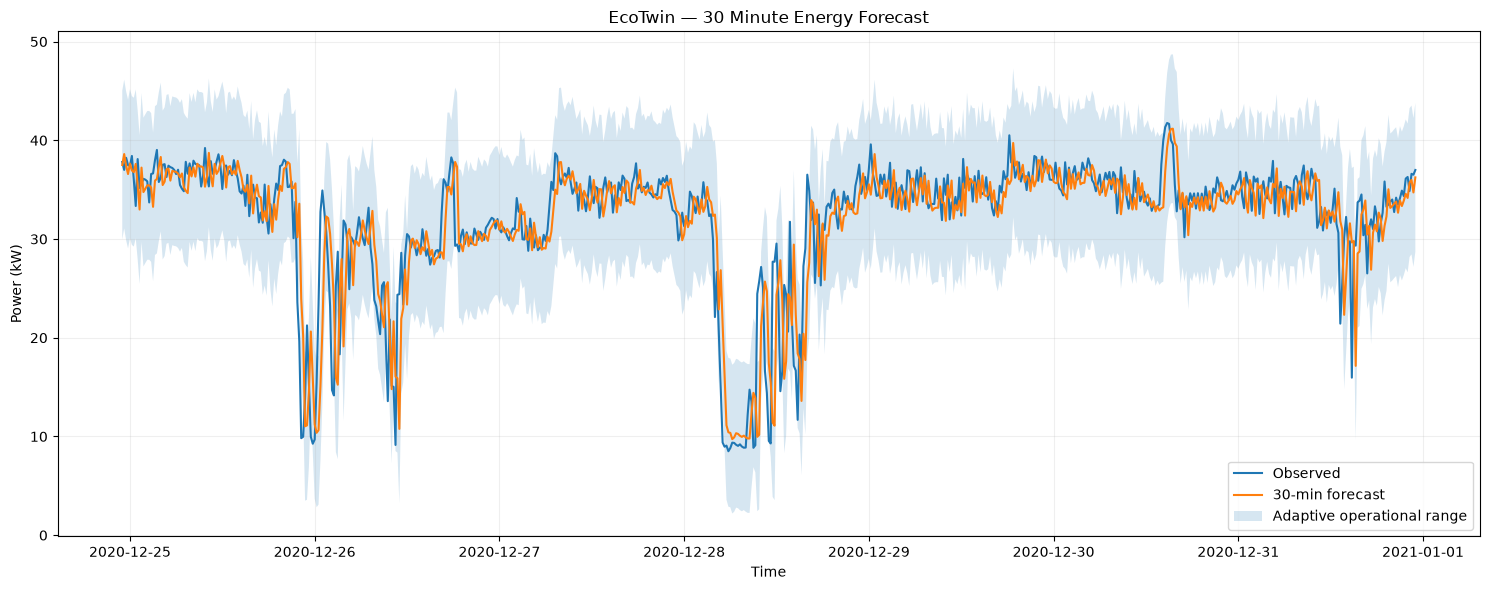

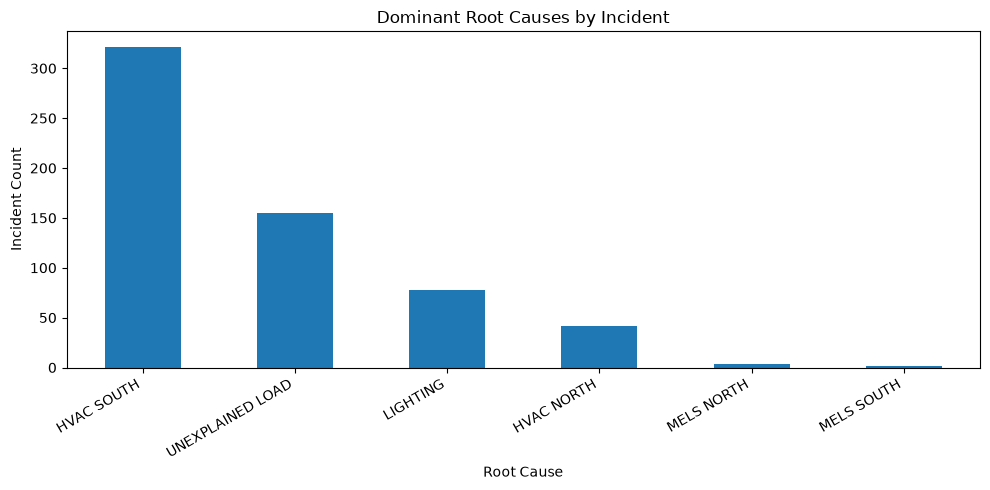

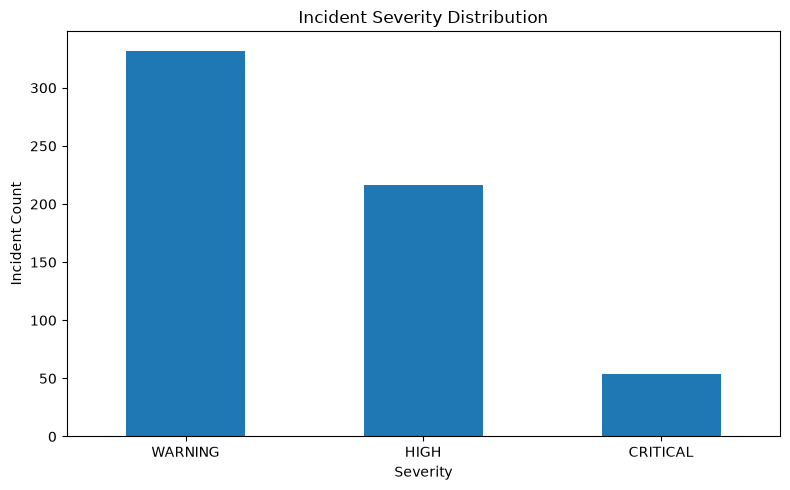


=== ECOTWIN DECISION SUPPORT ===
Diagnosis:
HVAC consumption below expected — South zone

Recommendation:
Check whether the South HVAC system is operating according to schedule and setpoint.

Suggested action:
Review HVAC South operation.

         ECOTWIN SYSTEM COMPLETE

Final summary kaydedildi ✅
Dashboard grafiklerinin tamamı kaydedildi ✅


In [39]:
# ============================================================
# ECOTWIN AI — FINAL SYSTEM DASHBOARD
#
# Forecast
# + Adaptive uncertainty
# + Anomaly detection
# + Incident management
# + Root cause
# + Recommendation
#
# FINAL PROJECT VIEW
# ============================================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, HTML


os.makedirs(
    "reports/dashboard",
    exist_ok=True
)


# ============================================================
# 1. FINAL PROJECT METRICS
# ============================================================

TOTAL_TEST_POINTS = len(test_dates_rc)

TOTAL_ALARM_POINTS = len(incident_source)

TOTAL_INCIDENTS = len(incident_df)

ALARM_RATE = (
    TOTAL_ALARM_POINTS
    / TOTAL_TEST_POINTS
    * 100
)

INCIDENT_REDUCTION = (
    1
    -
    TOTAL_INCIDENTS
    / TOTAL_ALARM_POINTS
) * 100


CRITICAL_INCIDENTS = int(
    (
        incident_df["peak_severity"]
        == "CRITICAL"
    ).sum()
)

HIGH_INCIDENTS = int(
    (
        incident_df["peak_severity"]
        == "HIGH"
    ).sum()
)

WARNING_INCIDENTS = int(
    (
        incident_df["peak_severity"]
        == "WARNING"
    ).sum()
)


EXPLAINED_INCIDENTS = int(
    (
        incident_df[
            "dominant_root_cause"
        ]
        != "UNEXPLAINED LOAD"
    ).sum()
)


STRONG_INCIDENTS = int(
    (
        (
            incident_df[
                "dominant_root_cause"
            ]
            != "UNEXPLAINED LOAD"
        )
        &
        (
            incident_df[
                "mean_attribution_strength"
            ]
            >= 60
        )
    ).sum()
)


STRONG_ATTRIBUTION_RATE = (
    STRONG_INCIDENTS
    / max(
        EXPLAINED_INCIDENTS,
        1
    )
    * 100
)


AVG_INCIDENT_DURATION = float(
    incident_df[
        "duration_minutes"
    ].mean()
)


# ============================================================
# 2. SYSTEM PERFORMANCE
#
# Bunlar daha önce doğruladığımız sonuçlar.
# ============================================================

FORECAST_30_MAE = 2.776
FORECAST_30_RMSE = 4.426
FORECAST_30_HIT_5 = 84.63
FORECAST_30_HIT_10 = 95.58

ANOMALY_VALIDATION_ACCURACY = 81.32
ANOMALY_VALIDATION_PRECISION = 91.92
ANOMALY_VALIDATION_RECALL = 68.68
ANOMALY_VALIDATION_F1 = 78.62

ROOT_CAUSE_BENCHMARK_ACCURACY = 89.75
ROOT_CAUSE_END_TO_END = 68.97


# ============================================================
# 3. HTML DASHBOARD HEADER
# ============================================================

dashboard_html = f"""
<div style="
    font-family: -apple-system, BlinkMacSystemFont,
                 'Segoe UI', sans-serif;
    background:#0b1220;
    color:#f8fafc;
    padding:28px;
    border-radius:18px;
    margin-bottom:25px;
">

    <div style="
        font-size:13px;
        color:#38bdf8;
        font-weight:700;
        letter-spacing:2px;
    ">
        SMART BUILDING DIGITAL TWIN
    </div>

    <div style="
        font-size:34px;
        font-weight:800;
        margin-top:5px;
    ">
        EcoTwin AI
    </div>

    <div style="
        color:#94a3b8;
        margin-top:6px;
        margin-bottom:24px;
    ">
        Adaptive Energy Forecasting,
        Anomaly Intelligence and
        Root-Cause Decision Support
    </div>


    <div style="
        display:grid;
        grid-template-columns:
        repeat(4,1fr);
        gap:12px;
    ">

        <div style="
            background:#111c30;
            padding:18px;
            border-radius:12px;
        ">
            <div style="color:#94a3b8">
                Test observations
            </div>

            <div style="
                font-size:25px;
                font-weight:800;
            ">
                {TOTAL_TEST_POINTS:,}
            </div>
        </div>


        <div style="
            background:#111c30;
            padding:18px;
            border-radius:12px;
        ">
            <div style="color:#94a3b8">
                Alarm rate
            </div>

            <div style="
                font-size:25px;
                font-weight:800;
            ">
                {ALARM_RATE:.2f}%
            </div>
        </div>


        <div style="
            background:#111c30;
            padding:18px;
            border-radius:12px;
        ">
            <div style="color:#94a3b8">
                Energy incidents
            </div>

            <div style="
                font-size:25px;
                font-weight:800;
            ">
                {TOTAL_INCIDENTS}
            </div>
        </div>


        <div style="
            background:#111c30;
            padding:18px;
            border-radius:12px;
        ">
            <div style="color:#94a3b8">
                Strong attribution
            </div>

            <div style="
                font-size:25px;
                font-weight:800;
            ">
                {STRONG_ATTRIBUTION_RATE:.1f}%
            </div>
        </div>

    </div>
</div>
"""

display(
    HTML(
        dashboard_html
    )
)


# ============================================================
# 4. MODEL PERFORMANCE TABLE
# ============================================================

performance_table = pd.DataFrame({

    "Module": [
        "30-min Forecast",
        "30-min Forecast",
        "30-min Forecast",
        "Anomaly Detection*",
        "Anomaly Detection*",
        "Root Cause*",
        "Root Cause*"
    ],

    "Metric": [
        "MAE",
        "RMSE",
        "±10 kW Hit Rate",
        "Precision",
        "F1",
        "Attribution Accuracy",
        "End-to-End Accuracy"
    ],

    "Result": [
        f"{FORECAST_30_MAE:.3f} kW",
        f"{FORECAST_30_RMSE:.3f} kW",
        f"{FORECAST_30_HIT_10:.2f}%",
        f"{ANOMALY_VALIDATION_PRECISION:.2f}%",
        f"{ANOMALY_VALIDATION_F1:.2f}%",
        f"{ROOT_CAUSE_BENCHMARK_ACCURACY:.2f}%",
        f"{ROOT_CAUSE_END_TO_END:.2f}%"
    ]
})


print(
    "=== SYSTEM PERFORMANCE ==="
)

display(
    performance_table
)


print(
    "* Anomaly and root-cause performance "
    "are reported on controlled "
    "semi-synthetic evaluation benchmarks."
)


# ============================================================
# 5. INCIDENT OVERVIEW
# ============================================================

incident_overview = pd.DataFrame({

    "Metric": [
        "Alarm points",
        "Independent incidents",
        "Alarm-to-incident reduction",
        "Warning incidents",
        "High incidents",
        "Critical incidents",
        "Average incident duration",
        "Explained incidents",
        "Strongly attributed incidents"
    ],

    "Value": [
        TOTAL_ALARM_POINTS,
        TOTAL_INCIDENTS,
        f"{INCIDENT_REDUCTION:.2f}%",
        WARNING_INCIDENTS,
        HIGH_INCIDENTS,
        CRITICAL_INCIDENTS,
        f"{AVG_INCIDENT_DURATION:.2f} min",
        EXPLAINED_INCIDENTS,
        STRONG_INCIDENTS
    ]
})


print(
    "\n=== INCIDENT INTELLIGENCE ==="
)

display(
    incident_overview
)


# ============================================================
# 6. FORECAST CHART — LAST 7 DAYS
# ============================================================

dates_plot = pd.to_datetime(
    test_dates_rc
)

end_date = dates_plot[-1]

start_date = (
    end_date
    - pd.Timedelta(days=7)
)

plot_mask = (
    dates_plot >= start_date
)


plot_dates = (
    dates_plot[plot_mask]
)

plot_actual = (
    np.asarray(
        true30_test
    )[plot_mask]
)

plot_forecast = (
    np.asarray(
        center30_test
    )[plot_mask]
)

plot_limit = (
    np.asarray(
        root_thresholds
    )[plot_mask]
)


fig = plt.figure(
    figsize=(15,6)
)

plt.plot(
    plot_dates,
    plot_actual,
    label="Observed"
)

plt.plot(
    plot_dates,
    plot_forecast,
    label="30-min forecast"
)

plt.fill_between(
    plot_dates,
    plot_forecast - plot_limit,
    plot_forecast + plot_limit,
    alpha=0.18,
    label="Adaptive operational range"
)

plt.title(
    "EcoTwin — 30 Minute Energy Forecast"
)

plt.xlabel(
    "Time"
)

plt.ylabel(
    "Power (kW)"
)

plt.legend()

plt.grid(
    alpha=0.2
)

plt.tight_layout()

plt.savefig(
    "reports/dashboard/"
    "forecast_last_7_days.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 7. ROOT CAUSE DISTRIBUTION
# ============================================================

root_counts = (
    incident_df[
        "dominant_root_cause"
    ]
    .value_counts()
)


fig = plt.figure(
    figsize=(10,5)
)

root_counts.plot(
    kind="bar"
)

plt.title(
    "Dominant Root Causes by Incident"
)

plt.xlabel(
    "Root Cause"
)

plt.ylabel(
    "Incident Count"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    "reports/dashboard/"
    "root_cause_distribution.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 8. SEVERITY DISTRIBUTION
# ============================================================

severity_counts = (
    incident_df[
        "peak_severity"
    ]
    .value_counts()
    .reindex(
        [
            "WARNING",
            "HIGH",
            "CRITICAL"
        ],
        fill_value=0
    )
)


fig = plt.figure(
    figsize=(8,5)
)

severity_counts.plot(
    kind="bar"
)

plt.title(
    "Incident Severity Distribution"
)

plt.xlabel(
    "Severity"
)

plt.ylabel(
    "Incident Count"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.savefig(
    "reports/dashboard/"
    "incident_severity.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 9. MOST SEVERE INCIDENT
# ============================================================

most_severe = (
    incident_df
    .sort_values(
        [
            "peak_anomaly_score",
            "duration_minutes"
        ],
        ascending=[
            False,
            False
        ]
    )
    .iloc[0]
)


# Incident'in en ciddi alarm noktasını bul
incident_alarm_rows = (
    incident_source[
        incident_source[
            "incident_id"
        ]
        ==
        most_severe[
            "incident_id"
        ]
    ]
)


peak_alarm = (
    incident_alarm_rows
    .sort_values(
        "anomaly_score",
        ascending=False
    )
    .iloc[0]
)


cause = (
    peak_alarm[
        "root_cause"
    ]
)


strength = (
    peak_alarm[
        "attribution_strength"
    ]
)


if pd.isna(strength):

    strength_text = "N/A"

else:

    strength_text = (
        f"{float(strength):.1f}%"
    )


incident_html = f"""
<div style="
    font-family:-apple-system,
                BlinkMacSystemFont,
                'Segoe UI',
                sans-serif;
    background:#111827;
    color:#f8fafc;
    padding:25px;
    border-radius:16px;
    margin-top:20px;
">

    <div style="
        color:#f87171;
        font-weight:800;
        font-size:13px;
        letter-spacing:1px;
    ">
        INCIDENT #{int(most_severe['incident_id'])}
    </div>

    <h2 style="margin-bottom:5px;">
        {most_severe['peak_severity']} ENERGY INCIDENT
    </h2>

    <div style="
        color:#94a3b8;
        margin-bottom:20px;
    ">
        {most_severe['start_time']}
        →
        {most_severe['end_time']}
    </div>

    <hr style="
        border:none;
        border-top:1px solid #334155;
    ">


    <p>
        <b>Direction:</b>
        {most_severe['direction']}
    </p>

    <p>
        <b>Duration:</b>
        {most_severe['duration_minutes']:.0f} min
    </p>

    <p>
        <b>Peak anomaly score:</b>
        {most_severe['peak_anomaly_score']:.2f}
    </p>

    <p>
        <b>Dominant root cause:</b>
        {most_severe['dominant_root_cause']}
    </p>

    <p>
        <b>Attribution strength:</b>
        {strength_text}
    </p>

    <p>
        <b>Forecast:</b>
        {peak_alarm['forecast_kw']:.1f} kW
    </p>

    <p>
        <b>Observed:</b>
        {peak_alarm['observed_kw']:.1f} kW
    </p>

    <p>
        <b>Deviation:</b>
        {peak_alarm['residual_kw']:+.1f} kW
    </p>

</div>
"""


display(
    HTML(
        incident_html
    )
)


# ============================================================
# 10. ATTACH RECOMMENDATION
# ============================================================

matching_rec = (
    recommendation_df[
        pd.to_datetime(
            recommendation_df[
                "alarm_time"
            ]
        )
        ==
        pd.Timestamp(
            peak_alarm[
                "alarm_time"
            ]
        )
    ]
)


if len(matching_rec) > 0:

    rec = matching_rec.iloc[0]

    print(
        "\n=== ECOTWIN DECISION SUPPORT ==="
    )

    print(
        "Diagnosis:"
    )

    print(
        rec[
            "title"
        ]
    )

    print(
        "\nRecommendation:"
    )

    print(
        rec[
            "recommendation"
        ]
    )

    print(
        "\nSuggested action:"
    )

    print(
        rec[
            "action"
        ]
    )


# ============================================================
# 11. FINAL PROJECT SUMMARY
# ============================================================

final_summary = {

    "project":
    "EcoTwin AI",

    "test_observations":
    int(
        TOTAL_TEST_POINTS
    ),

    "alarm_points":
    int(
        TOTAL_ALARM_POINTS
    ),

    "alarm_rate_percent":
    round(
        ALARM_RATE,
        2
    ),

    "independent_incidents":
    int(
        TOTAL_INCIDENTS
    ),

    "incident_reduction_percent":
    round(
        INCIDENT_REDUCTION,
        2
    ),

    "critical_incidents":
    int(
        CRITICAL_INCIDENTS
    ),

    "strong_attribution_rate_percent":
    round(
        STRONG_ATTRIBUTION_RATE,
        2
    ),

    "forecast_30m_mae_kw":
    FORECAST_30_MAE,

    "forecast_30m_rmse_kw":
    FORECAST_30_RMSE,

    "forecast_30m_10kw_hit_rate":
    FORECAST_30_HIT_10,

    "anomaly_benchmark_f1":
    ANOMALY_VALIDATION_F1,

    "root_cause_benchmark_accuracy":
    ROOT_CAUSE_BENCHMARK_ACCURACY,

    "evaluation_note":
    (
        "Anomaly and root-cause classification "
        "metrics use controlled semi-synthetic "
        "benchmark anomalies."
    )
}


with open(
    "reports/ecotwin_final_summary.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        final_summary,
        f,
        ensure_ascii=False,
        indent=4
    )


pd.DataFrame(
    [final_summary]
).to_csv(
    "reports/ecotwin_final_summary.csv",
    index=False
)


print(
    "\n=========================================="
)

print(
    "         ECOTWIN SYSTEM COMPLETE"
)

print(
    "=========================================="
)

print(
    "\nFinal summary kaydedildi ✅"
)

print(
    "Dashboard grafiklerinin tamamı kaydedildi ✅"
)

In [40]:
# ============================================================
# FIND ALL KERAS MODELS IN 01 NOTEBOOK MEMORY
# ============================================================

import tensorflow as tf

print("=" * 70)
print("KERAS MODEL DISCOVERY — 01 NOTEBOOK")
print("=" * 70)

found_models = []

for name, obj in list(globals().items()):

    try:
        if isinstance(obj, tf.keras.Model):
            found_models.append((name, obj))
    except:
        pass


if len(found_models) == 0:

    print("\nRAM'de Keras model bulunamadı.")

else:

    for name, model in found_models:

        print("\n-----------------------------------")
        print("Variable:", name)

        try:
            print("Input:", model.input_shape)
        except:
            print("Input: okunamadı")

        try:
            print("Output:", model.output_shape)
        except:
            print("Output: okunamadı")

        try:
            print(
                "Parameters:",
                f"{model.count_params():,}"
            )
        except:
            pass

        print("Layers:")

        for layer in model.layers:
            print(
                " -",
                layer.__class__.__name__,
                "|",
                layer.name
            )


print(
    "\nToplam Keras model:",
    len(found_models)
)

KERAS MODEL DISCOVERY — 01 NOTEBOOK

-----------------------------------
Variable: model_lstm
Input: (None, 8, 6)
Output: (None, 2)
Parameters: 31,714
Layers:
 - LSTM | lstm
 - Dropout | dropout
 - LSTM | lstm_1
 - Dropout | dropout_1
 - Dense | dense
 - Dense | dense_1

-----------------------------------
Variable: model_30_gate
Input: (None, 16, 23)
Output: (None, 1)
Parameters: 24,641
Layers:
 - LSTM | lstm
 - Dropout | dropout
 - Dense | dense
 - Dropout | dropout_1
 - Dense | dense_1

-----------------------------------
Variable: model_60_gate
Input: (None, 16, 23)
Output: (None, 1)
Parameters: 24,641
Layers:
 - LSTM | lstm
 - Dropout | dropout
 - Dense | dense
 - Dropout | dropout_1
 - Dense | dense_1

-----------------------------------
Variable: final_model_30
Input: (None, 16, 23)
Output: (None, 1)
Parameters: 24,641
Layers:
 - LSTM | lstm
 - Dropout | dropout
 - Dense | dense
 - Dropout | dropout_1
 - Dense | dense_1

-----------------------------------
Variable: final_model_

In [41]:
# ============================================================
# ECOTWIN FINAL 30M MODEL — DEPENDENCY AUDIT
# ============================================================

import numpy as np

print("=" * 70)
print("ECOTWIN FINAL 30M MODEL — DEPENDENCY AUDIT")
print("=" * 70)


# ============================================================
# 1. MODEL IDENTITY
# ============================================================

print("\n=== MODEL IDENTITY ===")

print(
    "model_30_gate is final_model_30:",
    model_30_gate is final_model_30
)


try:

    weights_equal = all(
        np.allclose(w1, w2)
        for w1, w2 in zip(
            model_30_gate.get_weights(),
            final_model_30.get_weights()
        )
    )

    print(
        "Weights identical:",
        weights_equal
    )

except Exception as e:

    print(
        "Weight comparison error:",
        e
    )


print(
    "Final 30 input:",
    final_model_30.input_shape
)

print(
    "Final 30 output:",
    final_model_30.output_shape
)


# ============================================================
# 2. FIND FEATURE LIST CANDIDATES
# ============================================================

print("\n=== FEATURE LIST CANDIDATES ===")

feature_candidates = []

for name, obj in list(globals().items()):

    try:

        if (
            isinstance(obj, (list, tuple))
            and len(obj) > 0
            and all(
                isinstance(x, str)
                for x in obj
            )
        ):

            if (
                "feature" in name.lower()
                or len(obj) == 23
            ):

                feature_candidates.append(
                    (name, obj)
                )

    except:
        pass


for name, features in feature_candidates:

    print(
        f"\nVariable: {name}"
    )

    print(
        "Count:",
        len(features)
    )

    print(
        features
    )


# ============================================================
# 3. FIND SCALERS
# ============================================================

print("\n=== SCALER CANDIDATES ===")

for name, obj in list(globals().items()):

    try:

        if (
            hasattr(obj, "transform")
            and hasattr(obj, "fit")
            and (
                "scaler" in name.lower()
                or
                "scale" in name.lower()
            )
        ):

            print(
                f"\nVariable: {name}"
            )

            print(
                "Type:",
                type(obj).__name__
            )

            print(
                "n_features_in_:",
                getattr(
                    obj,
                    "n_features_in_",
                    "N/A"
                )
            )

    except:
        pass


# ============================================================
# 4. FIND GATE / LAMBDA VARIABLES
# ============================================================

print("\n=== GATE / LAMBDA CANDIDATES ===")

for name, obj in list(globals().items()):

    lower_name = name.lower()

    if (
        "lambda" in lower_name
        or
        "gate" in lower_name
    ):

        if isinstance(
            obj,
            (
                int,
                float,
                np.integer,
                np.floating
            )
        ):

            print(
                f"{name} = {obj}"
            )


# ============================================================
# 5. FIND 30M / RESIDUAL VARIABLES
# ============================================================

print("\n=== IMPORTANT 30M VARIABLES ===")

keywords = [
    "30",
    "resid",
    "gate",
    "lambda",
    "feature",
    "scaler"
]


for name, obj in sorted(
    list(globals().items()),
    key=lambda x: x[0]
):

    lower_name = name.lower()

    if any(
        keyword in lower_name
        for keyword in keywords
    ):

        # Çok büyük objeleri yazdırmıyoruz.
        if isinstance(
            obj,
            np.ndarray
        ):

            print(
                f"{name}: ndarray "
                f"shape={obj.shape}"
            )

        elif hasattr(
            obj,
            "shape"
        ):

            try:
                print(
                    f"{name}: "
                    f"{type(obj).__name__} "
                    f"shape={obj.shape}"
                )
            except:
                pass


print("\nAudit complete ✅")

ECOTWIN FINAL 30M MODEL — DEPENDENCY AUDIT

=== MODEL IDENTITY ===
model_30_gate is final_model_30: True
Weights identical: True
Final 30 input: (None, 16, 23)
Final 30 output: (None, 1)

=== FEATURE LIST CANDIDATES ===

Variable: lstm_features
Count: 6
['total_power', 'indoor_temp_avg', 'outdoor_temp_avg', 'relative_humidity_set_1', 'solar_radiation_set_1', 'dew_point_temperature_set_1d']

Variable: context_features
Count: 11
['indoor_temp_avg', 'outdoor_temp_avg', 'relative_humidity_set_1', 'solar_radiation_set_1', 'dew_point_temperature_set_1d', 'time_sin', 'time_cos', 'dow_sin', 'dow_cos', 'month', 'is_weekend']

Variable: enhanced_features
Count: 23
['total_power', 'hvac_N', 'hvac_S', 'hvac_total', 'mels_N', 'mels_S', 'lig_S', 'indoor_temp_avg', 'outdoor_temp_avg', 'relative_humidity_set_1', 'solar_radiation_set_1', 'dew_point_temperature_set_1d', 'power_lag_15m', 'power_lag_60m', 'power_lag_24h', 'power_lag_7d', 'power_delta_15m', 'power_delta_60m', 'time_sin', 'time_cos', 'dow_s

In [42]:
# ============================================================
# ECOTWIN FINAL 30M — REPRODUCIBILITY CHECK
#
# Amaç:
# 1) Doğru X test tensorunu bulmak
# 2) y30_scaler residual scaler mı doğrulamak
# 3) Kaydedilecek bütün bağımlılıkları kesinleştirmek
# ============================================================

import numpy as np

print("=" * 70)
print("ECOTWIN FINAL 30M — REPRODUCIBILITY CHECK")
print("=" * 70)


# ============================================================
# 1. FIND 16x23 MODEL INPUT ARRAYS
# ============================================================

print("\n=== 16 x 23 INPUT CANDIDATES ===")

input_candidates = []

for name, obj in list(globals().items()):

    if isinstance(obj, np.ndarray):

        if (
            obj.ndim == 3
            and obj.shape[1] == 16
            and obj.shape[2] == 23
        ):

            input_candidates.append(
                (name, obj.shape)
            )

            print(
                f"{name}: {obj.shape}"
            )


# ============================================================
# 2. CHECK OUTPUT SCALER
# ============================================================

print("\n=== Y30 SCALER CHECK ===")

try:

    reconstructed_residual = (
        y30_scaler
        .inverse_transform(
            pred30_test_scaled
        )
        .reshape(-1)
    )

    residual_diff = np.abs(
        reconstructed_residual
        -
        pred30_test_residual
    )

    print(
        "Max difference:",
        residual_diff.max()
    )

    print(
        "Mean difference:",
        residual_diff.mean()
    )

    if np.allclose(
        reconstructed_residual,
        pred30_test_residual,
        atol=1e-5
    ):

        print(
            "y30_scaler = residual output scaler ✅"
        )

    else:

        print(
            "y30_scaler residual scaler ile eşleşmiyor ❌"
        )

except Exception as e:

    print(
        "Scaler check error:",
        e
    )


# ============================================================
# 3. VERIFY GATED FORECAST FORMULA
# ============================================================

print("\n=== GATED FORECAST FORMULA CHECK ===")

try:

    reconstructed_gated = (
        persistence30_test
        +
        lambda_30
        *
        pred30_test_residual
    )

    gated_difference = np.abs(
        reconstructed_gated
        -
        gated30_test
    )

    print(
        "Max difference:",
        gated_difference.max()
    )

    print(
        "Mean difference:",
        gated_difference.mean()
    )

    if np.allclose(
        reconstructed_gated,
        gated30_test,
        atol=1e-5
    ):

        print(
            "Final formula confirmed ✅"
        )

        print(
            "forecast = persistence "
            "+ 0.42 × LSTM residual"
        )

    else:

        print(
            "Stored gated forecast farklı görünüyor ❌"
        )

except Exception as e:

    print(
        "Formula check error:",
        e
    )


# ============================================================
# 4. VERIFY FINAL CENTER
# ============================================================

print("\n=== FINAL CENTER CHECK ===")

try:

    center_difference = np.abs(
        center30_test
        -
        gated30_test
    )

    print(
        "Max difference:",
        center_difference.max()
    )

    print(
        "Mean difference:",
        center_difference.mean()
    )

    if np.allclose(
        center30_test,
        gated30_test,
        atol=1e-5
    ):

        print(
            "center30_test = gated30_test ✅"
        )

    else:

        print(
            "center30_test farklı bir işlem içeriyor."
        )

except Exception as e:

    print(
        "Center check error:",
        e
    )


# ============================================================
# 5. FINAL DEPENDENCY SUMMARY
# ============================================================

print("\n=== FINAL MODEL DEPENDENCIES ===")

print(
    "Model variable:",
    "final_model_30"
)

print(
    "X scaler:",
    "enh_x_scaler"
)

print(
    "Y/residual scaler:",
    "y30_scaler"
)

print(
    "Feature list:",
    "enhanced_features"
)

print(
    "Window:",
    "16 timesteps = 4 hours"
)

print(
    "Forecast horizon:",
    "30 minutes"
)

print(
    "Gate lambda:",
    lambda_30
)

print("\nReproducibility audit complete ✅")

ECOTWIN FINAL 30M — REPRODUCIBILITY CHECK

=== 16 x 23 INPUT CANDIDATES ===
Xtr: (61704, 16, 23)
Xv: (13222, 16, 23)
Xt: (13223, 16, 23)

=== Y30 SCALER CHECK ===
Max difference: 0.0
Mean difference: 0.0
y30_scaler = residual output scaler ✅

=== GATED FORECAST FORMULA CHECK ===
Max difference: 0.0
Mean difference: 0.0
Final formula confirmed ✅
forecast = persistence + 0.42 × LSTM residual

=== FINAL CENTER CHECK ===
Max difference: 0.0
Mean difference: 0.0
center30_test = gated30_test ✅

=== FINAL MODEL DEPENDENCIES ===
Model variable: final_model_30
X scaler: enh_x_scaler
Y/residual scaler: y30_scaler
Feature list: enhanced_features
Window: 16 timesteps = 4 hours
Forecast horizon: 30 minutes
Gate lambda: 0.42

Reproducibility audit complete ✅


In [43]:
# ============================================================
# ECOTWIN AI — EXPORT FINAL PRODUCTION ARTIFACTS
# ============================================================

from pathlib import Path
import json
import joblib
import hashlib
import tensorflow as tf
import numpy as np


# ============================================================
# PATHS
# ============================================================

PROJECT_ROOT = Path.cwd()
MODEL_DIR = PROJECT_ROOT / "models"

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)


MODEL_PATH = (
    MODEL_DIR
    / "ecotwin_30m_residual_lstm.keras"
)

X_SCALER_PATH = (
    MODEL_DIR
    / "ecotwin_30m_x_scaler.pkl"
)

Y_SCALER_PATH = (
    MODEL_DIR
    / "ecotwin_30m_residual_scaler.pkl"
)

FEATURE_PATH = (
    MODEL_DIR
    / "ecotwin_30m_features.json"
)

CONFIG_PATH = (
    MODEL_DIR
    / "ecotwin_forecast_config.json"
)

MANIFEST_PATH = (
    MODEL_DIR
    / "ecotwin_model_manifest.json"
)


print("=" * 70)
print("ECOTWIN AI — FINAL MODEL EXPORT")
print("=" * 70)


# ============================================================
# 1. SAVE FINAL 30M LSTM
# ============================================================

final_model_30.save(
    MODEL_PATH
)

print(
    "\nFinal 30m residual LSTM kaydedildi ✅"
)


# ============================================================
# 2. SAVE SCALERS
# ============================================================

joblib.dump(
    enh_x_scaler,
    X_SCALER_PATH
)

joblib.dump(
    y30_scaler,
    Y_SCALER_PATH
)

print(
    "23-feature X scaler kaydedildi ✅"
)

print(
    "Residual output scaler kaydedildi ✅"
)


# ============================================================
# 3. SAVE FEATURE CONTRACT
# ============================================================

with open(
    FEATURE_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        list(enhanced_features),
        f,
        ensure_ascii=False,
        indent=4
    )


print(
    "23-feature listesi kaydedildi ✅"
)


# ============================================================
# 4. FINAL FORECAST CONFIG
# ============================================================

forecast_config = {

    "project":
        "EcoTwin AI",

    "version":
        "1.0.0",

    "forecast_30m": {

        "method":
            "gated_residual_lstm",

        "horizon_minutes":
            30,

        "sampling_interval_minutes":
            15,

        "history_timesteps":
            16,

        "history_hours":
            4,

        "feature_count":
            len(enhanced_features),

        "gate_lambda":
            float(lambda_30),

        "baseline":
            "persistence",

        "formula":
            (
                "forecast = persistence "
                "+ gate_lambda * predicted_residual"
            ),

        "model_file":
            MODEL_PATH.name,

        "x_scaler_file":
            X_SCALER_PATH.name,

        "residual_scaler_file":
            Y_SCALER_PATH.name,

        "features_file":
            FEATURE_PATH.name
    },

    "forecast_60m": {

        "method":
            "persistence",

        "horizon_minutes":
            60,

        "reason":
            (
                "Persistence retained because "
                "gated AI did not improve final MAE."
            )
    },

    "final_evaluation": {

        "test_observations":
            13223,

        "forecast_30m_mae_kw":
            2.776,

        "forecast_30m_rmse_kw":
            4.426,

        "forecast_30m_within_5kw_percent":
            84.63,

        "forecast_30m_within_10kw_percent":
            95.58,

        "forecast_60m_mae_kw":
            3.457
    }
}


with open(
    CONFIG_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        forecast_config,
        f,
        ensure_ascii=False,
        indent=4
    )


print(
    "Forecast config kaydedildi ✅"
)


# ============================================================
# 5. SHA256 FILE HASHES
#
# GitHub / reproducibility için hangi dosyanın
# kullanıldığını kesin olarak takip eder.
# ============================================================

def sha256_file(path):

    sha = hashlib.sha256()

    with open(
        path,
        "rb"
    ) as f:

        for chunk in iter(
            lambda: f.read(1024 * 1024),
            b""
        ):
            sha.update(chunk)

    return sha.hexdigest()


artifact_paths = [
    MODEL_PATH,
    X_SCALER_PATH,
    Y_SCALER_PATH,
    FEATURE_PATH,
    CONFIG_PATH
]


artifact_hashes = {}

for path in artifact_paths:

    artifact_hashes[
        path.name
    ] = sha256_file(
        path
    )


# ============================================================
# 6. MODEL MANIFEST
# ============================================================

manifest = {

    "project":
        "EcoTwin AI",

    "release":
        "v1.0.0",

    "production_forecast":
        "30-minute gated residual LSTM",

    "input_shape":
        [
            16,
            23
        ],

    "output_shape":
        [
            1
        ],

    "parameters":
        int(
            final_model_30.count_params()
        ),

    "features":
        list(
            enhanced_features
        ),

    "gate_lambda":
        float(
            lambda_30
        ),

    "artifacts_sha256":
        artifact_hashes
}


with open(
    MANIFEST_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        manifest,
        f,
        ensure_ascii=False,
        indent=4
    )


print(
    "Model manifest + SHA256 kaydedildi ✅"
)


# ============================================================
# 7. EXPORT AUDIT
# ============================================================

print(
    "\n=== FINAL PRODUCTION ARTIFACTS ==="
)


for path in sorted(
    MODEL_DIR.glob(
        "ecotwin_*"
    )
):

    if path.is_file():

        print(
            path.name,
            "|",
            f"{path.stat().st_size / 1024:.2f} KB"
        )


print(
    "\n======================================="
)

print(
    "ECOTWIN FORECAST MODEL LOCKED ✅"
)

print(
    "======================================="
)

ECOTWIN AI — FINAL MODEL EXPORT

Final 30m residual LSTM kaydedildi ✅
23-feature X scaler kaydedildi ✅
Residual output scaler kaydedildi ✅
23-feature listesi kaydedildi ✅
Forecast config kaydedildi ✅
Model manifest + SHA256 kaydedildi ✅

=== FINAL PRODUCTION ARTIFACTS ===
ecotwin_30m_features.json | 0.45 KB
ecotwin_30m_residual_lstm.keras | 321.63 KB
ecotwin_30m_residual_scaler.pkl | 0.58 KB
ecotwin_30m_x_scaler.pkl | 1.09 KB
ecotwin_forecast_config.json | 1.10 KB
ecotwin_model_manifest.json | 1.37 KB

ECOTWIN FORECAST MODEL LOCKED ✅


In [44]:
# ============================================================
# ECOTWIN — CREATE PRODUCTION SMOKE TEST FIXTURE
#
# Amaç:
# Kaydedilen modeli daha sonra sıfırdan yüklediğimizde
# aynı çıktıyı üretip üretmediğini doğrulamak.
# ============================================================

from pathlib import Path
import numpy as np
import json

PROJECT_ROOT = Path.cwd()

TEST_DIR = PROJECT_ROOT / "tests" / "fixtures"
TEST_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIXTURE_PATH = (
    TEST_DIR
    / "ecotwin_30m_smoke_test.npz"
)


# Test setinin ortalarından sabit bir örnek seçiyoruz.
sample_idx = 5000


# Modelin gerçekten kullandığı 16x23 giriş
sample_input = Xt[
    sample_idx:sample_idx + 1
].copy()


# Gerçek LSTM residual prediction
sample_scaled_prediction = (
    final_model_30.predict(
        sample_input,
        verbose=0
    )
)


sample_residual_prediction = (
    y30_scaler
    .inverse_transform(
        sample_scaled_prediction
    )
    .reshape(-1)[0]
)


# Persistence baseline
sample_persistence = float(
    persistence30_test[
        sample_idx
    ]
)


# Final gated forecast
sample_final_forecast = (
    sample_persistence
    +
    float(lambda_30)
    *
    float(sample_residual_prediction)
)


# Notebook'ta daha önce hesaplanmış final çıktı
stored_final_forecast = float(
    gated30_test[
        sample_idx
    ]
)


# Gerçek gelecek değer
sample_actual = float(
    true30_test[
        sample_idx
    ]
)


np.savez(
    FIXTURE_PATH,

    model_input=
        sample_input,

    persistence=
        sample_persistence,

    expected_residual=
        float(
            sample_residual_prediction
        ),

    expected_forecast=
        stored_final_forecast,

    actual=
        sample_actual
)


print("=" * 65)
print("ECOTWIN PRODUCTION SMOKE TEST FIXTURE")
print("=" * 65)

print(
    "\nSample index:",
    sample_idx
)

print(
    "Input shape:",
    sample_input.shape
)

print(
    "Persistence:",
    round(
        sample_persistence,
        6
    )
)

print(
    "Residual prediction:",
    round(
        float(
            sample_residual_prediction
        ),
        6
    )
)

print(
    "Reconstructed forecast:",
    round(
        sample_final_forecast,
        6
    )
)

print(
    "Stored forecast:",
    round(
        stored_final_forecast,
        6
    )
)

print(
    "Actual:",
    round(
        sample_actual,
        6
    )
)


difference = abs(
    sample_final_forecast
    -
    stored_final_forecast
)


print(
    "\nDifference:",
    difference
)


if difference < 1e-5:

    print(
        "Smoke-test fixture oluşturuldu ✅"
    )

else:

    print(
        "UYARI: Forecast uyuşmazlığı ❌"
    )


print(
    "\nSaved:"
)

print(
    FIXTURE_PATH
)

ECOTWIN PRODUCTION SMOKE TEST FIXTURE

Sample index: 5000
Input shape: (1, 16, 23)
Persistence: 34.905365
Residual prediction: -0.61465
Reconstructed forecast: 34.647212
Stored forecast: 34.647213
Actual: 33.852322

Difference: 1.021623610597544e-06
Smoke-test fixture oluşturuldu ✅

Saved:
/Users/muhammedmusaalver/Documents/EcoTwinAI/tests/fixtures/ecotwin_30m_smoke_test.npz


In [45]:
# ============================================================
# ECOTWIN — FINAL ANOMALY / UNCERTAINTY AUDIT
#
# Final anomaly engine'in RAM'deki gerçek
# değişkenlerini kesin olarak tespit ediyoruz.
# ============================================================

import numpy as np

print("=" * 70)
print("ECOTWIN FINAL ANOMALY ENGINE — AUDIT")
print("=" * 70)


# ============================================================
# 1. ROOT / ANOMALY ARRAYS
# ============================================================

candidate_names = [
    "root_thresholds",
    "root_alarm_flags",
    "root_anomaly_score",
    "test_error30_final",
    "val_error30_final",
    "center30_test",
    "true30_test",
    "margin30",
]

print("\n=== CORE VARIABLES ===")

for name in candidate_names:

    if name in globals():

        obj = globals()[name]

        if isinstance(obj, np.ndarray):

            print(
                f"{name}: "
                f"shape={obj.shape}, "
                f"dtype={obj.dtype}"
            )

        else:

            print(
                f"{name}: "
                f"type={type(obj).__name__}"
            )

    else:

        print(
            f"{name}: NOT FOUND"
        )


# ============================================================
# 2. FINAL COVERAGE / THRESHOLD VARIABLES
# ============================================================

print("\n=== COVERAGE / THRESHOLD CANDIDATES ===")

for name, obj in sorted(
    list(globals().items()),
    key=lambda x: x[0]
):

    lname = name.lower()

    if (
        "coverage" in lname
        or
        "threshold" in lname
        or
        "alarm_rate" in lname
    ):

        if isinstance(
            obj,
            (
                int,
                float,
                np.integer,
                np.floating
            )
        ):

            print(
                f"{name} = {obj}"
            )


# ============================================================
# 3. VERIFY OPERATIONAL ALARM RATE
# ============================================================

print("\n=== OPERATIONAL CHECK ===")

if (
    "root_alarm_flags" in globals()
    and
    "root_thresholds" in globals()
):

    alarm_count = int(
        np.sum(root_alarm_flags)
    )

    alarm_rate = (
        np.mean(root_alarm_flags)
        * 100
    )

    print(
        "Alarm count:",
        alarm_count
    )

    print(
        "Alarm rate:",
        round(alarm_rate, 4),
        "%"
    )

    print(
        "Median threshold:",
        round(
            float(
                np.median(
                    root_thresholds
                )
            ),
            4
        ),
        "kW"
    )

    print(
        "Mean threshold:",
        round(
            float(
                np.mean(
                    root_thresholds
                )
            ),
            4
        ),
        "kW"
    )


# ============================================================
# 4. VERIFY ANOMALY SCORE FORMULA
# ============================================================

print("\n=== ANOMALY SCORE CHECK ===")

if all(
    name in globals()
    for name in [
        "test_error30_final",
        "root_thresholds",
        "root_anomaly_score"
    ]
):

    reconstructed_score = (
        np.abs(
            test_error30_final
        )
        /
        root_thresholds
    )

    score_diff = np.abs(
        reconstructed_score
        -
        root_anomaly_score
    )

    print(
        "Max score difference:",
        score_diff.max()
    )

    print(
        "Mean score difference:",
        score_diff.mean()
    )

    if np.allclose(
        reconstructed_score,
        root_anomaly_score,
        atol=1e-6
    ):

        print(
            "Anomaly score formula confirmed ✅"
        )

    else:

        print(
            "Anomaly score formula differs ❌"
        )


print("\nAnomaly audit complete ✅")

ECOTWIN FINAL ANOMALY ENGINE — AUDIT

=== CORE VARIABLES ===
root_thresholds: shape=(13223,), dtype=float64
root_alarm_flags: shape=(13223,), dtype=int64
root_anomaly_score: shape=(13223,), dtype=float64
test_error30_final: shape=(13223,), dtype=float32
val_error30_final: shape=(13222,), dtype=float32
center30_test: shape=(13223,), dtype=float32
true30_test: shape=(13223,), dtype=float32
margin30: shape=(13223,), dtype=float64

=== COVERAGE / THRESHOLD CANDIDATES ===
ALARM_RATE = 6.7004461922407925
ANOMALY_COVERAGE = 0.975
FINAL_ANOMALY_COVERAGE = 0.96
FINAL_COVERAGE = 0.96
MIN_THRESHOLD = 1.0
TARGET_COVERAGE = 0.9
alarm_rate = 6.7004461922407925
anomaly_threshold = -0.054370520883966544
coverage = 0.99
coverage30_final = 90.14595780080164
coverage60_final = 90.02495651516297
coverage_30 = 85.73338023214913
coverage_30_adaptive = 89.44073162152655
coverage_60 = 86.2258177981006
coverage_60_adaptive = 89.47590573338023
old_threshold = 7.536502838134766
reference_false_alarm_rate = 4.446

In [46]:
# ============================================================
# ECOTWIN — ADAPTIVE THRESHOLD ENGINE DISCOVERY
#
# Amaç:
# root_thresholds dizisinin hangi geçmiş veri / ayar /
# fonksiyonlarla üretildiğini kesinleştirmek.
# ============================================================

import inspect
import numpy as np
import pandas as pd


print("=" * 70)
print("ECOTWIN — ADAPTIVE THRESHOLD ENGINE DISCOVERY")
print("=" * 70)


# ============================================================
# 1. THRESHOLD BEHAVIOR
# ============================================================

print("\n=== ROOT THRESHOLD BEHAVIOR ===")

rt = np.asarray(
    root_thresholds,
    dtype=float
)

print("Shape:", rt.shape)

print(
    "Min:",
    round(float(np.min(rt)), 4)
)

print(
    "Median:",
    round(float(np.median(rt)), 4)
)

print(
    "Mean:",
    round(float(np.mean(rt)), 4)
)

print(
    "Max:",
    round(float(np.max(rt)), 4)
)

print(
    "Std:",
    round(float(np.std(rt)), 4)
)

print(
    "Unique rounded values:",
    len(
        np.unique(
            np.round(rt, 4)
        )
    )
)

print(
    "\nFirst 10 thresholds:"
)

print(
    np.round(
        rt[:10],
        4
    )
)

print(
    "\nLast 10 thresholds:"
)

print(
    np.round(
        rt[-10:],
        4
    )
)


# ============================================================
# 2. SEARCH IMPORTANT SCALAR SETTINGS
# ============================================================

print("\n=== POSSIBLE ADAPTIVE SETTINGS ===")

keywords = [
    "window",
    "coverage",
    "quantile",
    "alpha",
    "history",
    "lookback",
    "minimum",
    "min_",
    "delay",
    "threshold",
    "conformal"
]


for name, obj in sorted(
    list(globals().items()),
    key=lambda x: x[0]
):

    lname = name.lower()

    if any(
        key in lname
        for key in keywords
    ):

        if isinstance(
            obj,
            (
                int,
                float,
                np.integer,
                np.floating,
                str
            )
        ):

            print(
                f"{name} = {obj}"
            )


# ============================================================
# 3. SEARCH RELEVANT ARRAYS / SERIES
# ============================================================

print("\n=== POSSIBLE CALIBRATION ARRAYS ===")

array_keywords = [
    "error",
    "resid",
    "threshold",
    "margin",
    "quantile",
    "history",
    "conformal"
]


for name, obj in sorted(
    list(globals().items()),
    key=lambda x: x[0]
):

    lname = name.lower()

    if any(
        key in lname
        for key in array_keywords
    ):

        if isinstance(
            obj,
            np.ndarray
        ):

            print(
                f"{name}: ndarray "
                f"shape={obj.shape}"
            )

        elif isinstance(
            obj,
            (
                pd.Series,
                pd.DataFrame
            )
        ):

            print(
                f"{name}: "
                f"{type(obj).__name__} "
                f"shape={obj.shape}"
            )


# ============================================================
# 4. FIND RELEVANT FUNCTIONS
# ============================================================

print("\n=== POSSIBLE THRESHOLD FUNCTIONS ===")

function_candidates = []

for name, obj in list(
    globals().items()
):

    if callable(obj):

        lname = name.lower()

        if any(
            key in lname
            for key in [
                "threshold",
                "conformal",
                "adaptive",
                "margin",
                "anomaly"
            ]
        ):

            function_candidates.append(
                (
                    name,
                    obj
                )
            )

            print(
                "\nFunction:",
                name
            )


# ============================================================
# 5. TRY TO PRINT FUNCTION SOURCE
# ============================================================

print("\n=== FUNCTION SOURCE ===")

for name, func in function_candidates:

    print(
        "\n" + "-" * 60
    )

    print(
        "FUNCTION:",
        name
    )

    try:

        source = inspect.getsource(
            func
        )

        print(
            source[:5000]
        )

    except Exception as e:

        print(
            "Source unavailable:",
            e
        )


print(
    "\nAdaptive threshold discovery complete ✅"
)

ECOTWIN — ADAPTIVE THRESHOLD ENGINE DISCOVERY

=== ROOT THRESHOLD BEHAVIOR ===
Shape: (13223,)
Min: 7.5365
Median: 8.2684
Mean: 8.1761
Max: 8.2684
Std: 0.2298
Unique rounded values: 32

First 10 thresholds:
[8.2684 8.2684 8.2684 8.2684 8.2684 8.2684 8.2684 8.2684 8.2684 8.2684]

Last 10 thresholds:
[7.5365 7.5365 7.5365 7.5365 7.5365 7.5365 7.5365 7.5365 7.5365 7.5365]

=== POSSIBLE ADAPTIVE SETTINGS ===
ALPHA = 0.09999999999999998
ANOMALY_ALPHA = 0.025000000000000022
ANOMALY_COVERAGE = 0.975
FINAL_ANOMALY_COVERAGE = 0.96
FINAL_COVERAGE = 0.96
MIN_PERIODS = 96
MIN_THRESHOLD = 1.0
ROLLING_WINDOW = 672
ROOT_CAUSE_WINDOW_DAYS = 28
TARGET_COVERAGE = 0.9
alpha = 0.09999999999999998
anomaly_threshold = -0.054370520883966544
coverage = 0.99
coverage30_final = 90.14595780080164
coverage60_final = 90.02495651516297
coverage_30 = 85.73338023214913
coverage_30_adaptive = 89.44073162152655
coverage_60 = 86.2258177981006
coverage_60_adaptive = 89.47590573338023
history_error = 0.6175003051757812
hi

In [47]:
# ============================================================
# ECOTWIN — FINAL ADAPTIVE SETTINGS CHECK
# ============================================================

import numpy as np

print("=" * 65)
print("ECOTWIN — FINAL ADAPTIVE SETTINGS")
print("=" * 65)


# ------------------------------------------------------------
# 1. EXACT ROLLING SETTINGS
# ------------------------------------------------------------

for name in [
    "ROLLING_DAYS",
    "ROLLING_WINDOW",
    "MIN_PERIODS",
    "MIN_THRESHOLD",
    "FINAL_COVERAGE",
    "FINAL_ANOMALY_COVERAGE"
]:
    
    if name in globals():
        print(
            f"{name} = {globals()[name]}"
        )
    else:
        print(
            f"{name} = NOT FOUND"
        )


# ------------------------------------------------------------
# 2. COMPARE ADAPTIVE THRESHOLD ARRAYS
# ------------------------------------------------------------

print(
    "\n=== THRESHOLD ARRAY COMPARISON ==="
)

for name in [
    "adaptive_thresholds",
    "root_thresholds",
    "thresholds_val"
]:
    
    if name in globals():
        
        arr = np.asarray(
            globals()[name],
            dtype=float
        )
        
        print(
            f"\n{name}"
        )
        
        print(
            "shape:",
            arr.shape
        )
        
        print(
            "nan count:",
            np.isnan(arr).sum()
        )
        
        finite = arr[
            np.isfinite(arr)
        ]
        
        if len(finite) > 0:
            
            print(
                "min:",
                finite.min()
            )
            
            print(
                "median:",
                np.median(finite)
            )
            
            print(
                "max:",
                finite.max()
            )


# ------------------------------------------------------------
# 3. ROOT VS ADAPTIVE
# ------------------------------------------------------------

if (
    "adaptive_thresholds" in globals()
    and
    "root_thresholds" in globals()
):

    a = np.asarray(
        adaptive_thresholds,
        dtype=float
    )

    r = np.asarray(
        root_thresholds,
        dtype=float
    )

    if a.shape == r.shape:

        mask = (
            np.isfinite(a)
            &
            np.isfinite(r)
        )

        if mask.any():

            diff = np.abs(
                a[mask]
                -
                r[mask]
            )

            print(
                "\n=== ROOT VS ADAPTIVE ==="
            )

            print(
                "Comparable points:",
                mask.sum()
            )

            print(
                "Max difference:",
                diff.max()
            )

            print(
                "Mean difference:",
                diff.mean()
            )


# ------------------------------------------------------------
# 4. FIND INITIAL THRESHOLD-RELATED VALUES
# ------------------------------------------------------------

print(
    "\n=== INITIAL / ROOT VARIABLES ==="
)

for name, obj in sorted(
    globals().items()
):

    lname = name.lower()

    if (
        "root" in lname
        or
        "initial" in lname
        or
        "adaptive" in lname
    ):
        
        if isinstance(
            obj,
            (
                int,
                float,
                np.integer,
                np.floating
            )
        ):
            
            print(
                f"{name} = {obj}"
            )


print(
    "\nFinal adaptive settings audit complete ✅"
)

ECOTWIN — FINAL ADAPTIVE SETTINGS
ROLLING_DAYS = 30
ROLLING_WINDOW = 672
MIN_PERIODS = 96
MIN_THRESHOLD = 1.0
FINAL_COVERAGE = 0.96
FINAL_ANOMALY_COVERAGE = 0.96

=== THRESHOLD ARRAY COMPARISON ===

adaptive_thresholds
shape: (13223,)
nan count: 0
min: 9.16241455078125
median: 10.049911499023438
max: 10.049911499023438

root_thresholds
shape: (13223,)
nan count: 0
min: 7.536502838134766
median: 8.268396377563477
max: 8.268396377563477

thresholds_val
shape: (13222,)
nan count: 2881
min: 10.668643951416016
median: 10.853755950927734
max: 11.985748291015625

=== ROOT VS ADAPTIVE ===
Comparable points: 13223
Max difference: 2.0489673614501953
Mean difference: 1.7744663422148987

=== INITIAL / ROOT VARIABLES ===
ROOT_CAUSE_BENCHMARK_ACCURACY = 89.75
ROOT_CAUSE_END_TO_END = 68.97
ROOT_CAUSE_WINDOW_DAYS = 28
coverage_30_adaptive = 89.44073162152655
coverage_60_adaptive = 89.47590573338023
root_accuracy_detected = 89.75393700787401

Final adaptive settings audit complete ✅


In [48]:
# ============================================================
# ECOTWIN — FIND EXACT ROOT THRESHOLD SOURCE
#
# Notebook dosyasının kendi kod hücrelerini tarar.
# root_thresholds'un tam olarak nasıl üretildiğini bulur.
# ============================================================

from pathlib import Path
import json


NOTEBOOK_PATH = (
    Path.cwd()
    / "01_data_exploration.ipynb"
)


print("=" * 70)
print("ECOTWIN — ROOT THRESHOLD SOURCE DISCOVERY")
print("=" * 70)

print(
    "\nNotebook:",
    NOTEBOOK_PATH
)


with open(
    NOTEBOOK_PATH,
    "r",
    encoding="utf-8"
) as f:

    notebook_json = json.load(f)


keywords = [
    "root_thresholds",
    "root_alarm_flags",
    "root_anomaly_score",
    "conformal_root_q",
]


matches = []


for cell_index, cell in enumerate(
    notebook_json["cells"]
):

    if cell.get(
        "cell_type"
    ) != "code":
        continue

    source = "".join(
        cell.get(
            "source",
            []
        )
    )

    if any(
        keyword in source
        for keyword in keywords
    ):

        matches.append(
            (
                cell_index,
                source
            )
        )


print(
    "\nMatching code cells:",
    len(matches)
)


for cell_index, source in matches:

    print(
        "\n"
        + "=" * 70
    )

    print(
        f"NOTEBOOK CELL INDEX: "
        f"{cell_index}"
    )

    print(
        "=" * 70
    )

    print(
        source
    )


print(
    "\nRoot-threshold source discovery complete ✅"
)

ECOTWIN — ROOT THRESHOLD SOURCE DISCOVERY

Notebook: /Users/muhammedmusaalver/Documents/EcoTwinAI/01_data_exploration.ipynb

Matching code cells: 5

NOTEBOOK CELL INDEX: 77
# ============================================================
# ECOTWIN AI - ROOT CAUSE ENGINE v1
#
# Forecast anomaly
#       ↓
# 96% adaptive conformal alarm
#       ↓
# subsystem deviation analysis
#       ↓
# ROOT CAUSE
#
# HVAC North / HVAC South / MELS North /
# MELS South / Lighting / Unexplained
# ============================================================

from collections import deque, defaultdict

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)


# ============================================================
# 0. CONFIG
# ============================================================

ROOT_CAUSE_WINDOW_DAYS = 28

FINAL_COVERAGE = float(
    globals().get(
        "FINAL_ANOMALY_COVERAGE",
        0.96
    )
)

COMP

In [49]:
# ============================================================
# ECOTWIN — FIND EXACT INCIDENT ENGINE SOURCE
# ============================================================

from pathlib import Path
import json


NOTEBOOK_PATH = (
    Path.cwd()
    / "01_data_exploration.ipynb"
)


print("=" * 70)
print("ECOTWIN — INCIDENT ENGINE SOURCE DISCOVERY")
print("=" * 70)


with open(
    NOTEBOOK_PATH,
    "r",
    encoding="utf-8"
) as f:

    notebook = json.load(f)


keywords = [
    "incident_df",
    "incident_source",
    "incident_id",
    "duration_minutes",
    "dominant_root_cause",
    "peak_anomaly_score",
    "mean_attribution_strength",
]


matches = []


for cell_index, cell in enumerate(
    notebook["cells"]
):

    if cell.get("cell_type") != "code":
        continue

    source = "".join(
        cell.get(
            "source",
            []
        )
    )

    if any(
        keyword in source
        for keyword in keywords
    ):

        matches.append(
            (
                cell_index,
                source
            )
        )


print(
    "\nMatching code cells:",
    len(matches)
)


for cell_index, source in matches:

    print(
        "\n"
        + "=" * 70
    )

    print(
        "NOTEBOOK CELL INDEX:",
        cell_index
    )

    print(
        "=" * 70
    )

    print(source)


print(
    "\nIncident source discovery complete ✅"
)

ECOTWIN — INCIDENT ENGINE SOURCE DISCOVERY

Matching code cells: 3

NOTEBOOK CELL INDEX: 79
# ============================================================
# ECOTWIN - FINAL QUALITY AUDIT
#
# 1) Root-cause bias kontrolü
# 2) Attribution strength kontrolü
# 3) Positive / negative anomaly analizi
# 4) Ardışık alarmları INCIDENT olarak birleştirme
# ============================================================

import numpy as np
import pandas as pd


audit_df = recommendation_df.copy()

audit_df["alarm_time"] = pd.to_datetime(
    audit_df["alarm_time"]
)


# ============================================================
# 1. TEMEL ÖZET
# ============================================================

total_alarms = len(
    audit_df
)

alarm_rate = (
    total_alarms
    / len(test_dates_rc)
    * 100
)


print(
    "=========================================="
)

print(
    "        ECOTWIN FINAL QUALITY AUDIT"
)

print(
    "=========================================="
)


print(
    f"\nTopl

In [50]:
# ============================================================
# ECOTWIN — EXPORT PRODUCTION RUNTIME CALIBRATION
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import json
import hashlib


PROJECT_ROOT = Path.cwd()

MODEL_DIR = (
    PROJECT_ROOT
    / "models"
)

CALIBRATION_PATH = (
    MODEL_DIR
    / "ecotwin_runtime_calibration.npz"
)

CALIBRATION_META_PATH = (
    MODEL_DIR
    / "ecotwin_runtime_calibration.json"
)


# ============================================================
# DATA
# ============================================================

calibration_forecast_dates = pd.to_datetime(
    val_dates_rc
)

calibration_absolute_errors = np.asarray(
    val_forecast_errors,
    dtype=np.float32
)

component_dates = pd.to_datetime(
    val_dates_rc
)

component_values = np.asarray(
    val_components,
    dtype=np.float32
)

production_start = pd.Timestamp(
    test_dates_rc[0]
)


# ============================================================
# SAVE NUMERICAL ARTIFACT
#
# Timestamp'leri int64 nanoseconds olarak kaydediyoruz.
# allow_pickle gerektirmez.
# ============================================================

np.savez_compressed(
    CALIBRATION_PATH,

    calibration_forecast_dates_ns=
        calibration_forecast_dates
        .astype("int64"),

    calibration_absolute_errors=
        calibration_absolute_errors,

    component_dates_ns=
        component_dates
        .astype("int64"),

    component_values=
        component_values,

    production_start_ns=
        np.array(
            production_start.value,
            dtype=np.int64
        ),
)


# ============================================================
# METADATA
# ============================================================

metadata = {

    "project":
        "EcoTwin AI",

    "artifact":
        "production_runtime_calibration",

    "forecast_horizon_minutes":
        30,

    "uncertainty_window_days":
        30,

    "root_cause_window_days":
        28,

    "production_start":
        production_start.isoformat(),

    "calibration_forecast_points":
        int(
            len(
                calibration_absolute_errors
            )
        ),

    "component_history_points":
        int(
            len(
                component_values
            )
        ),

    "component_count":
        int(
            component_values.shape[1]
        )
}


with open(
    CALIBRATION_META_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        metadata,
        f,
        ensure_ascii=False,
        indent=4
    )


# ============================================================
# HASH
# ============================================================

def sha256_file(path):

    sha = hashlib.sha256()

    with open(path, "rb") as f:

        for chunk in iter(
            lambda: f.read(1024 * 1024),
            b""
        ):
            sha.update(chunk)

    return sha.hexdigest()


print("=" * 65)
print("ECOTWIN RUNTIME CALIBRATION EXPORT")
print("=" * 65)

print(
    "Forecast calibration:",
    calibration_absolute_errors.shape
)

print(
    "Component history:",
    component_values.shape
)

print(
    "Production start:",
    production_start
)

print(
    "SHA256:",
    sha256_file(
        CALIBRATION_PATH
    )
)

print(
    "\nRuntime calibration artifact saved ✅"
)

ECOTWIN RUNTIME CALIBRATION EXPORT
Forecast calibration: (13222,)
Component history: (13222, 5)
Production start: 2020-08-16 05:30:00
SHA256: 55746321e218368e53a3f5357762cc4d059828c7d4cc071aefe34caf25900d04

Runtime calibration artifact saved ✅
